# Experiment 1.2: LGD (Loss Given Default) Analysis

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
import math

# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.methods.method_config import FOUNDATION_METHODS

EXPERIMENT_NAME = "experiment1"
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "figures" / "experiment1" / "lgd"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("  EXPERIMENT 1.2: LGD ANALYSIS")
print("=" * 80)

# Generate summaries if needed
if SUMMARY_DIR.exists() and any(SUMMARY_DIR.glob("*.csv")):
    print("Summary files found.")
else:
    print("Generating summaries...")
    from src.utils.summarize_results import summarize_results
    summarize_results(experiment=EXPERIMENT_NAME)

  EXPERIMENT 1.2: LGD ANALYSIS
Summary files found.


In [2]:
# =============================================================================
# FONT SCALE CONFIGURATION
# =============================================================================
# Single configurable constant controlling all font sizes in the notebook.
# Adjust this value to scale ALL text sizes proportionally.
# Default: 1.0 (suitable for notebook viewing). Increase for paper figures.
FONT_SCALE = 1.5

# Plotting configuration (all sizes relative to FONT_SCALE)
plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['figure.dpi'] = 96
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.size'] = FONT_SCALE * 11
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = FONT_SCALE * 15
plt.rcParams['axes.labelsize'] = FONT_SCALE * 12
plt.rcParams['xtick.labelsize'] = FONT_SCALE * 12
plt.rcParams['ytick.labelsize'] = FONT_SCALE * 10
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Derived font sizes (use these in plotting functions)
FS_TITLE = FONT_SCALE * 16       # Main plot titles
FS_SUBTITLE = FONT_SCALE * 14    # Subplot titles / secondary titles
FS_AXIS_LABEL = FONT_SCALE * 12  # Axis labels (xlabel, ylabel)
FS_TICK = FONT_SCALE * 9         # Tick labels
FS_TICK_Y = FONT_SCALE * 10      # Y-axis tick labels (slightly larger)
FS_ANNOT = FONT_SCALE * 7        # Heatmap annotation text
FS_LEGEND = FONT_SCALE * 10      # Legend text
FS_BAR_LABEL = FONT_SCALE * 9    # Labels on bar charts
FS_SUPTITLE = FONT_SCALE * 16    # Figure suptitles

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'  # Red (bad) to Green (good)
CMAP_TIME = 'YlOrRd'  # Yellow (fast) to Red (slow)

## 2. Data Loading

In [3]:
# Load raw and aggregated results
pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")

print("Data loaded successfully.")
print(f"PD:  {len(pd_raw)} fold results, {pd_raw['method'].nunique()} methods, {pd_raw['dataset'].nunique()} datasets")
print(f"LGD: {len(lgd_raw)} fold results, {lgd_raw['method'].nunique()} methods, {lgd_raw['dataset'].nunique()} datasets")

Data loaded successfully.
PD:  4060 fold results, 29 methods, 14 datasets
LGD: 1540 fold results, 22 methods, 7 datasets


## 3. Helper Functions

In [4]:
def create_performance_heatmap(df, metric, hpo_mode, task_name, cmap='RdYlGn', figsize=(24, 12)):
    """
    Create a heatmap showing method performance across datasets.
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None, None

    df_filtered = df[df['hpo_mode'] == hpo_mode].copy()

    if df_filtered.empty:
        print(f"Warning: No data for {hpo_mode}")
        return None, None

    pivot = df_filtered.pivot(index='dataset', columns='method', values=mean_col)
    pivot = pivot.sort_index()
    method_means = pivot.mean(axis=0).sort_values(ascending=False)
    pivot = pivot[method_means.index]

    # --- Vertical (default) ---
    fig, ax = plt.subplots(figsize=figsize)

    if metric == 'R2':
        vmin = pivot.min().min()
        vmax = pivot.max().max()
        abs_max = max(abs(vmin), abs(vmax))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                    center=0, vmin=-abs_max, vmax=abs_max, annot_kws={'size': FS_ANNOT},
                    cbar_kws={'label': metric}, linewidths=0.5, ax=ax)
    else:
        vmin = pivot.min().min()
        vmax = pivot.max().max()
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                    vmin=vmin, vmax=vmax, annot_kws={'size': FS_ANNOT},
                    cbar_kws={'label': metric}, linewidths=0.5, ax=ax)

    ax.set_title(f'{task_name} Performance: {metric} ({hpo_mode})\nDatasets x Methods',
                 fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax.set_xlabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    plt.tight_layout()

    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_heatmap_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal (transposed) ---
    n_h = max(pivot.shape[0], pivot.shape[1])
    fig_h, ax_h = plt.subplots(figsize=(max(12, n_h * 0.5), max(8, n_h * 0.4)))
    pivot_T = pivot.T
    if metric == 'R2':
        sns.heatmap(pivot_T, annot=True, fmt='.3f', cmap='RdYlGn',
                    center=0, vmin=-abs_max, vmax=abs_max, annot_kws={'size': FS_ANNOT},
                    cbar_kws={'label': metric}, linewidths=0.5, ax=ax_h)
    else:
        sns.heatmap(pivot_T, annot=True, fmt='.3f', cmap=cmap,
                    vmin=vmin, vmax=vmax, annot_kws={'size': FS_ANNOT},
                    cbar_kws={'label': metric}, linewidths=0.5, ax=ax_h)
    ax_h.set_title(f'{task_name} Performance: {metric} ({hpo_mode})\nMethods x Datasets',
                   fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax_h.set_xlabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax_h.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax_h.set_xticklabels(ax_h.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_ylabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_heatmap_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig, pivot


def create_rank_heatmap(df, metric, hpo_mode, task_name, figsize=(24, 12)):
    """
    Create a heatmap showing method ranks across datasets (1=best, n=worst).
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None, None, None, None

    df_filtered = df[df['hpo_mode'] == hpo_mode].copy()

    if df_filtered.empty:
        print(f"Warning: No data for {hpo_mode}")
        return None, None, None, None

    pivot = df_filtered.pivot(index='dataset', columns='method', values=mean_col)
    rank_pivot = pivot.rank(axis=1, ascending=False, method='average')
    rank_pivot = rank_pivot.sort_index()
    method_avg_ranks = rank_pivot.mean(axis=0).sort_values()
    median_ranks = rank_pivot.median(axis=0).sort_values()
    rank_pivot = rank_pivot[method_avg_ranks.index]

    # --- Vertical ---
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(rank_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', annot_kws={'size': FS_ANNOT},
                cbar_kws={'label': 'Rank (1=best)'}, linewidths=0.5, ax=ax)
    ax.set_title(f'{task_name} Ranks: {metric} ({hpo_mode})\nDatasets x Methods (1=best)',
                 fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax.set_xlabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    # Expand y-axis to prevent labels from hitting top border
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)
    plt.tight_layout()
    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_ranks_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal ---
    n_h = max(pivot.shape[0], pivot.shape[1])
    fig_h, ax_h = plt.subplots(figsize=(max(12, n_h * 0.5), max(8, n_h * 0.4)))
    rank_T = rank_pivot.T
    sns.heatmap(rank_T, annot=True, fmt='.1f', cmap='RdYlGn_r', annot_kws={'size': FS_ANNOT},
                cbar_kws={'label': 'Rank (1=best)'}, linewidths=0.5, ax=ax_h)
    ax_h.set_title(f'{task_name} Ranks: {metric} ({hpo_mode})\nMethods x Datasets (1=best)',
                   fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax_h.set_xlabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax_h.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax_h.set_xticklabels(ax_h.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_ylabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_ranks_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig, rank_pivot, method_avg_ranks, median_ranks


def create_hpo_improvement_heatmap(df, metric, task_name, figsize=(24, 12)):
    """
    Create a heatmap showing improvement from NO_HPO to HPO.
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None, None

    no_hpo = df[df['hpo_mode'] == 'NO_HPO'].pivot(index='dataset', columns='method', values=mean_col)
    hpo = df[df['hpo_mode'] == 'HPO'].pivot(index='dataset', columns='method', values=mean_col)

    diff = hpo - no_hpo
    diff = diff.sort_index()
    method_avg_improvement = diff.mean(axis=0).sort_values(ascending=False)
    diff = diff[method_avg_improvement.index]

    fig, ax = plt.subplots(figsize=figsize)
    vmax = max(abs(diff.min().min()), abs(diff.max().max()))
    sns.heatmap(diff, annot=True, fmt='+.3f', cmap='RdYlGn', annot_kws={'size': FS_ANNOT},
                center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={'label': f'{metric} Improvement (HPO - NO_HPO)'},
                linewidths=0.5, ax=ax)
    ax.set_title(f'{task_name}: HPO Impact on {metric}\nDatasets x Methods (green=improvement, red=degradation)',
                 fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax.set_xlabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    plt.tight_layout()

    filename = FIGURES_DIR / f"{task_name.lower()}_hpo_improvement_{metric.lower()}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal ---
    n_h = max(diff.shape[0], diff.shape[1])
    fig_h, ax_h = plt.subplots(figsize=(max(12, n_h * 0.5), max(8, n_h * 0.4)))
    diff_T = diff.T
    sns.heatmap(diff_T, annot=True, fmt='+.3f', cmap='RdYlGn', annot_kws={'size': FS_ANNOT},
                center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={'label': f'{metric} Improvement (HPO - NO_HPO)'},
                linewidths=0.5, ax=ax_h)
    ax_h.set_title(f'{task_name}: HPO Impact on {metric}\nMethods x Datasets (green=improvement, red=degradation)',
                   fontsize=FS_TITLE, fontweight='bold', pad=20)
    ax_h.set_xlabel('Dataset', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.tick_params(axis='x', labelsize=FS_TICK, rotation=45)
    ax_h.tick_params(axis='y', labelsize=FS_TICK_Y)
    ax_h.set_xticklabels(ax_h.get_xticklabels(), ha='right', rotation_mode='anchor')
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_ylabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_hpo_improvement_{metric.lower()}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    n_improvements = (diff > 0).sum().sum()
    n_degradations = (diff < 0).sum().sum()
    n_total = diff.notna().sum().sum()

    print(f"\nHPO Impact Statistics:")
    print(f"   Improvements: {n_improvements}/{n_total} ({100*n_improvements/n_total:.1f}%)")
    print(f"   Degradations: {n_degradations}/{n_total} ({100*n_degradations/n_total:.1f}%)")
    print(f"   Avg improvement: {diff.mean().mean():+.4f}")
    print(f"   Max improvement: {diff.max().max():+.4f}")
    print(f"   Max degradation: {diff.min().min():+.4f}")

    return fig, diff


def plot_average_performance_bar(df, metric, hpo_mode, task_name, figsize=(20, 8)):
    """
    Bar chart showing average performance across datasets with error bars.
    Generates both vertical and horizontal orientations.
    """
    mean_col = f'{metric}_mean'

    if mean_col not in df.columns:
        print(f"Warning: Metric '{metric}' not found in data")
        return None

    df_filtered = df[df['hpo_mode'] == hpo_mode].copy()

    if df_filtered.empty:
        print(f"Warning: No data for {hpo_mode}")
        return None

    method_avg = df_filtered.groupby('method')[mean_col].mean().sort_values(ascending=False)
    method_std = df_filtered.groupby('method')[mean_col].std()

    # --- Vertical bar chart ---
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(method_avg))
    bars = ax.bar(x, method_avg.values, yerr=method_std.loc[method_avg.index].values,
                   capsize=5, alpha=0.8, edgecolor='black', linewidth=1.2)
    norm = plt.Normalize(vmin=method_avg.min(), vmax=method_avg.max())
    colors = plt.cm.RdYlGn(norm(method_avg.values))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    ax.set_xticks(x)
    ax.set_xticklabels(method_avg.index, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel(f'{metric} (Mean +/- Std)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(f'{task_name}: Average {metric} Across Datasets ({hpo_mode})',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    for i, (val, std) in enumerate(zip(method_avg.values, method_std.loc[method_avg.index].values)):
        ax.text(i, val + std + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=FS_BAR_LABEL, rotation=45)
    # Expand y-axis to prevent labels from hitting top border
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)
    plt.tight_layout()
    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_bar_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal bar chart ---
    n_h = len(method_avg)
    fig_h, ax_h = plt.subplots(figsize=(figsize[0] * 0.65, max(6, n_h * 0.4)))
    method_avg_asc = method_avg.sort_values(ascending=True)
    y = np.arange(len(method_avg_asc))
    bars_h = ax_h.barh(y, method_avg_asc.values,
                        xerr=method_std.loc[method_avg_asc.index].values,
                        capsize=5, alpha=0.8, edgecolor='black', linewidth=1.2)
    norm_h = plt.Normalize(vmin=method_avg_asc.min(), vmax=method_avg_asc.max())
    colors_h = plt.cm.RdYlGn(norm_h(method_avg_asc.values))
    for bar, color in zip(bars_h, colors_h):
        bar.set_facecolor(color)
    ax_h.set_yticks(y)
    ax_h.set_yticklabels(method_avg_asc.index, fontsize=FS_TICK_Y)
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_xlabel(f'{metric} (Mean +/- Std)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_title(f'{task_name}: Average {metric} Across Datasets ({hpo_mode})',
                   fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax_h.grid(axis='x', alpha=0.3)
    for i, (val, std) in enumerate(zip(method_avg_asc.values, method_std.loc[method_avg_asc.index].values)):
        ax_h.text(val + std + 0.005, i, f'{val:.3f}', ha='left', va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_bar_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig


def plot_performance_distribution(df, metric, hpo_mode, task_name, figsize=(20, 8)):
    """
    Boxplot showing performance distribution across all folds.
    Generates both vertical and horizontal orientations.
    """
    if metric not in df.columns:
        print(f"Warning: Metric '{metric}' not found in raw data")
        return None

    df_filtered = df[df['hpo_mode'] == hpo_mode].copy()

    if df_filtered.empty:
        print(f"Warning: No data for {hpo_mode}")
        return None

    method_order = df_filtered.groupby('method')[metric].median().sort_values(ascending=False).index

    # --- Vertical ---
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df_filtered, x='method', y=metric, order=method_order, palette='Set2', ax=ax)
    sns.stripplot(data=df_filtered, x='method', y=metric, order=method_order,
                  color='black', alpha=0.3, size=4, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel(metric, fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_xlabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(f'{task_name}: {metric} Distribution Across All Folds ({hpo_mode})',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    # Expand y-axis to prevent labels from hitting top border
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)
    plt.tight_layout()
    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_boxplot_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal ---
    method_order_h = df_filtered.groupby('method')[metric].median().sort_values(ascending=True).index
    n_h = len(method_order)
    fig_h, ax_h = plt.subplots(figsize=(figsize[0] * 0.65, max(6, n_h * 0.4)))
    sns.boxplot(data=df_filtered, y='method', x=metric, order=method_order_h, palette='Set2', ax=ax_h, orient='h')
    sns.stripplot(data=df_filtered, y='method', x=metric, order=method_order_h,
                  color='black', alpha=0.3, size=4, ax=ax_h, orient='h')
    ax_h.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_xlabel(metric, fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_ylabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_title(f'{task_name}: {metric} Distribution Across All Folds ({hpo_mode})',
                   fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax_h.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_boxplot_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig


def plot_rank_bar(avg_ranks, median_ranks, task_name, metric, hpo_mode, figsize=(20, 8)):
    """
    Bar chart showing average ranks. Generates both vertical and horizontal orientations.
    """
    # --- Vertical ---
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(avg_ranks))
    bars = ax.bar(x, avg_ranks.values, alpha=0.8, edgecolor='black', linewidth=1.2)
    norm = plt.Normalize(vmin=avg_ranks.min(), vmax=avg_ranks.max())
    colors = plt.cm.RdYlGn_r(norm(avg_ranks.values))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    ax.set_xticks(x)
    ax.set_xticklabels(avg_ranks.index, rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel('Average Rank (lower is better)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(f'{task_name}: Average Ranks for {metric} ({hpo_mode})\nLabels: avg (median)',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    for i, val in enumerate(avg_ranks.values):
        med_val = median_ranks[avg_ranks.index[i]]
        ax.text(i, val + 0.3, f'{val:.1f} ({med_val:.1f})',
                ha='center', va='bottom', fontsize=FS_BAR_LABEL, fontweight='bold')
    # Expand y-axis to prevent labels from hitting top border
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)
    plt.tight_layout()
    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_bar_rank_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal ---
    avg_ranks_asc = avg_ranks.sort_values(ascending=False)
    n_h = len(avg_ranks_asc)
    fig_h, ax_h = plt.subplots(figsize=(figsize[0] * 0.65, max(6, n_h * 0.4)))
    y = np.arange(len(avg_ranks_asc))
    bars_h = ax_h.barh(y, avg_ranks_asc.values, alpha=0.8, edgecolor='black', linewidth=1.2)
    norm_h = plt.Normalize(vmin=avg_ranks_asc.min(), vmax=avg_ranks_asc.max())
    colors_h = plt.cm.RdYlGn_r(norm_h(avg_ranks_asc.values))
    for bar, color in zip(bars_h, colors_h):
        bar.set_facecolor(color)
    ax_h.set_yticks(y)
    ax_h.set_yticklabels(avg_ranks_asc.index, fontsize=FS_TICK_Y)
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_xlabel('Average Rank (lower is better)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_title(f'{task_name}: Average Ranks for {metric} ({hpo_mode})',
                   fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax_h.grid(axis='x', alpha=0.3)
    for i, val in enumerate(avg_ranks_asc.values):
        med_val = median_ranks[avg_ranks_asc.index[i]]
        ax_h.text(val + 0.3, i, f'{val:.1f} ({med_val:.1f})',
                  ha='left', va='center', fontsize=FS_BAR_LABEL)
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_bar_rank_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig


def plot_rank_distribution(df, metric, hpo_mode, task_name, figsize=(20, 8)):
    """
    Boxplot showing rank distribution across all folds.
    Generates both vertical and horizontal orientations.
    """
    if metric not in df.columns:
        print(f"Warning: Metric '{metric}' not found in raw data")
        return None

    df_filtered = df[df['hpo_mode'] == hpo_mode].copy()

    if df_filtered.empty:
        print(f"Warning: No data for {hpo_mode}")
        return None

    df_filtered['rank'] = df_filtered.groupby(['dataset', 'fold_id'])[metric].rank(
        ascending=False, method='average'
    )
    method_order = df_filtered.groupby('method')['rank'].median().sort_values(ascending=True).index

    # --- Vertical ---
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=df_filtered, x='method', y='rank', order=method_order, palette='Set2', ax=ax)
    sns.stripplot(data=df_filtered, x='method', y='rank', order=method_order,
                  color='black', alpha=0.3, size=4, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FS_TICK)
    for label in ax.get_xticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax.set_ylabel(f'{metric} Rank (1 = best)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_xlabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax.set_title(f'{task_name}: {metric} Rank Distribution Across All Folds ({hpo_mode})',
                 fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    ax.invert_yaxis()
    # Expand y-axis to prevent labels from hitting top border
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)
    plt.tight_layout()
    hpo_suffix = hpo_mode.lower()
    filename = FIGURES_DIR / f"{task_name.lower()}_boxplot_rank_{metric.lower()}_{hpo_suffix}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename.name}")

    # --- Horizontal ---
    method_order_h = df_filtered.groupby('method')['rank'].median().sort_values(ascending=False).index
    n_h = len(method_order_h)
    fig_h, ax_h = plt.subplots(figsize=(figsize[0] * 0.65, max(6, n_h * 0.4)))
    sns.boxplot(data=df_filtered, y='method', x='rank', order=method_order_h, palette='Set2', ax=ax_h, orient='h')
    sns.stripplot(data=df_filtered, y='method', x='rank', order=method_order_h,
                  color='black', alpha=0.3, size=4, ax=ax_h, orient='h')
    ax_h.tick_params(axis='y', labelsize=FS_TICK_Y)
    for label in ax_h.get_yticklabels():
        if label.get_text() in FOUNDATION_METHODS:
            label.set_color('red')
            label.set_fontweight('bold')
    ax_h.set_xlabel(f'{metric} Rank (1 = best)', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_ylabel('Method', fontsize=FS_AXIS_LABEL, fontweight='bold')
    ax_h.set_title(f'{task_name}: {metric} Rank Distribution Across All Folds ({hpo_mode})',
                   fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
    ax_h.grid(axis='x', alpha=0.3)
    ax_h.invert_xaxis()
    plt.tight_layout()
    filename_h = FIGURES_DIR / f"{task_name.lower()}_boxplot_rank_{metric.lower()}_{hpo_suffix}_horizontal.png"
    plt.savefig(filename_h, dpi=600, bbox_inches='tight')
    print(f"Saved: {filename_h.name}")

    return fig


def plot_all_metrics_bars(raw_df, metrics, lower_better_set, task_name,
                          hpo_mode, foundation_methods, save_dir):
    """
    For each metric, create a bar chart (same style as existing performance bars):
    - RdYlGn colormap (green=better, red=worse)
    - Foundation model labels in red bold
    - Value labels above bars (3 decimals, diagonal)
    """
    df = raw_df[raw_df['hpo_mode'] == hpo_mode].copy()

    for metric in metrics:
        if metric not in df.columns:
            continue

        # Dataset-level average, then average across datasets
        pivot = df.pivot_table(index='dataset', columns='method', values=metric, aggfunc='mean')
        means = pivot.mean(axis=0).sort_values(ascending=(metric in lower_better_set))
        stds = pivot.std(axis=0).loc[means.index]

        fig, ax = plt.subplots(figsize=(max(14, len(means) * 0.5), 8))
        x = np.arange(len(means))
        bars = ax.bar(x, means.values, yerr=stds.values, capsize=3,
                      alpha=0.8, edgecolor='black', linewidth=1.2)

        # RdYlGn colormap (reverse for lower-is-better)
        if metric in lower_better_set:
            norm = plt.Normalize(vmin=means.min(), vmax=means.max())
            colors = plt.cm.RdYlGn_r(norm(means.values))
        else:
            norm = plt.Normalize(vmin=means.min(), vmax=means.max())
            colors = plt.cm.RdYlGn(norm(means.values))
        for bar, color in zip(bars, colors):
            bar.set_facecolor(color)

        ax.set_xticks(x)
        ax.set_xticklabels(means.index, rotation=45, ha='right', fontsize=FS_TICK)
        for label in ax.get_xticklabels():
            if label.get_text() in foundation_methods:
                label.set_color('red')
                label.set_fontweight('bold')

        ax.set_ylabel(f'{metric} (Mean +/- Std)', fontsize=FS_AXIS_LABEL, fontweight='bold')
        direction = "(lower is better)" if metric in lower_better_set else "(higher is better)"
        ax.set_title(f'{task_name}: Average {metric} across Datasets ({hpo_mode}) {direction}',
                     fontsize=FS_SUBTITLE, fontweight='bold', pad=15)
        ax.grid(axis='y', alpha=0.3)

        # Value labels: 3 decimals, diagonal to avoid overlap
        for j, (val, std) in enumerate(zip(means.values, stds.values)):
            ax.text(j, val + std + abs(means.max() - means.min()) * 0.02,
                    f'{val:.3f}', ha='center', va='bottom',
                    fontsize=FS_BAR_LABEL, rotation=45)

        # Expand y-axis to prevent labels from hitting top border
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.12)
        plt.tight_layout()
        fname = f"{task_name.lower()}_{metric.lower()}_bar_{hpo_mode.lower()}.png"
        plt.savefig(save_dir / fname, dpi=600, bbox_inches='tight')
        print(f"  Saved: {fname}")
        plt.show()


---
# 📈 Part B: LGD Analysis (Regression)

**Primary Metric**: R² (Coefficient of Determination)  
Range: -∞ to 1.0, where 0 = baseline, 1.0 = perfect, <0 = worse than baseline

## B1. Performance Heatmaps

### B1.1 NO_HPO Performance Matrix

Creating LGD R² heatmap (NO_HPO)...
Saved: lgd_heatmap_r2_no_hpo.png
Saved: lgd_heatmap_r2_no_hpo_horizontal.png


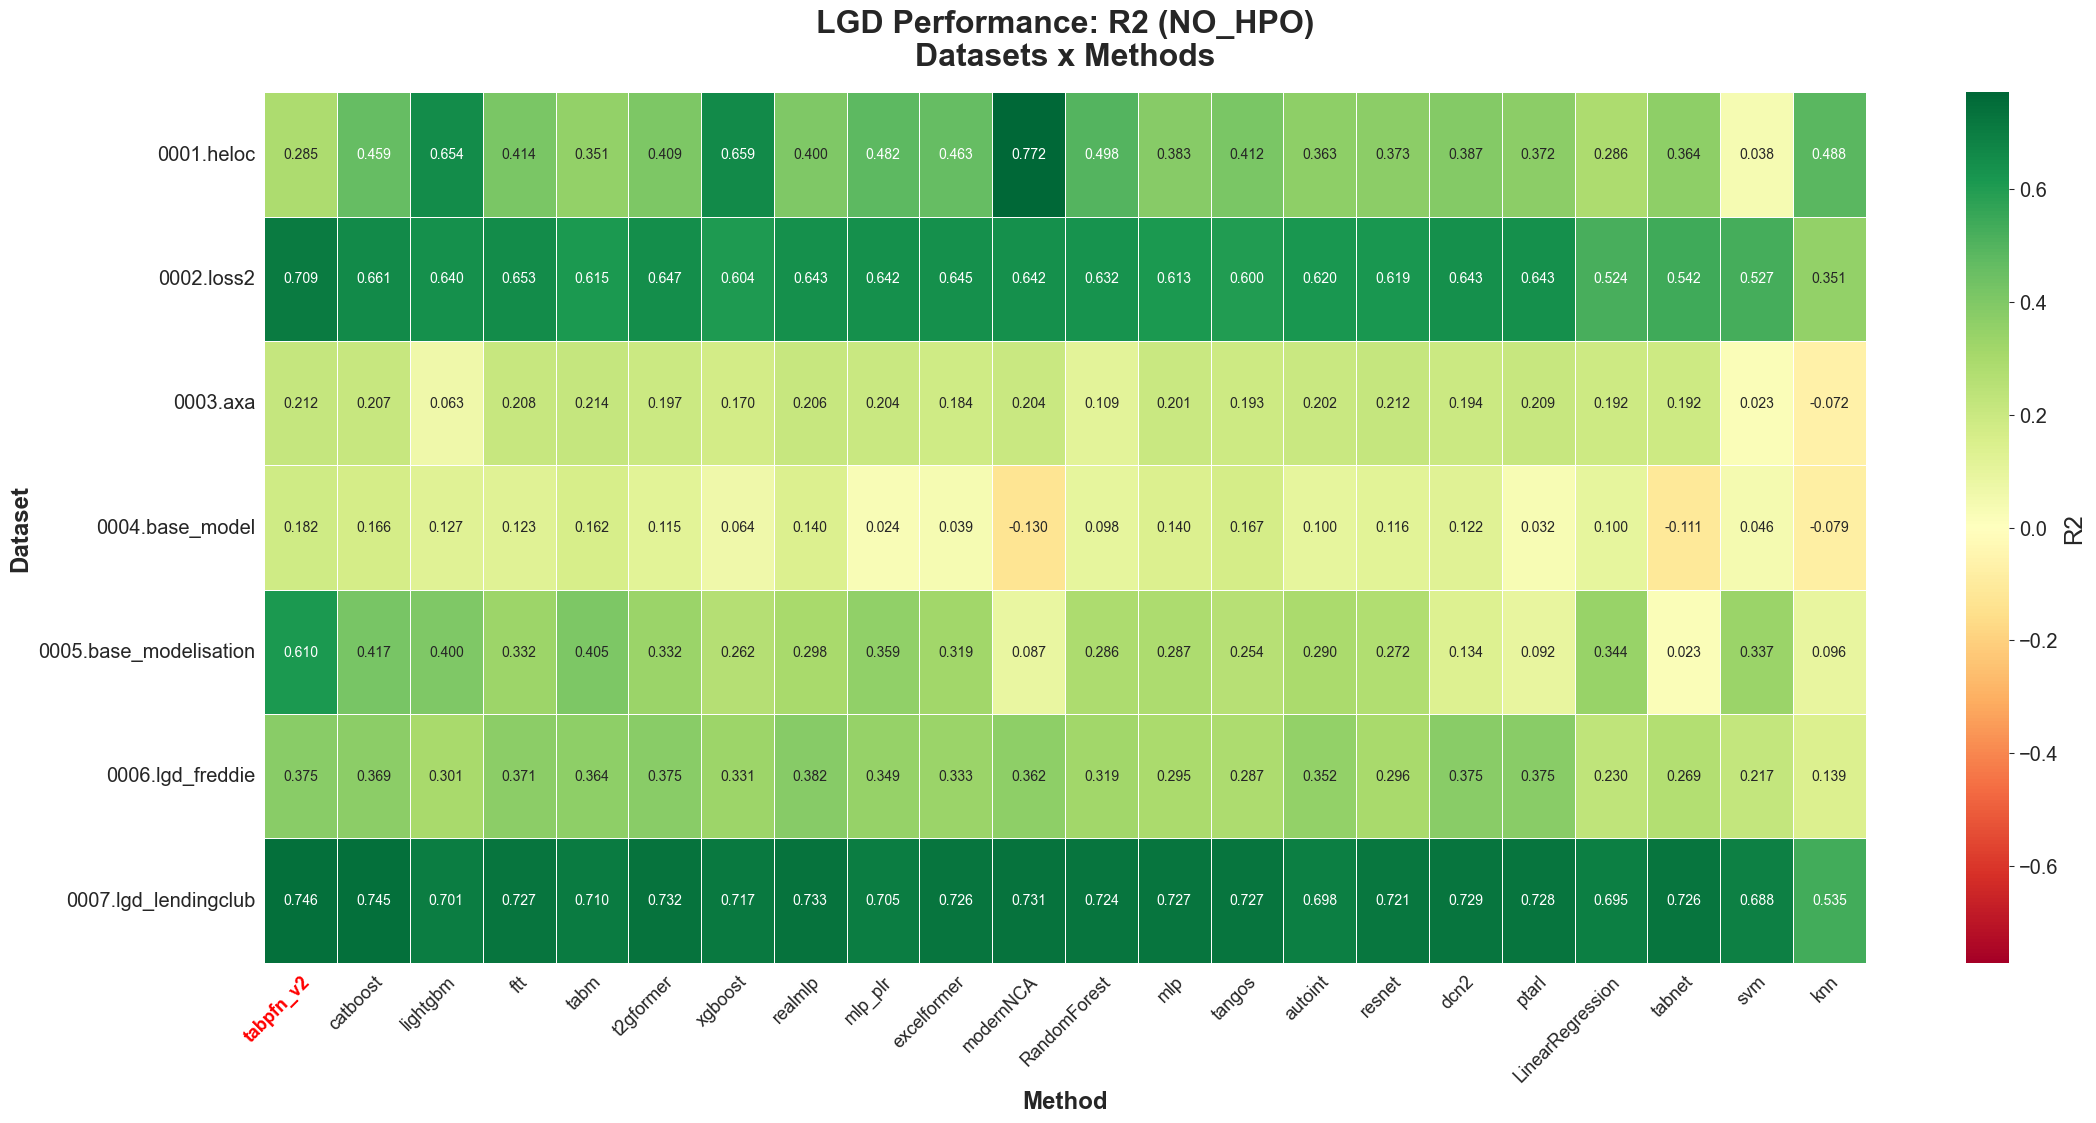

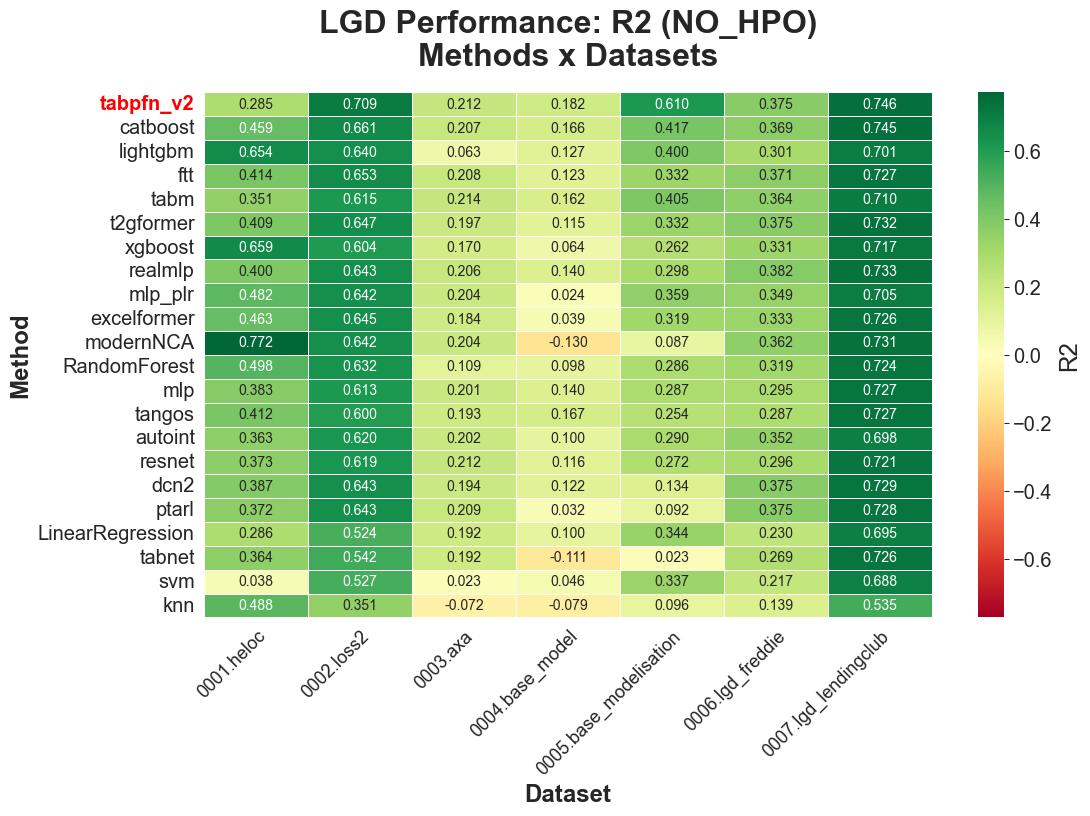

In [5]:
print("Creating LGD R² heatmap (NO_HPO)...")
fig_lgd_no_hpo, pivot_lgd_no_hpo = create_performance_heatmap(
    lgd_agg, 'R2', 'NO_HPO', 'LGD', cmap='RdYlGn'
)
plt.show()

### B1.2 HPO Performance Matrix

Creating LGD R² heatmap (HPO)...
Saved: lgd_heatmap_r2_hpo.png
Saved: lgd_heatmap_r2_hpo_horizontal.png


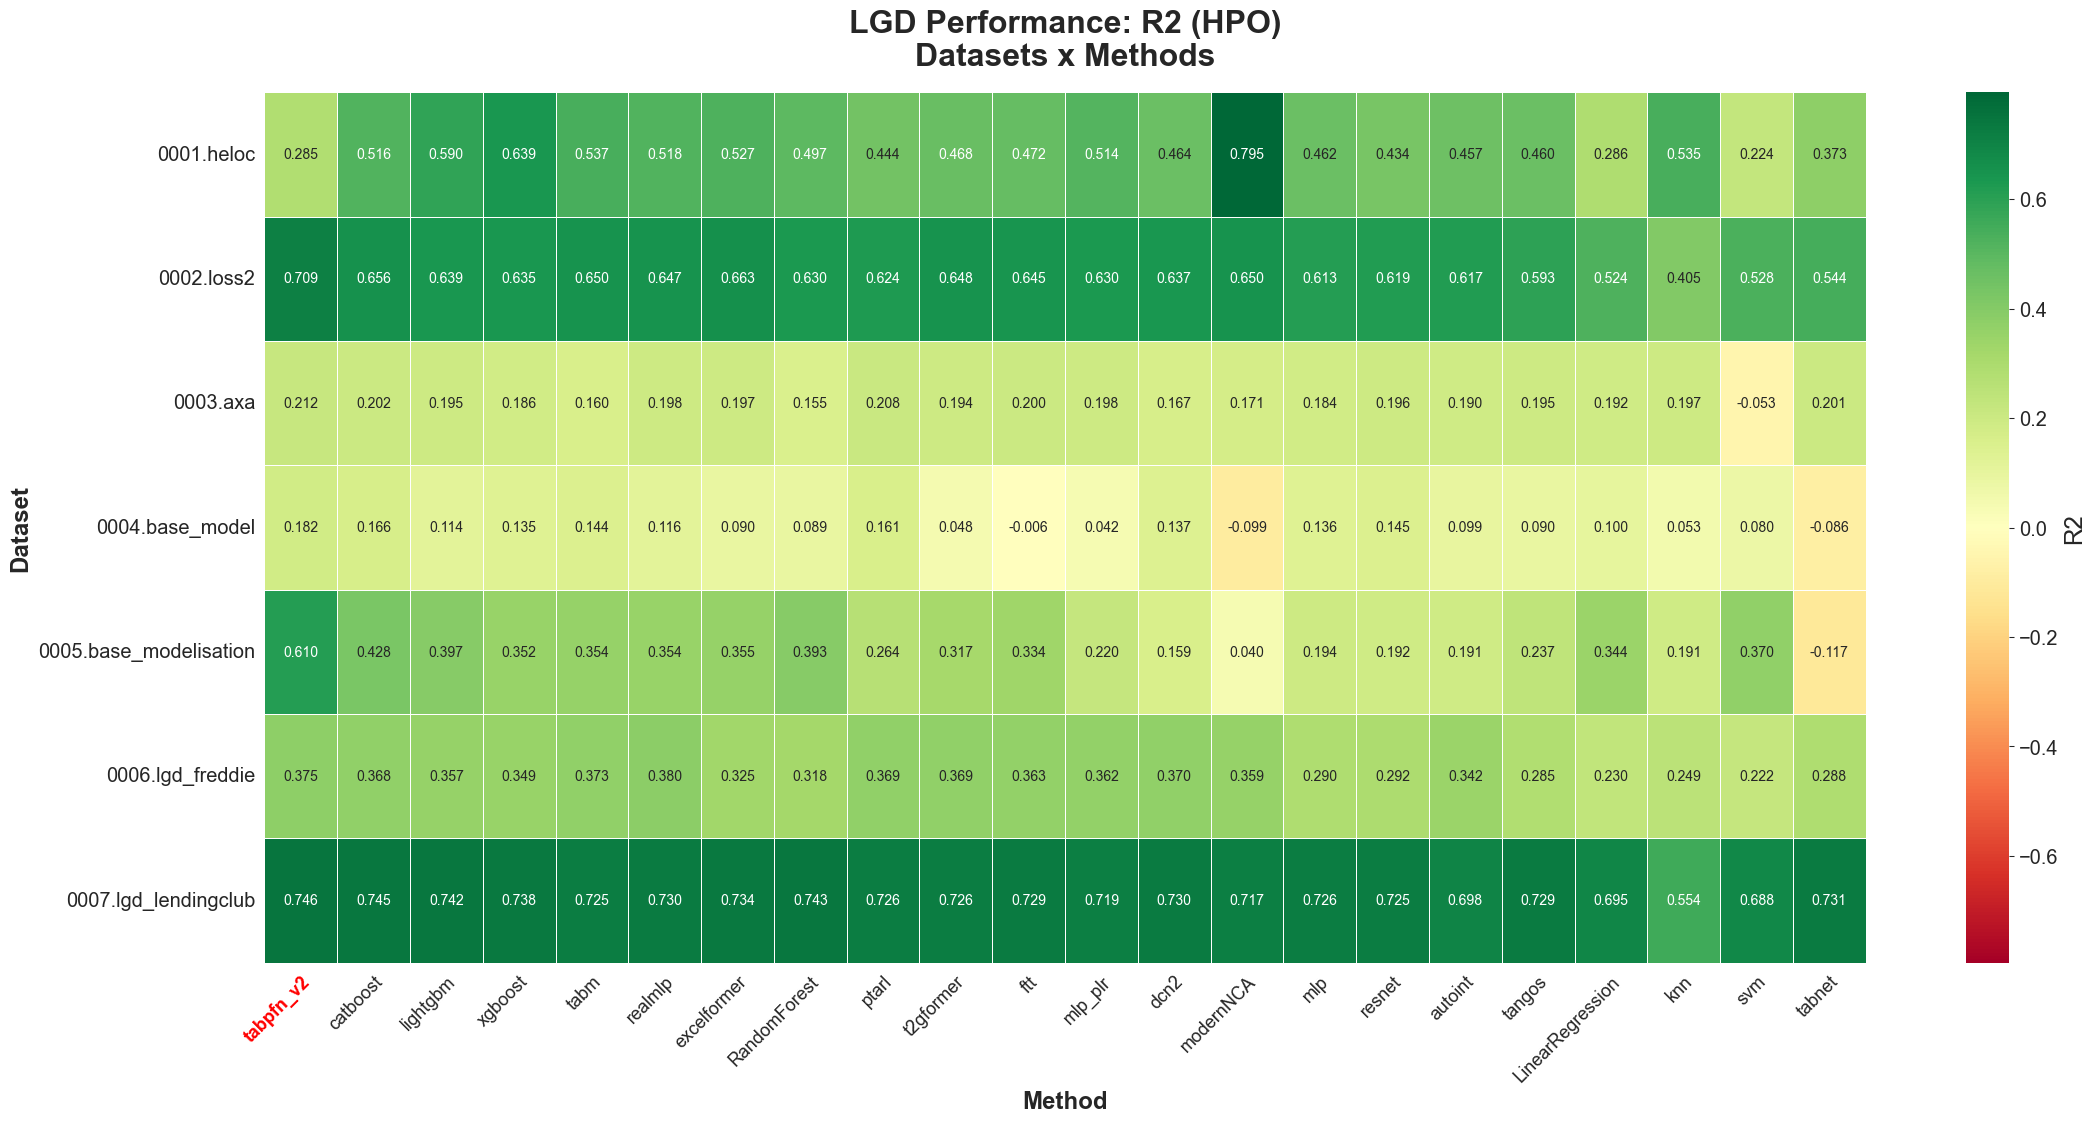

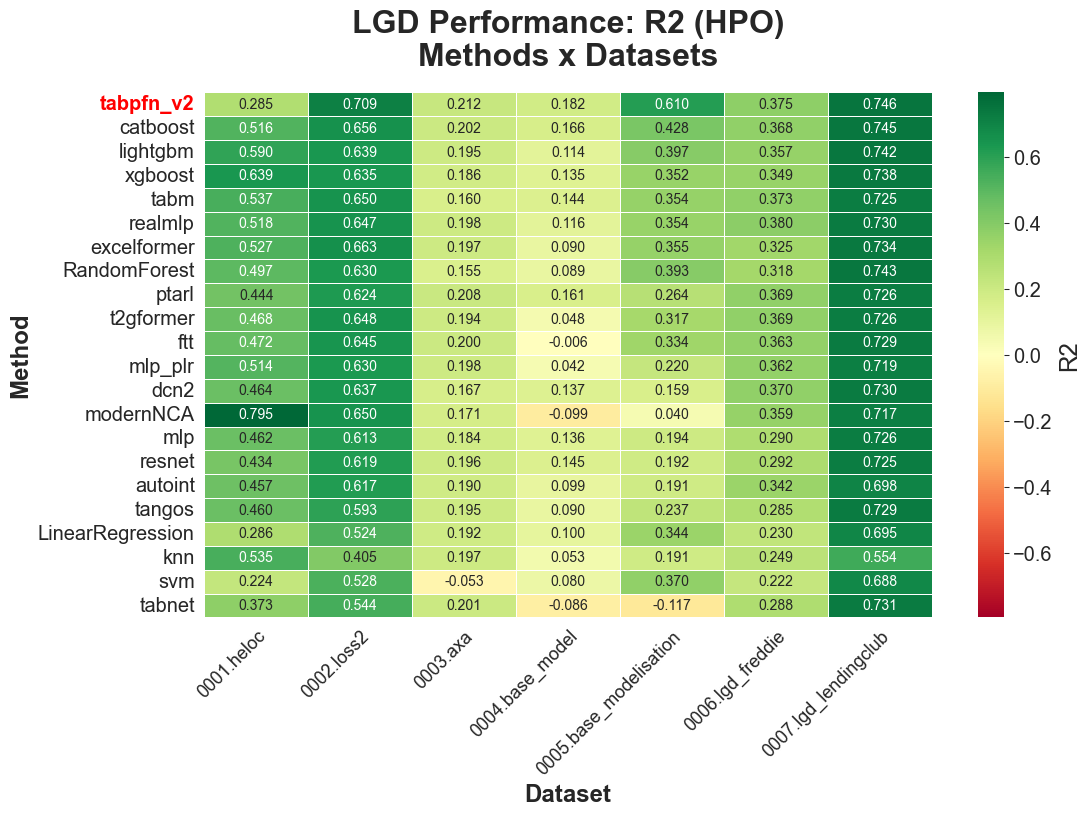

In [6]:
print("Creating LGD R² heatmap (HPO)...")
fig_lgd_hpo, pivot_lgd_hpo = create_performance_heatmap(
    lgd_agg, 'R2', 'HPO', 'LGD', cmap='RdYlGn'
)
plt.show()

### B1.3 HPO Improvement Matrix

Creating LGD HPO improvement heatmap...
Saved: lgd_hpo_improvement_r2.png
Saved: lgd_hpo_improvement_r2_horizontal.png

HPO Impact Statistics:
   Improvements: 72/154 (46.8%)
   Degradations: 68/154 (44.2%)
   Avg improvement: +0.0126
   Max improvement: +0.2695
   Max degradation: -0.1400


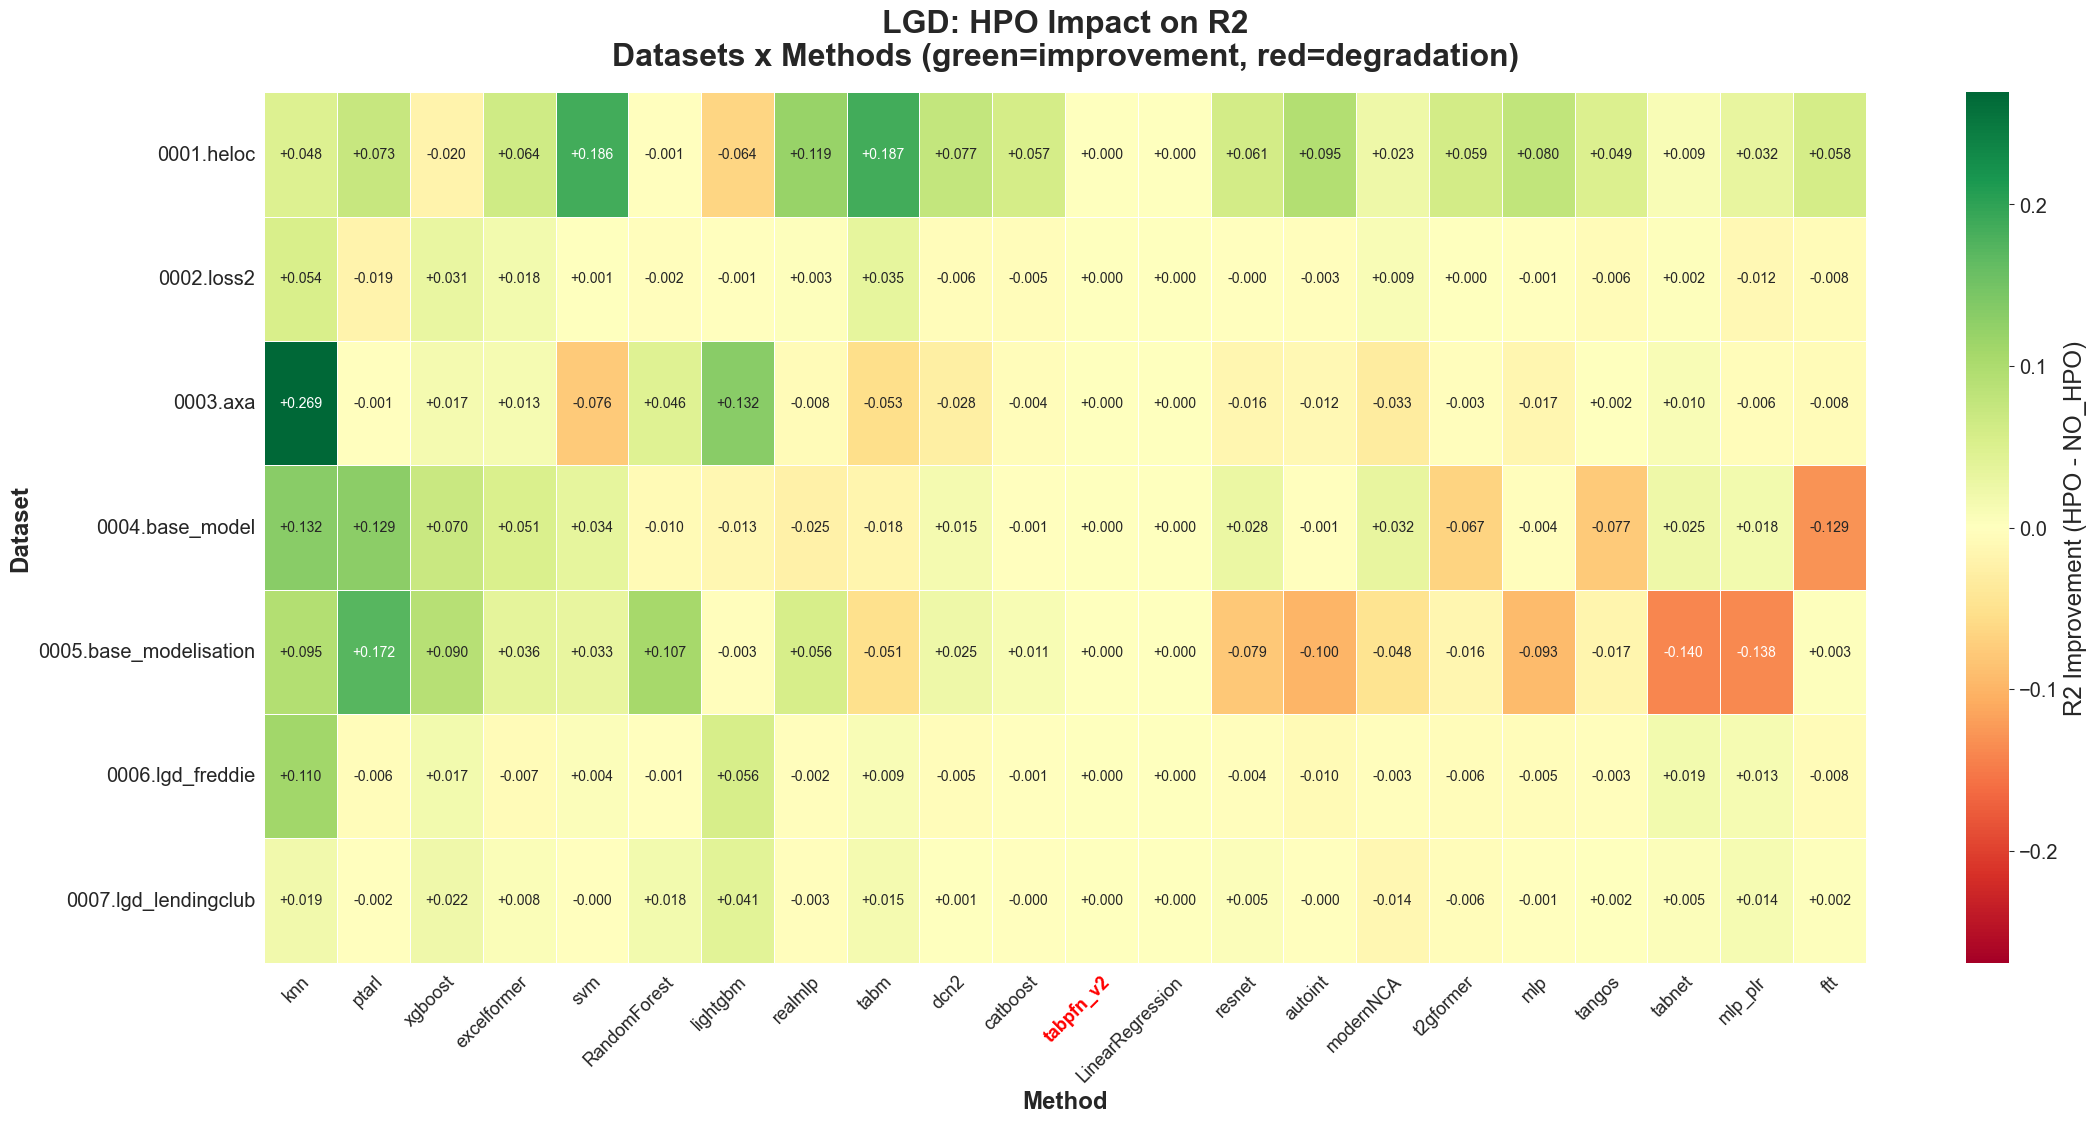

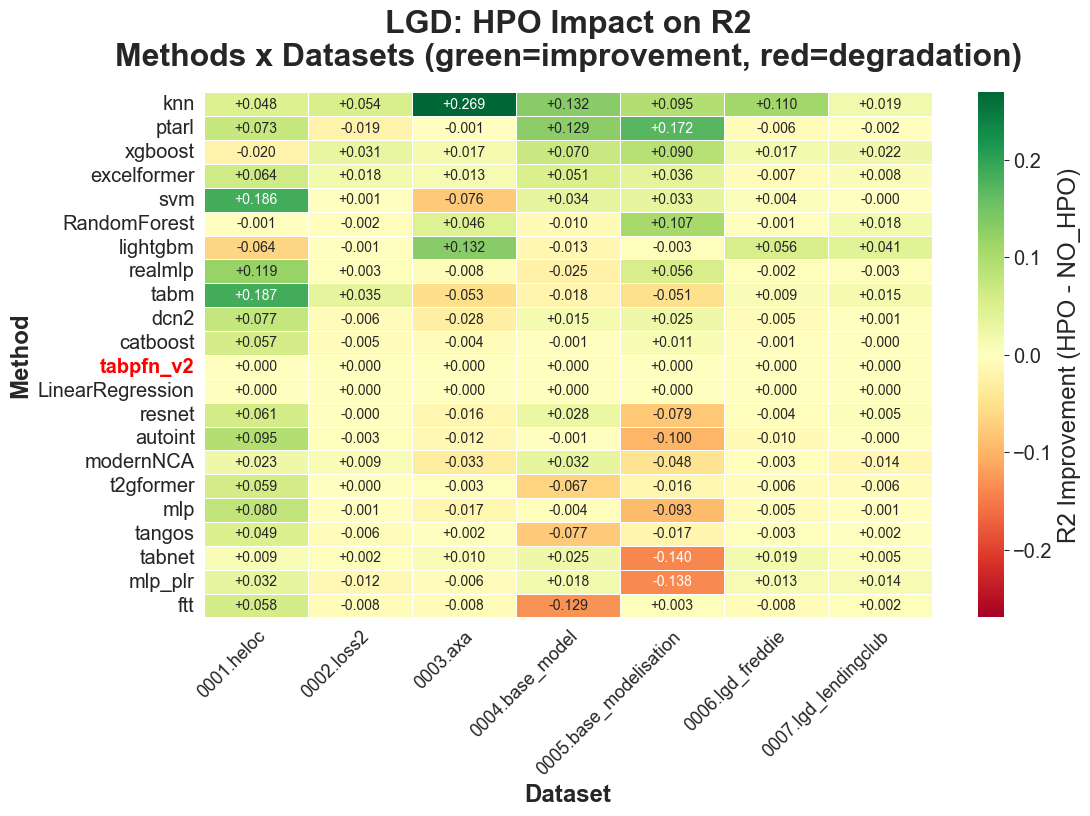

In [7]:
print("Creating LGD HPO improvement heatmap...")
fig_lgd_improvement, diff_lgd = create_hpo_improvement_heatmap(
    lgd_agg, 'R2', 'LGD'
)
plt.show()

## B2. Performance Distributions

### B2.1 Average Performance Bar Charts

Creating LGD average performance bar chart (NO_HPO)...
Saved: lgd_bar_r2_no_hpo.png
Saved: lgd_bar_r2_no_hpo_horizontal.png


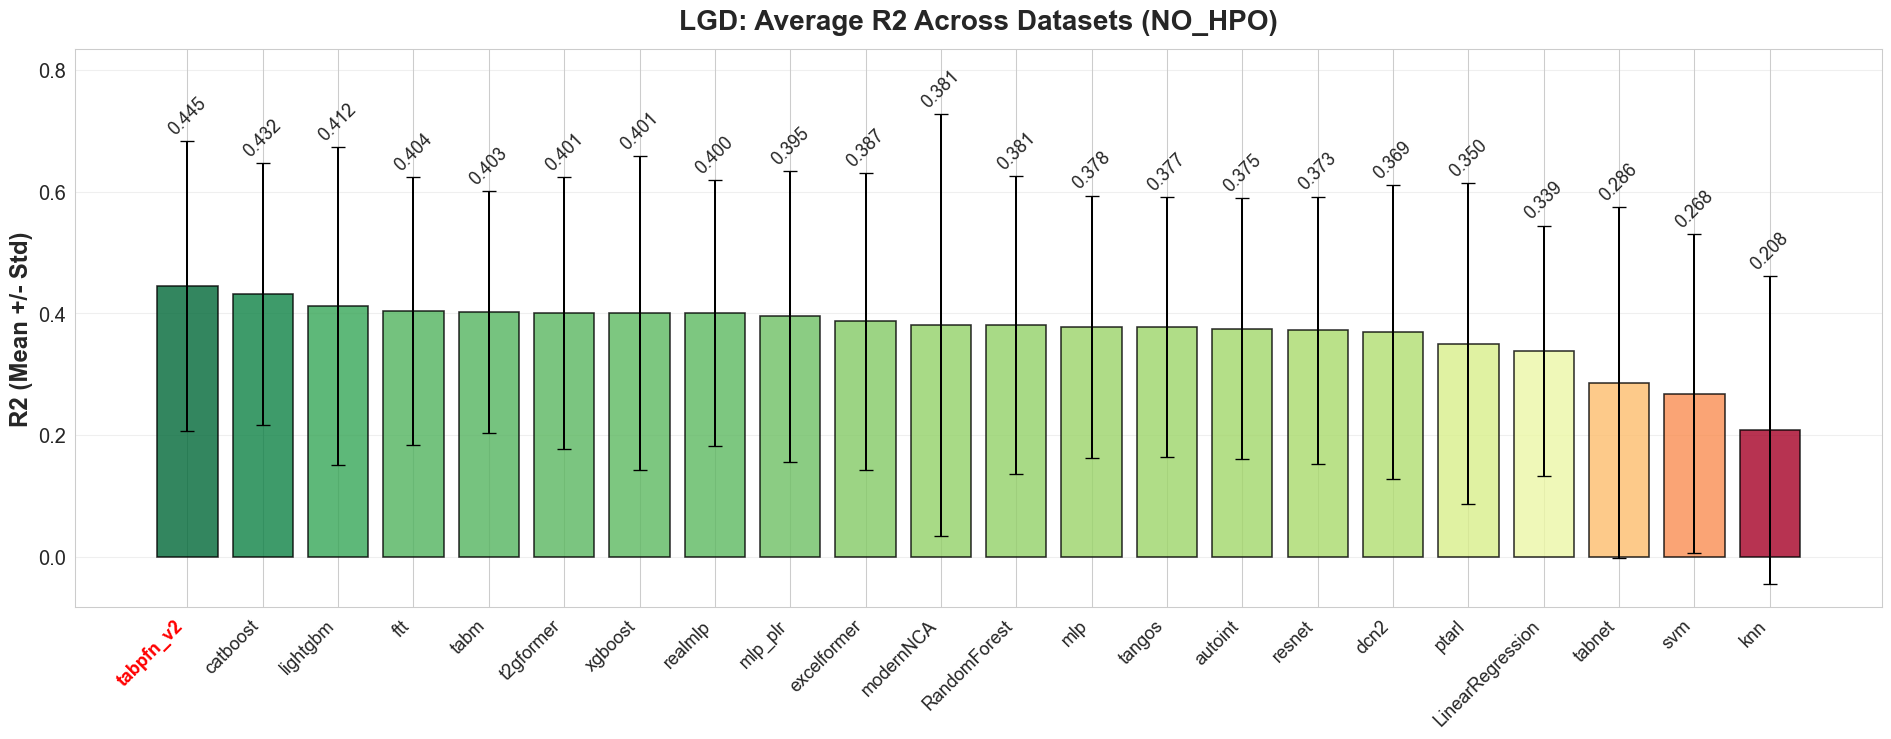

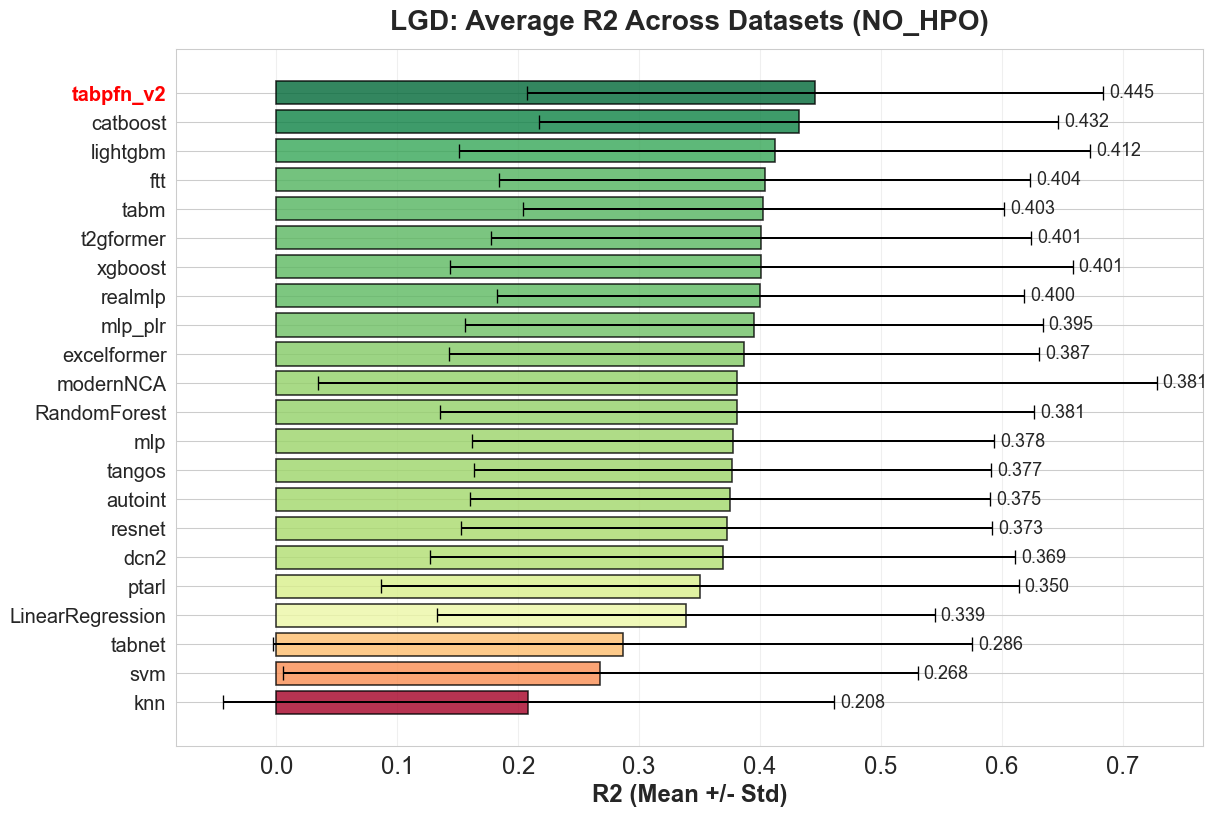


Creating LGD average performance bar chart (HPO)...
Saved: lgd_bar_r2_hpo.png
Saved: lgd_bar_r2_hpo_horizontal.png


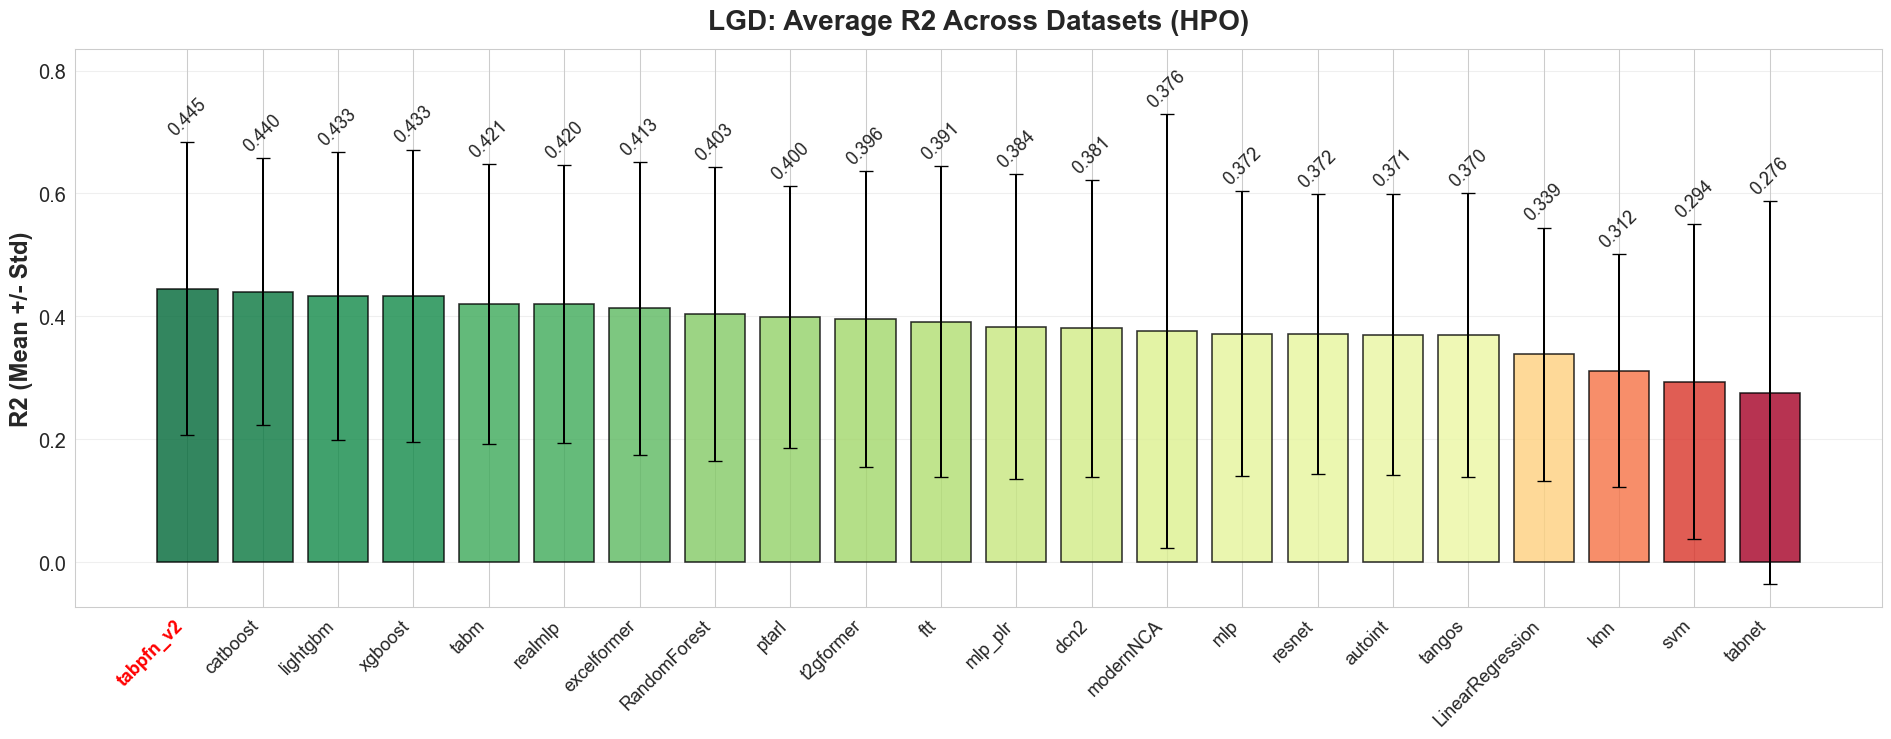

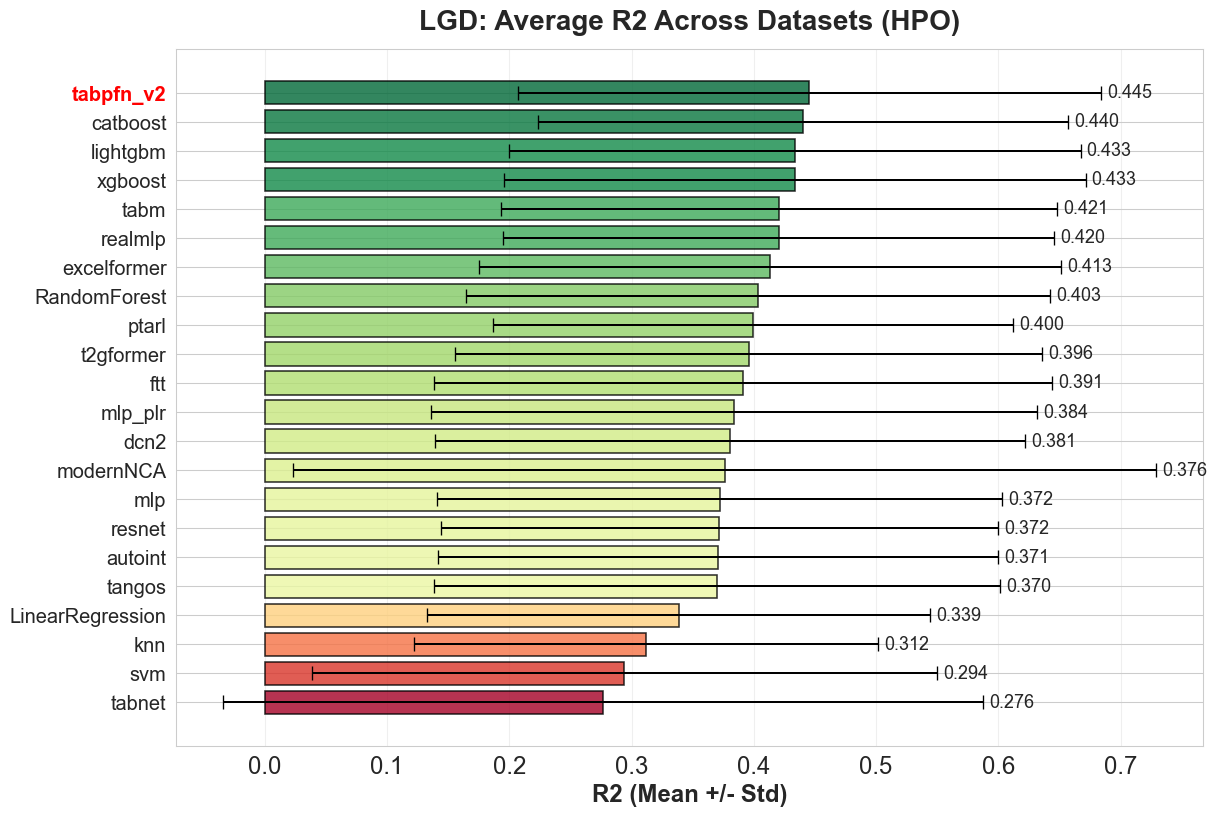

In [8]:
print("Creating LGD average performance bar chart (NO_HPO)...")
plot_average_performance_bar(lgd_agg, 'R2', 'NO_HPO', 'LGD')
plt.show()

print("\nCreating LGD average performance bar chart (HPO)...")
plot_average_performance_bar(lgd_agg, 'R2', 'HPO', 'LGD')
plt.show()

### B2.2 Performance Distribution Boxplots

Creating LGD R² distribution boxplot (NO_HPO)...
Saved: lgd_boxplot_r2_no_hpo.png
Saved: lgd_boxplot_r2_no_hpo_horizontal.png


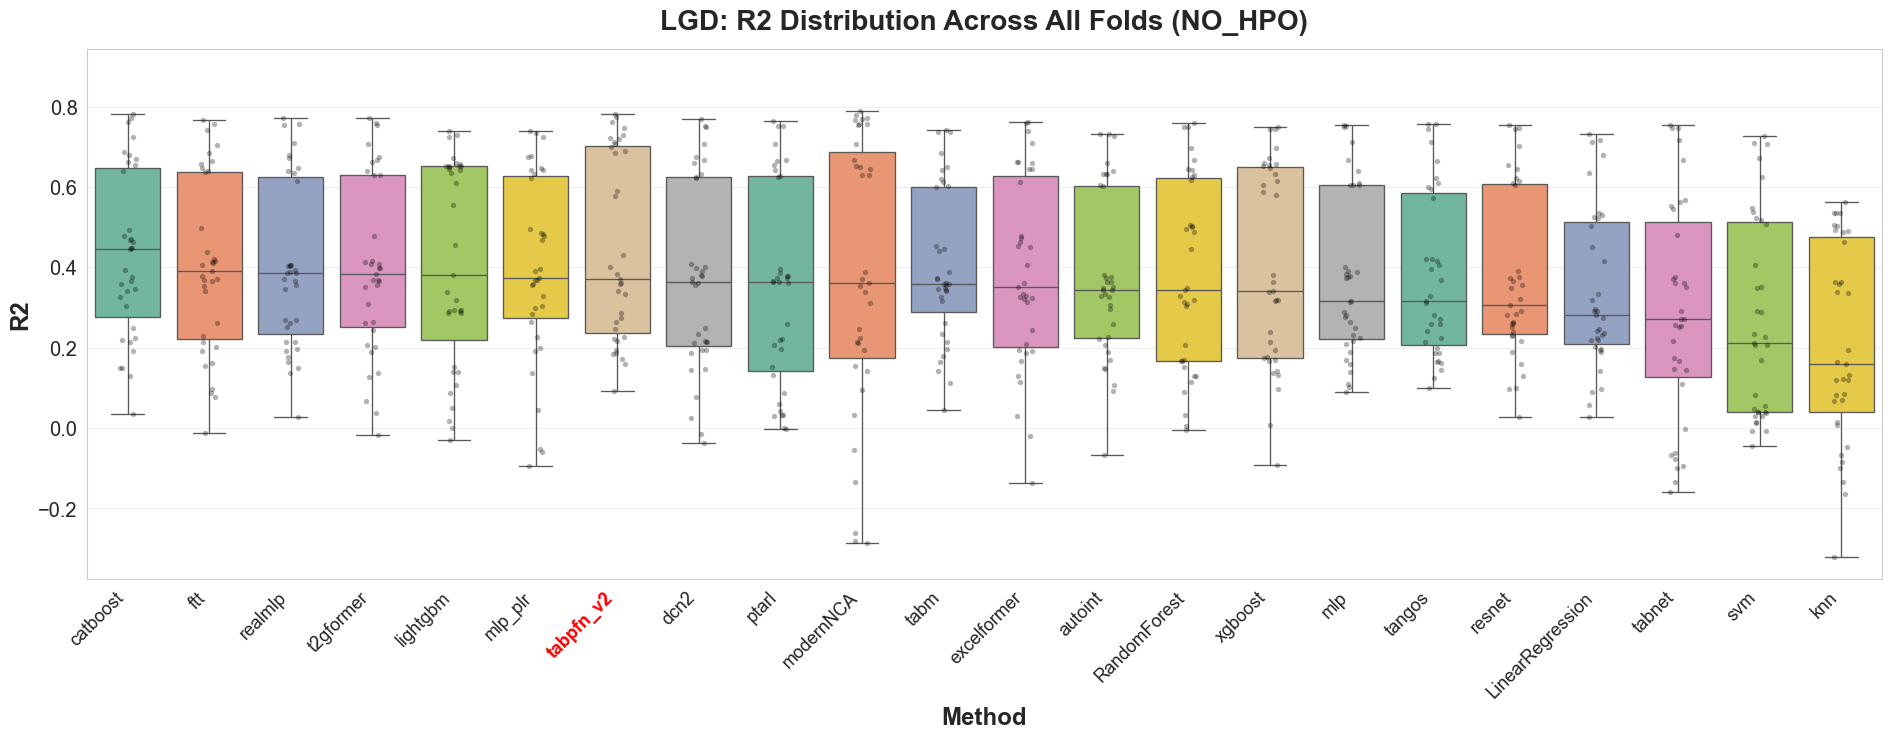

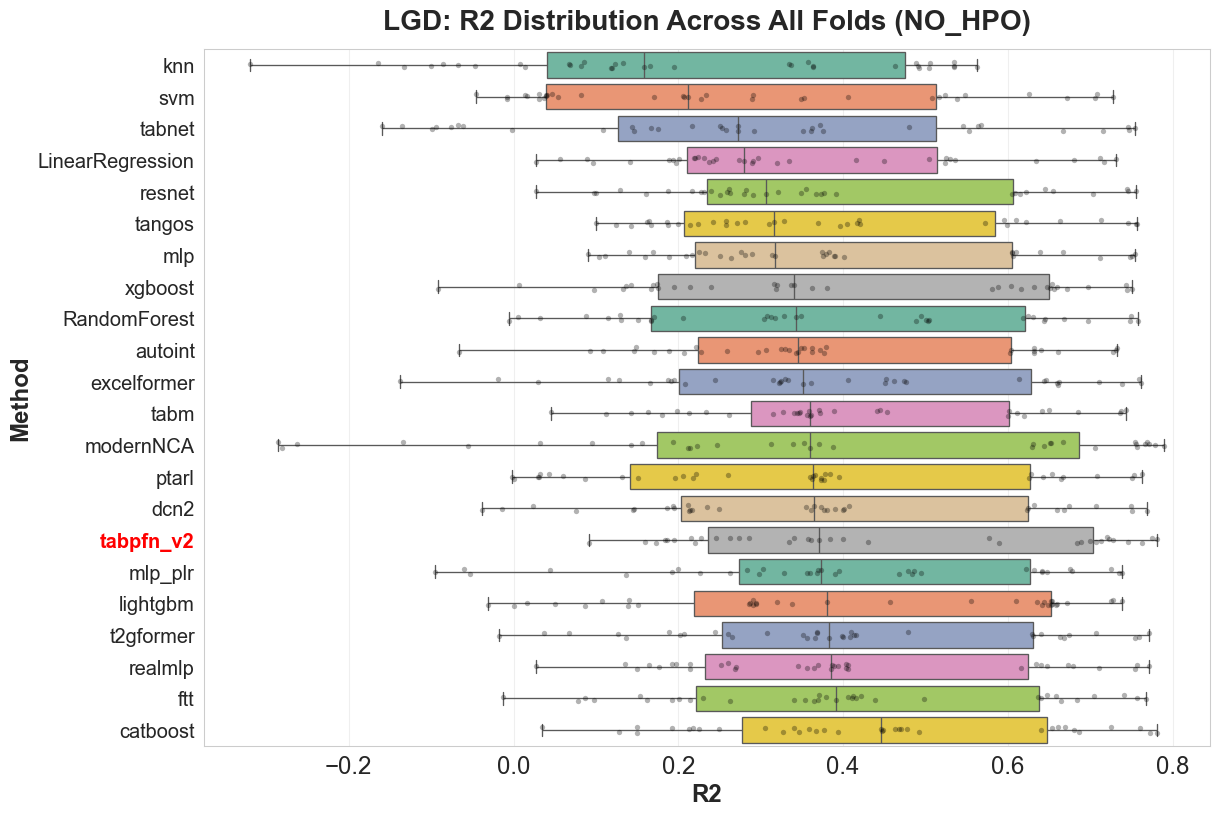


Creating LGD R² distribution boxplot (HPO)...
Saved: lgd_boxplot_r2_hpo.png
Saved: lgd_boxplot_r2_hpo_horizontal.png


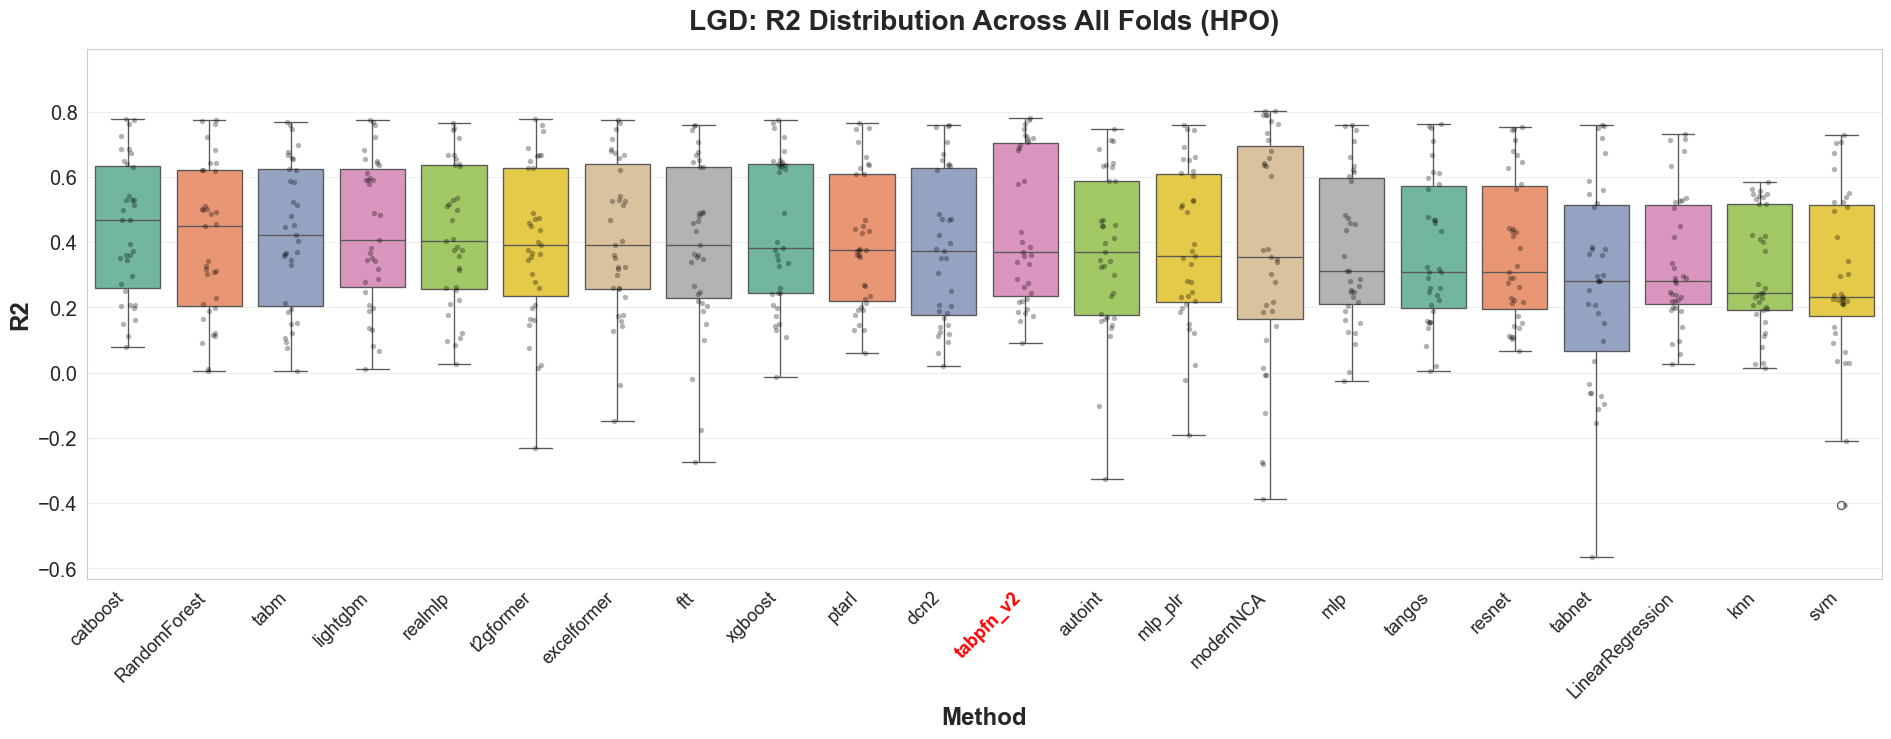

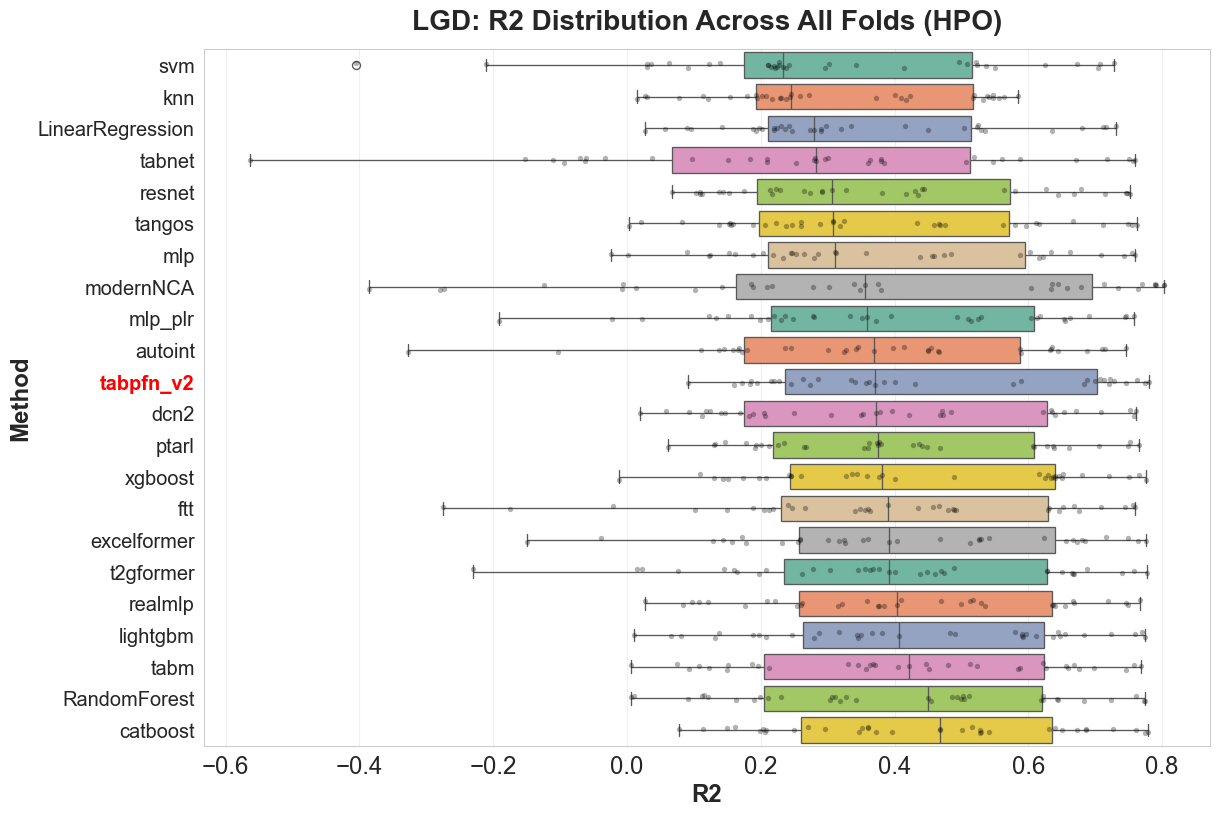

In [9]:
print("Creating LGD R² distribution boxplot (NO_HPO)...")
plot_performance_distribution(lgd_raw, 'R2', 'NO_HPO', 'LGD')
plt.show()

print("\nCreating LGD R² distribution boxplot (HPO)...")
plot_performance_distribution(lgd_raw, 'R2', 'HPO', 'LGD')
plt.show()

### B2.3 Rank Distribution Boxplots

Creating LGD R² rank distribution boxplot (NO_HPO)...
Saved: lgd_boxplot_rank_r2_no_hpo.png
Saved: lgd_boxplot_rank_r2_no_hpo_horizontal.png


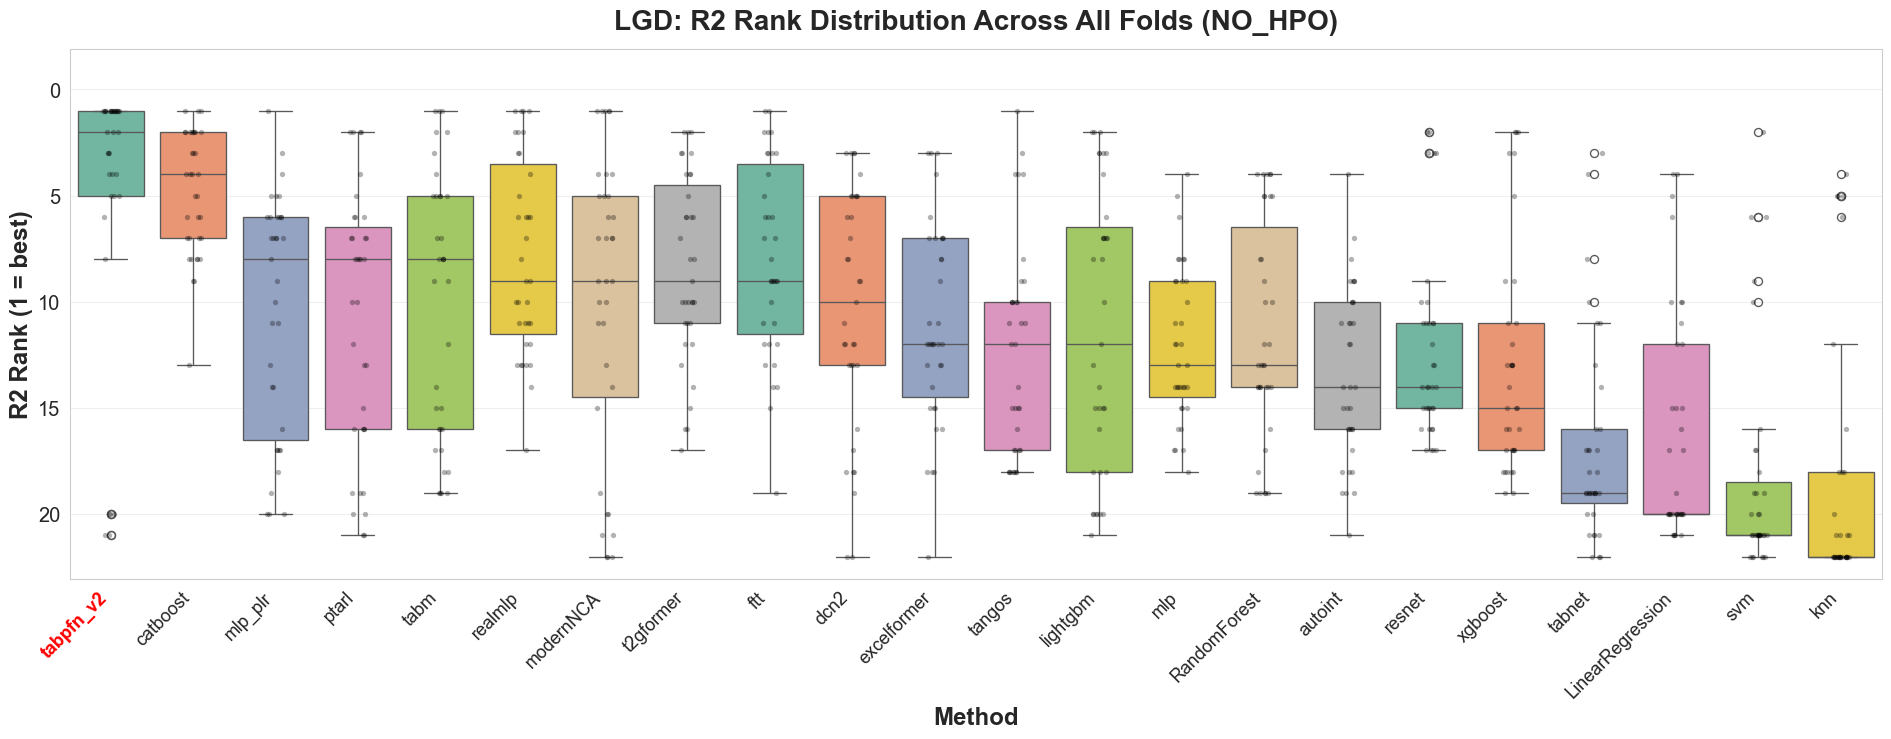

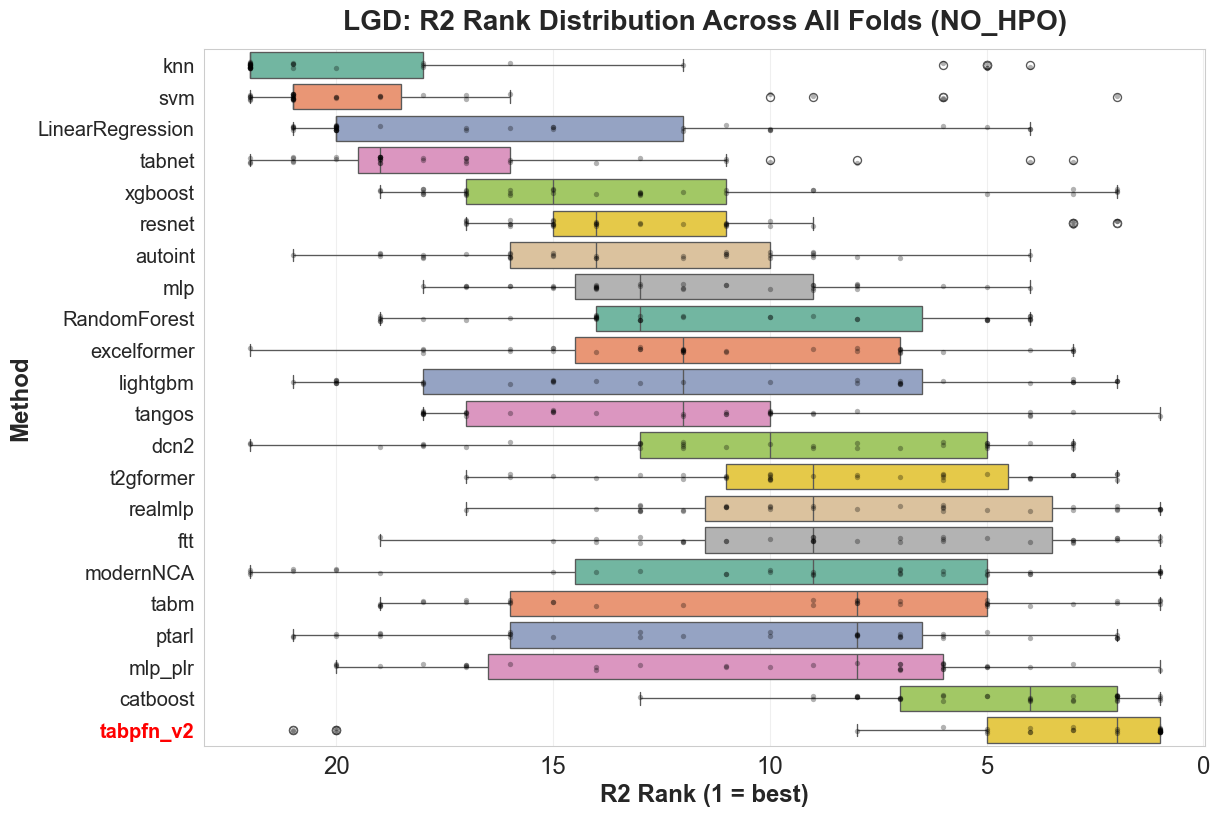


Creating LGD R² rank distribution boxplot (HPO)...
Saved: lgd_boxplot_rank_r2_hpo.png
Saved: lgd_boxplot_rank_r2_hpo_horizontal.png


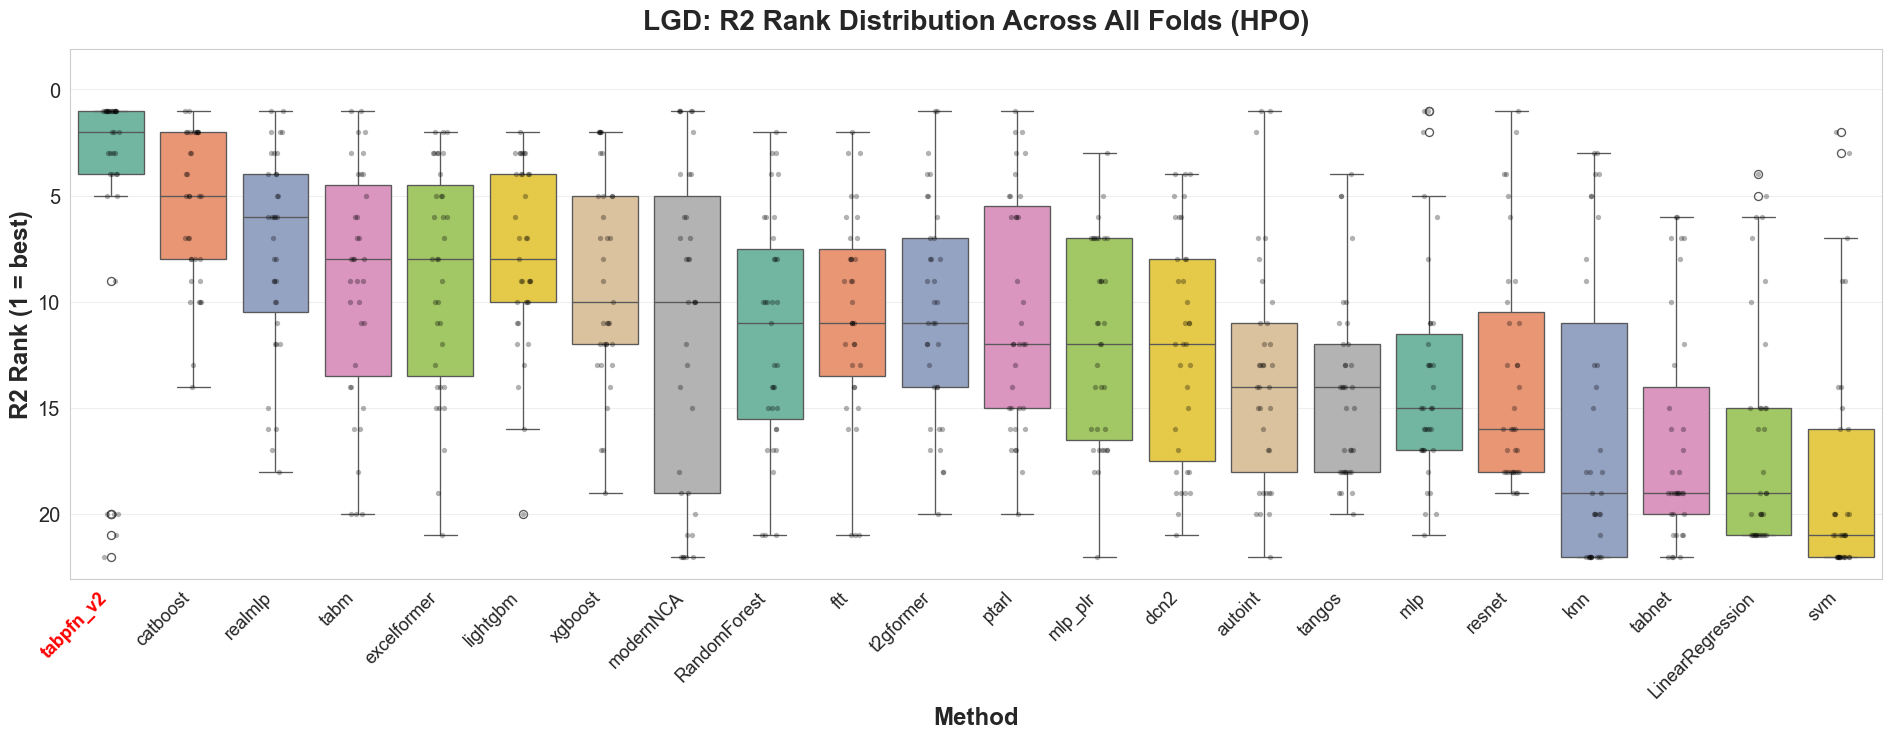

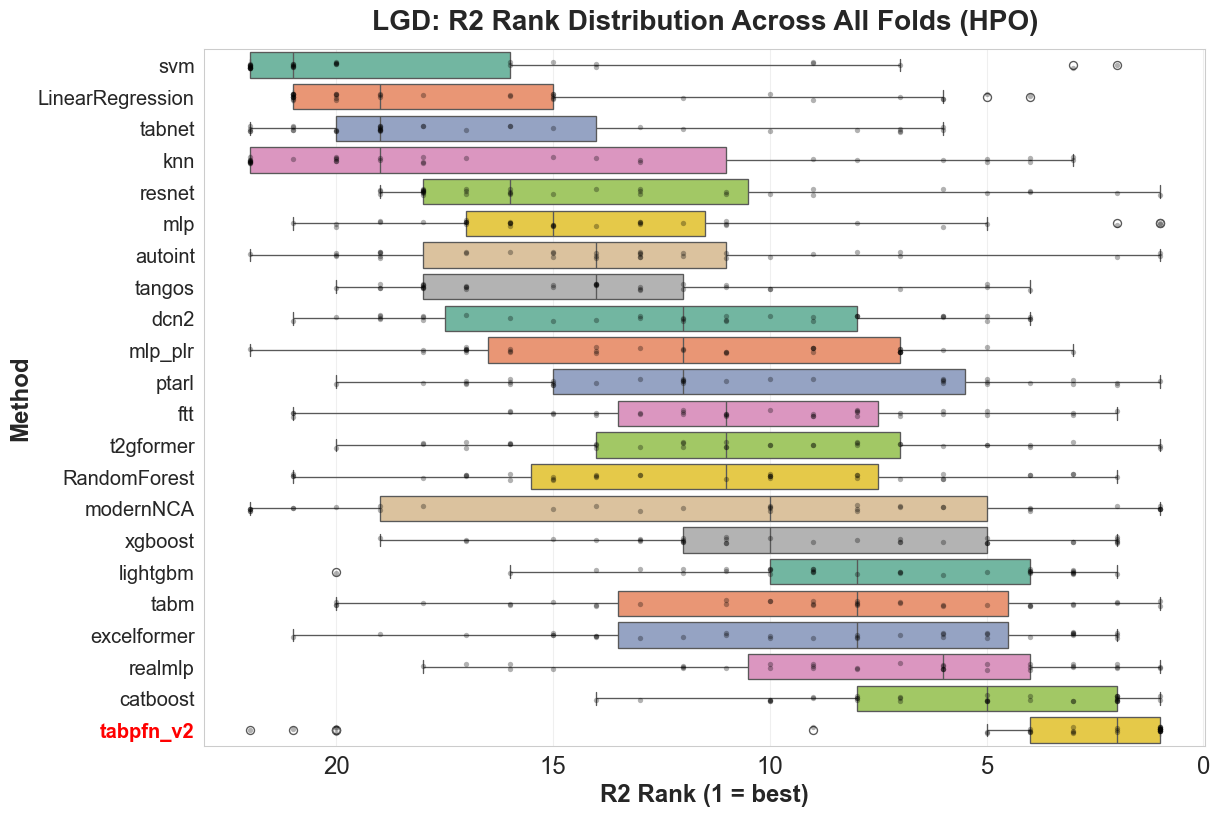

In [10]:
print("Creating LGD R\u00b2 rank distribution boxplot (NO_HPO)...")
plot_rank_distribution(lgd_raw, 'R2', 'NO_HPO', 'LGD')
plt.show()

print("\nCreating LGD R\u00b2 rank distribution boxplot (HPO)...")
plot_rank_distribution(lgd_raw, 'R2', 'HPO', 'LGD')
plt.show()

## B3. Rank Analysis

### B3.1 Rank Heatmaps

Creating LGD rank heatmap (NO_HPO)...
Saved: lgd_ranks_r2_no_hpo.png
Saved: lgd_ranks_r2_no_hpo_horizontal.png


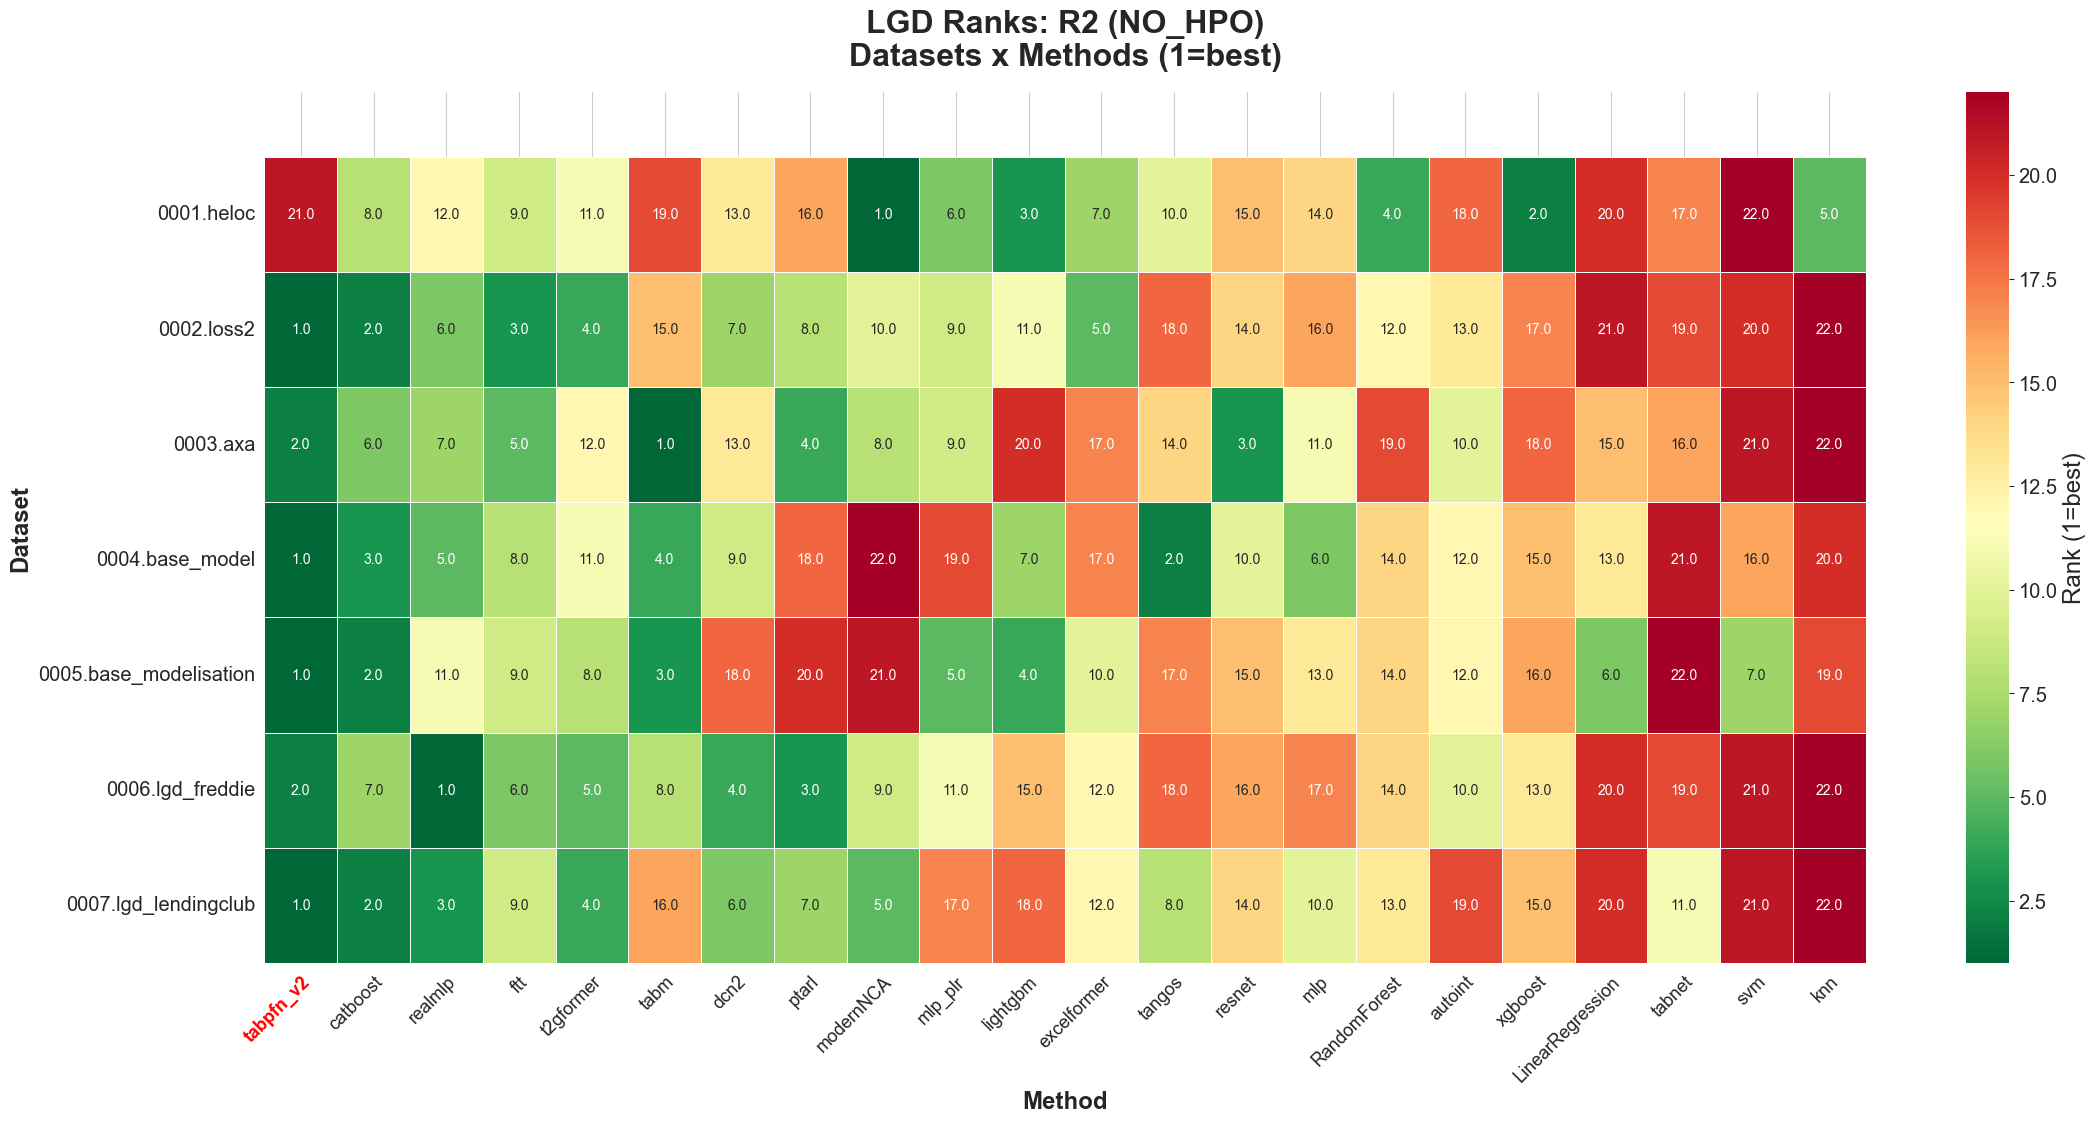

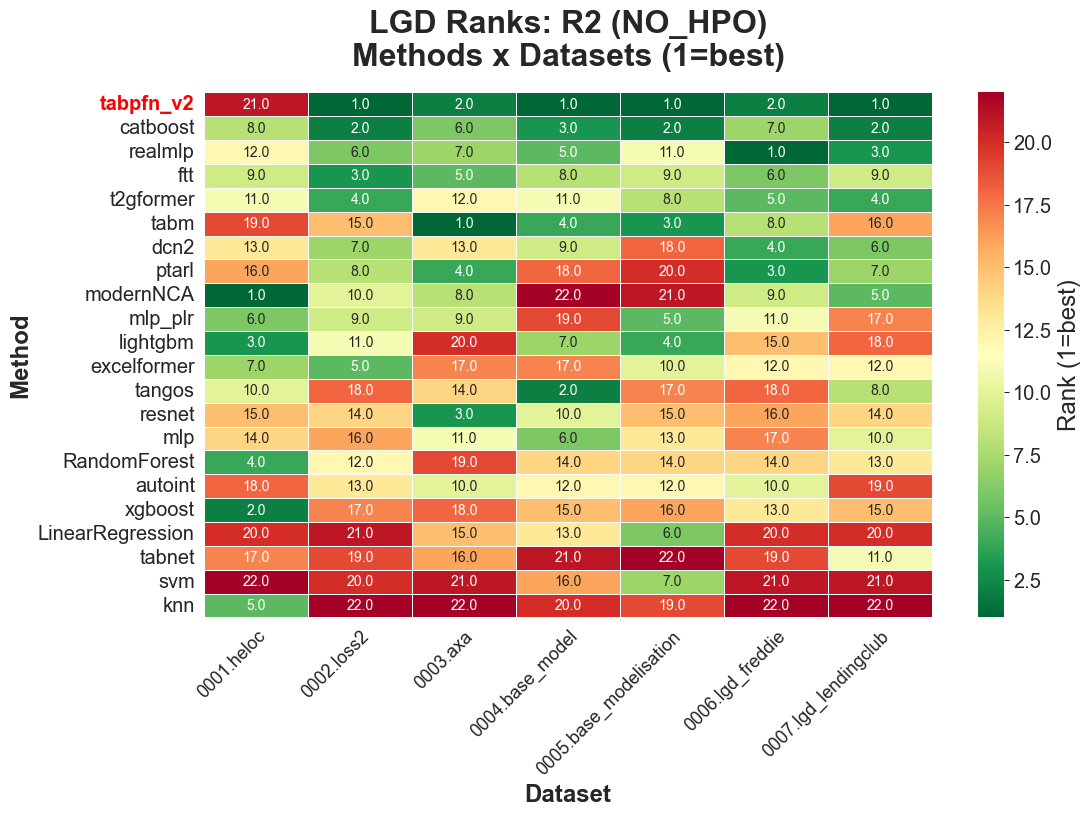


Method Rankings (NO_HPO):
 Rank Method                 Avg Rank  Median Rank
--------------------------------------------------
    1. tabpfn_v2                   4.14          1.00
    2. catboost                    4.29          3.00
    3. realmlp                     6.43          6.00
    4. ftt                         7.00          8.00
    5. t2gformer                   7.86          8.00
    6. tabm                        9.43          8.00
    7. dcn2                       10.00          9.00
    8. ptarl                      10.86          8.00
    9. modernNCA                  10.86          9.00
   10. mlp_plr                    10.86          9.00
   11. lightgbm                   11.14         11.00
   12. excelformer                11.43         12.00
   13. tangos                     12.43         14.00
   14. resnet                     12.43         14.00
   15. mlp                        12.43         13.00
   16. RandomForest               12.86         14.00
   17. 

In [11]:
print("Creating LGD rank heatmap (NO_HPO)...")
fig_lgd_ranks_no_hpo, ranks_lgd_no_hpo, avg_ranks_lgd_no_hpo, median_ranks_lgd_no_hpo = create_rank_heatmap(
    lgd_agg, 'R2', 'NO_HPO', 'LGD'
)
plt.show()

print("\nMethod Rankings (NO_HPO):")
print(f"{'Rank':>5} {'Method':<20} {'Avg Rank':>10} {'Median Rank':>12}")
print("-" * 50)
for rank, (method, avg_rank) in enumerate(avg_ranks_lgd_no_hpo.items(), 1):
    med_rank = median_ranks_lgd_no_hpo[method]
    print(f"   {rank:2d}. {method:20s}  {avg_rank:>10.2f}  {med_rank:>12.2f}")

Creating LGD rank heatmap (HPO)...
Saved: lgd_ranks_r2_hpo.png
Saved: lgd_ranks_r2_hpo_horizontal.png


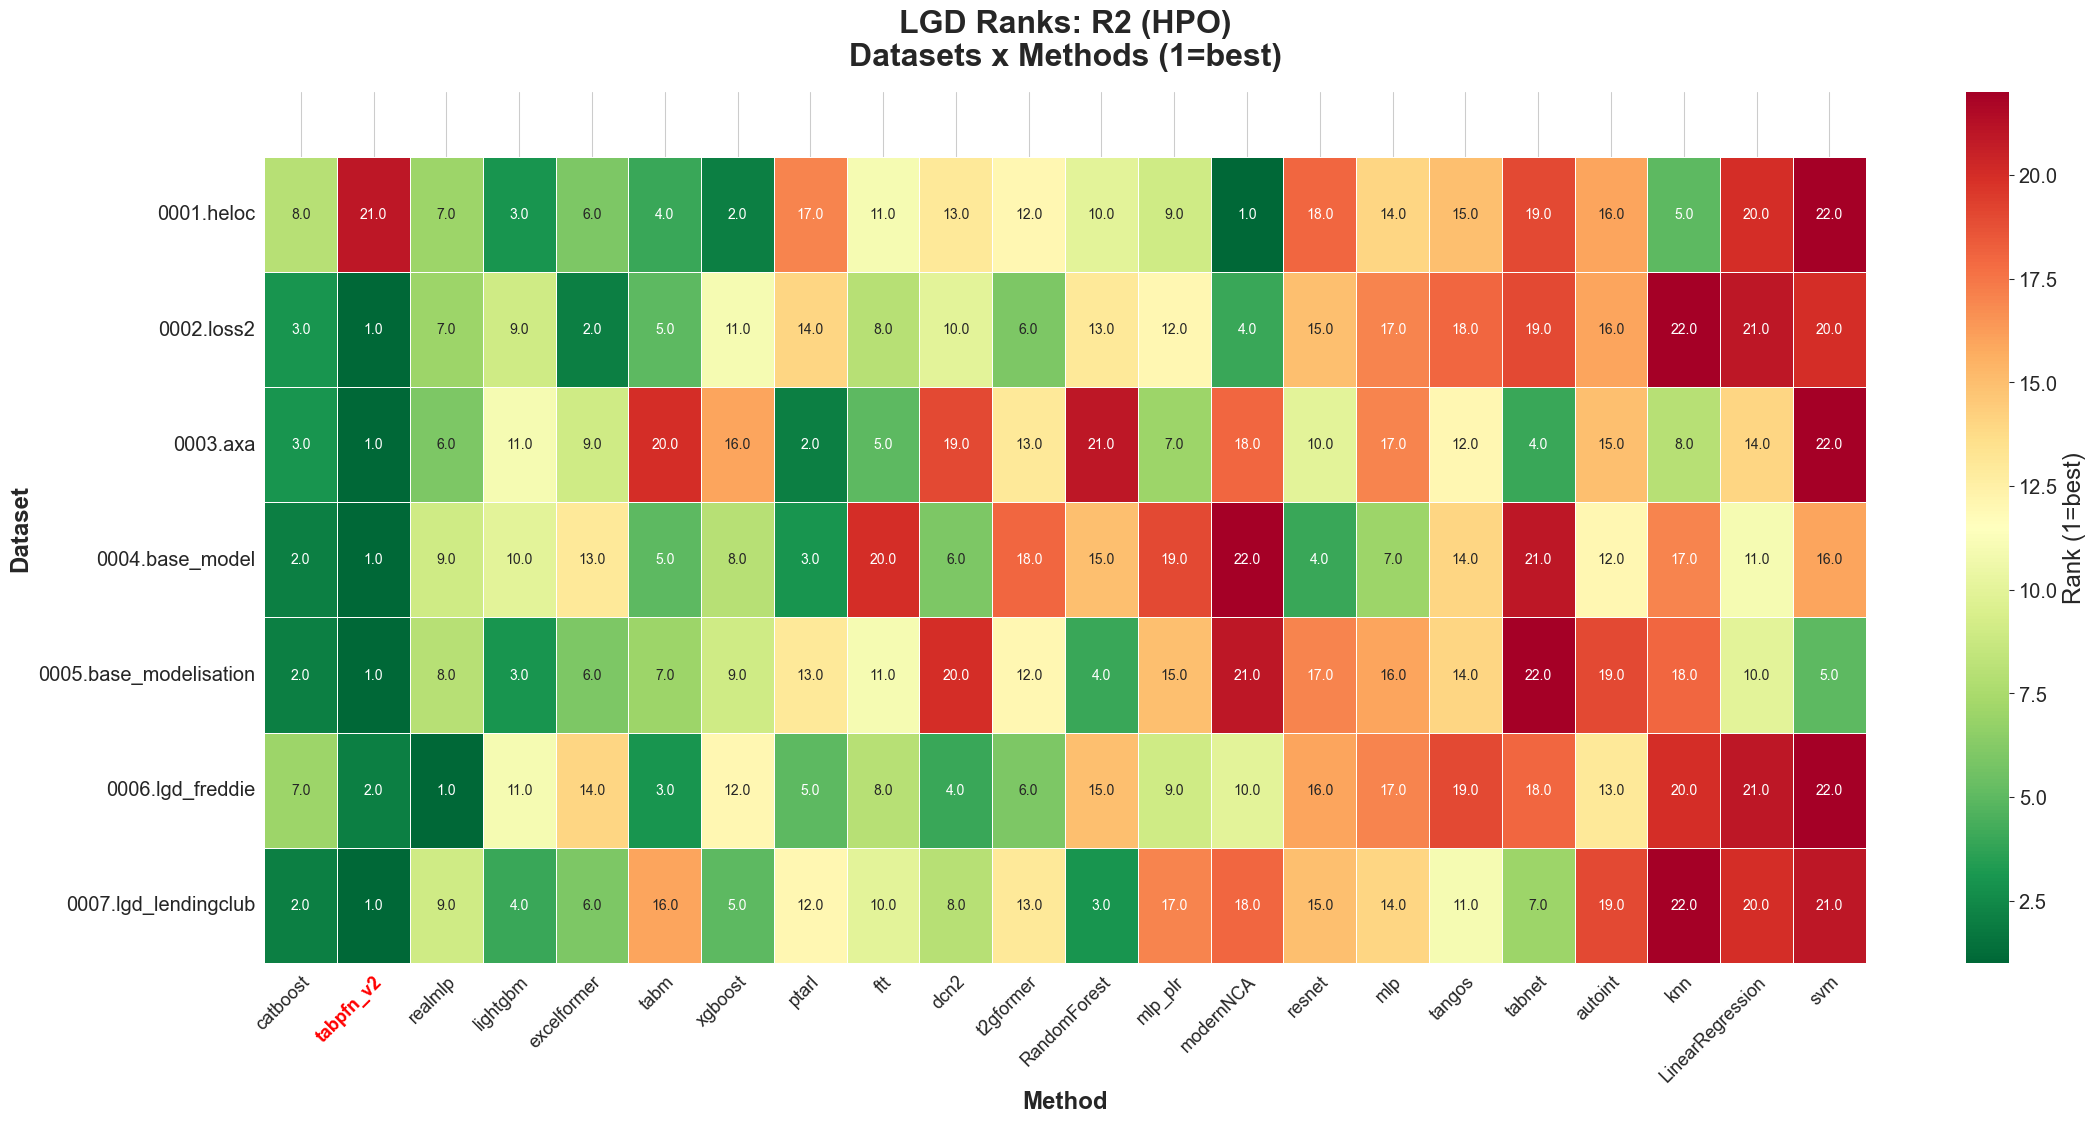

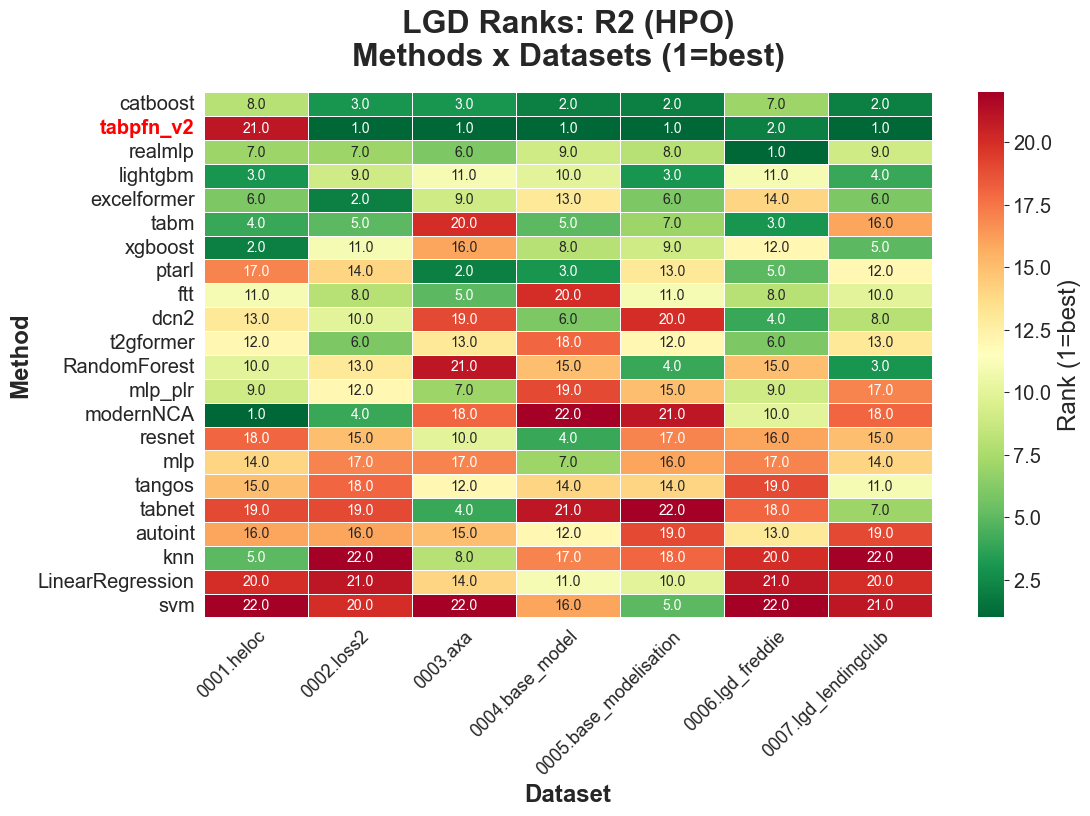


Method Rankings (HPO):
 Rank Method                 Avg Rank  Median Rank
--------------------------------------------------
    1. catboost                    3.86          3.00
    2. tabpfn_v2                   4.00          1.00
    3. realmlp                     6.71          7.00
    4. lightgbm                    7.29          9.00
    5. excelformer                 8.00          6.00
    6. tabm                        8.57          5.00
    7. xgboost                     9.00          9.00
    8. ptarl                       9.43         12.00
    9. ftt                        10.43         10.00
   10. dcn2                       11.43         10.00
   11. t2gformer                  11.43         12.00
   12. RandomForest               11.57         13.00
   13. mlp_plr                    12.57         12.00
   14. modernNCA                  13.43         18.00
   15. resnet                     13.57         15.00
   16. mlp                        14.57         16.00
   17. tan

In [12]:
print("Creating LGD rank heatmap (HPO)...")
fig_lgd_ranks_hpo, ranks_lgd_hpo, avg_ranks_lgd_hpo, median_ranks_lgd_hpo = create_rank_heatmap(
    lgd_agg, 'R2', 'HPO', 'LGD'
)
plt.show()

print("\nMethod Rankings (HPO):")
print(f"{'Rank':>5} {'Method':<20} {'Avg Rank':>10} {'Median Rank':>12}")
print("-" * 50)
for rank, (method, avg_rank) in enumerate(avg_ranks_lgd_hpo.items(), 1):
    med_rank = median_ranks_lgd_hpo[method]
    print(f"   {rank:2d}. {method:20s}  {avg_rank:>10.2f}  {med_rank:>12.2f}")

### B3.2 Average Rank Bar Charts

Creating LGD average rank bar chart (NO_HPO)...
Saved: lgd_bar_rank_r2_no_hpo.png
Saved: lgd_bar_rank_r2_no_hpo_horizontal.png


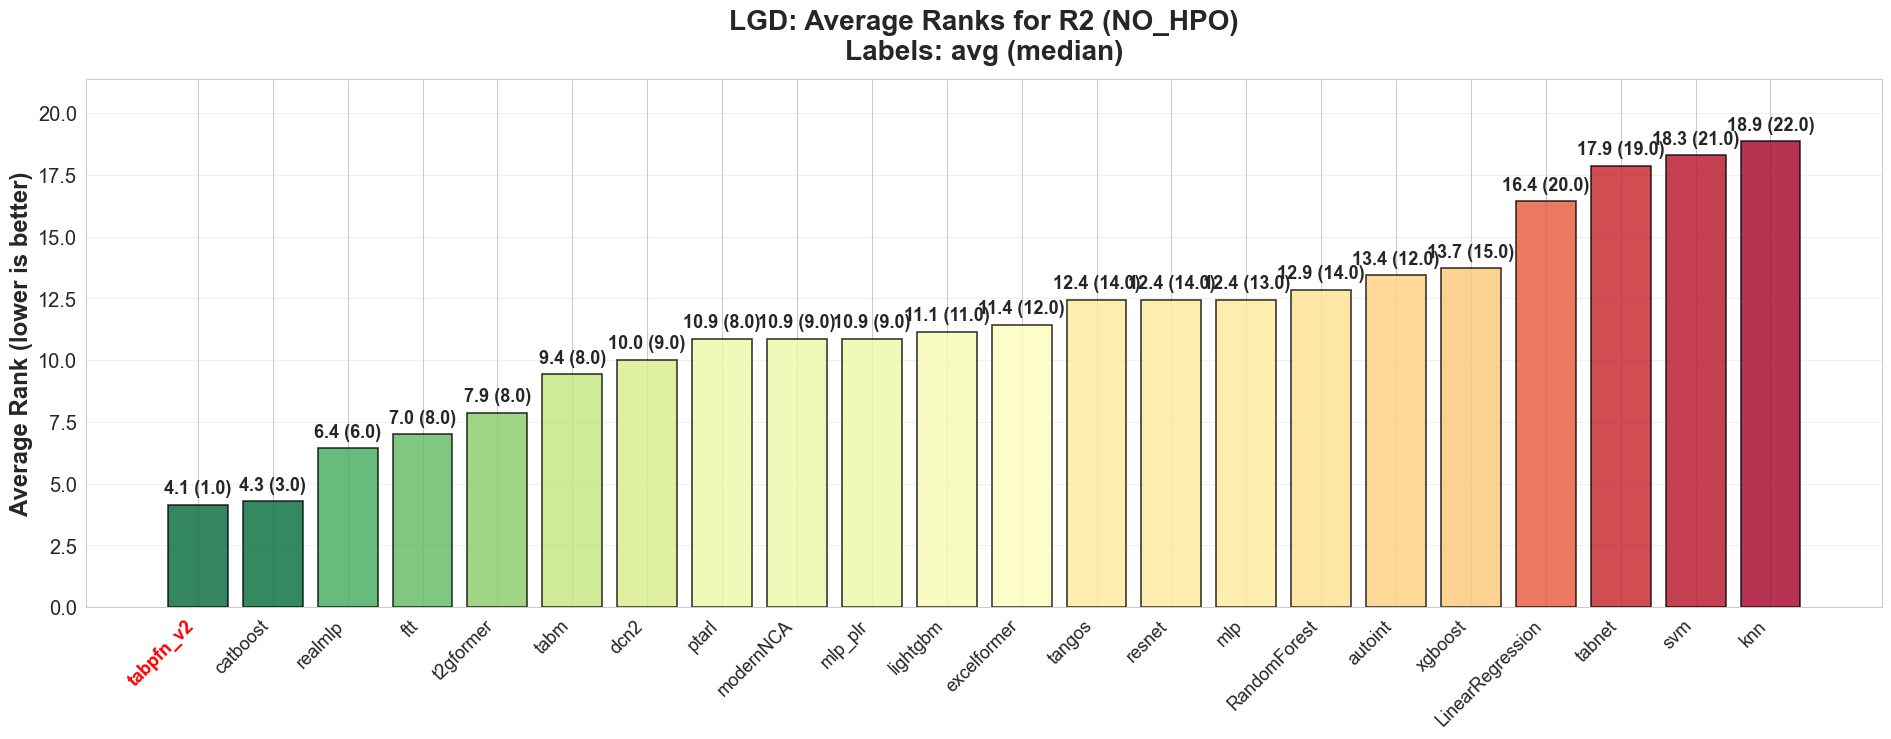

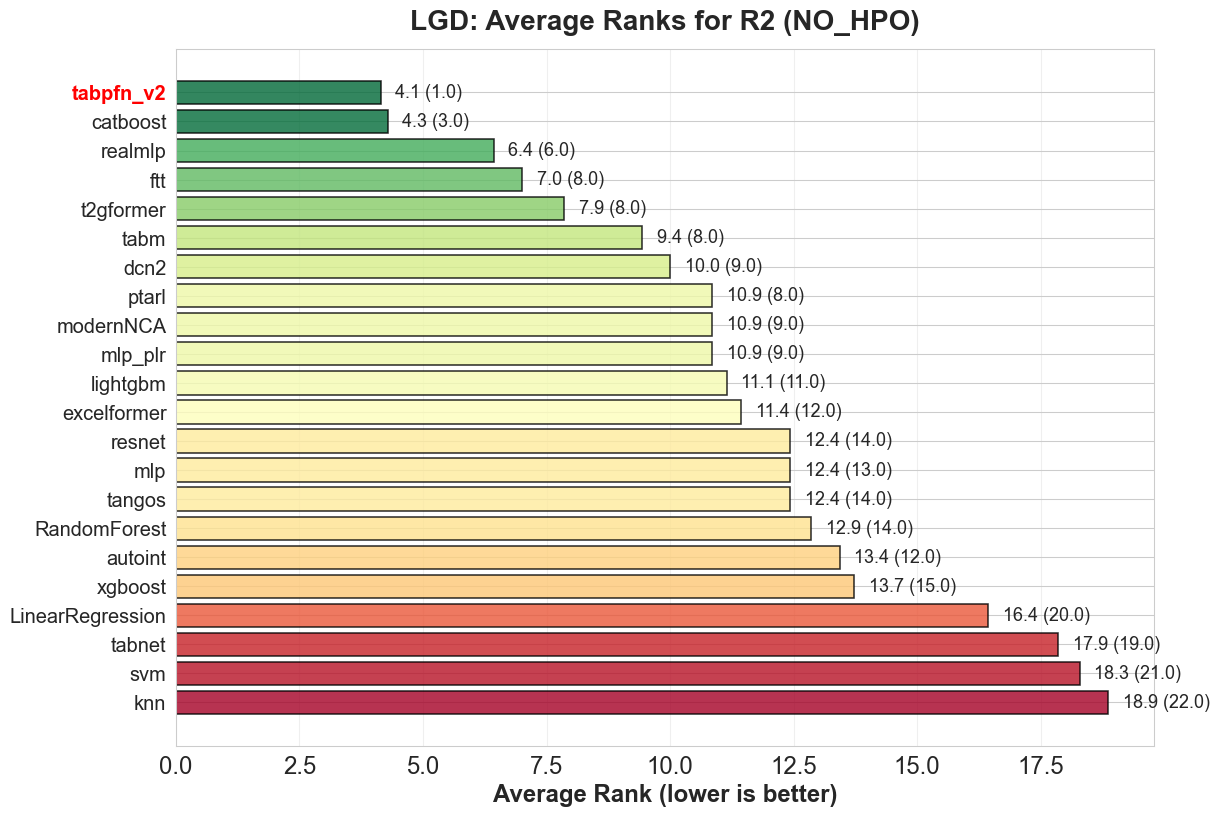


Creating LGD average rank bar chart (HPO)...
Saved: lgd_bar_rank_r2_hpo.png
Saved: lgd_bar_rank_r2_hpo_horizontal.png


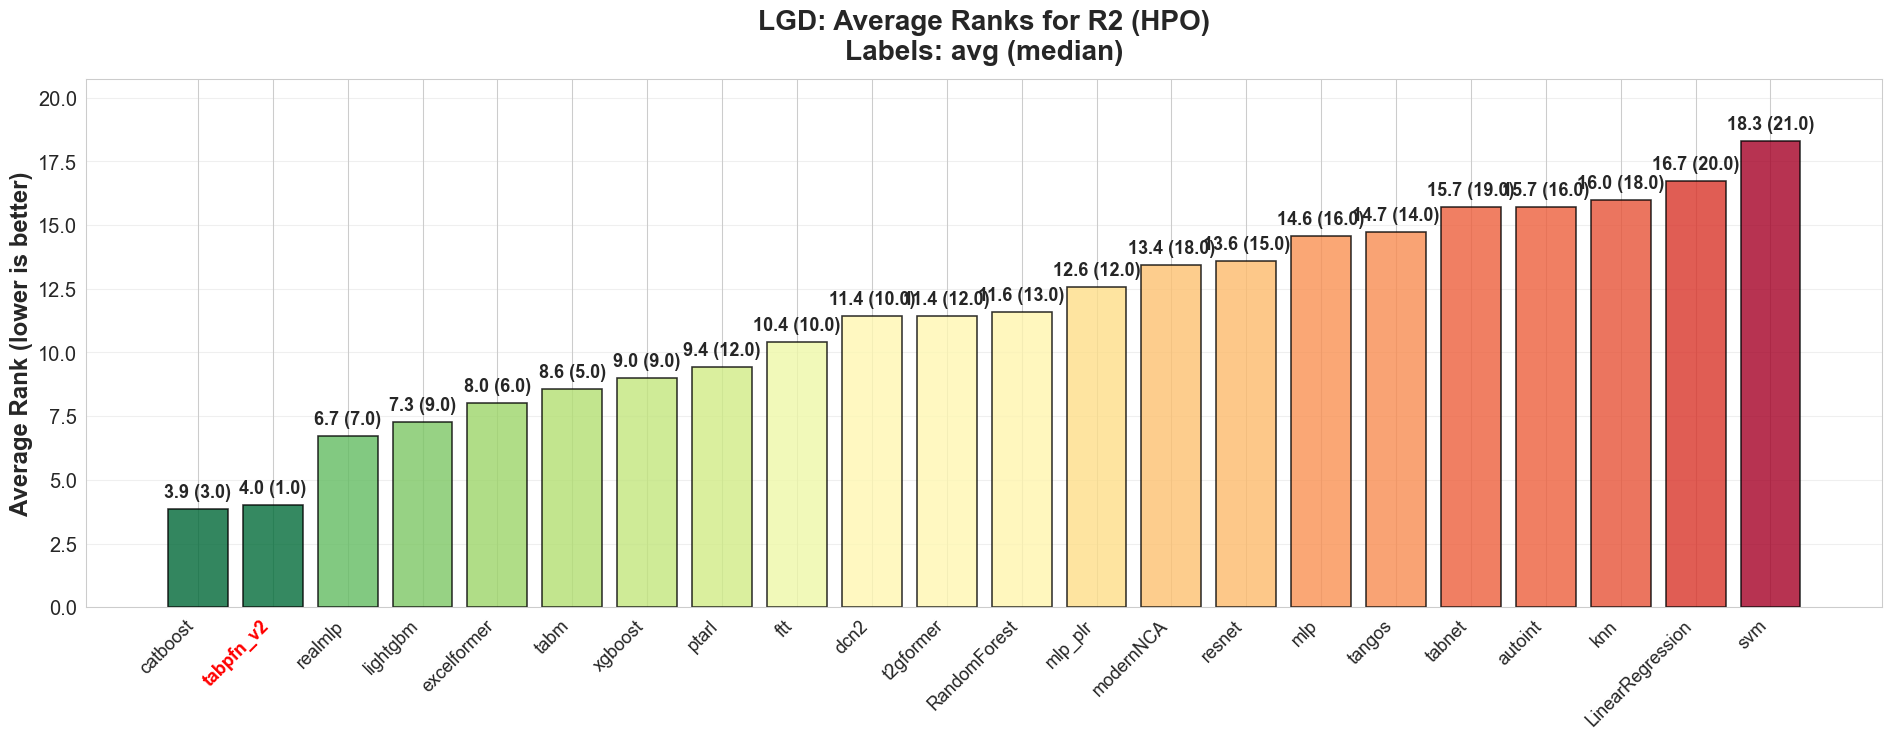

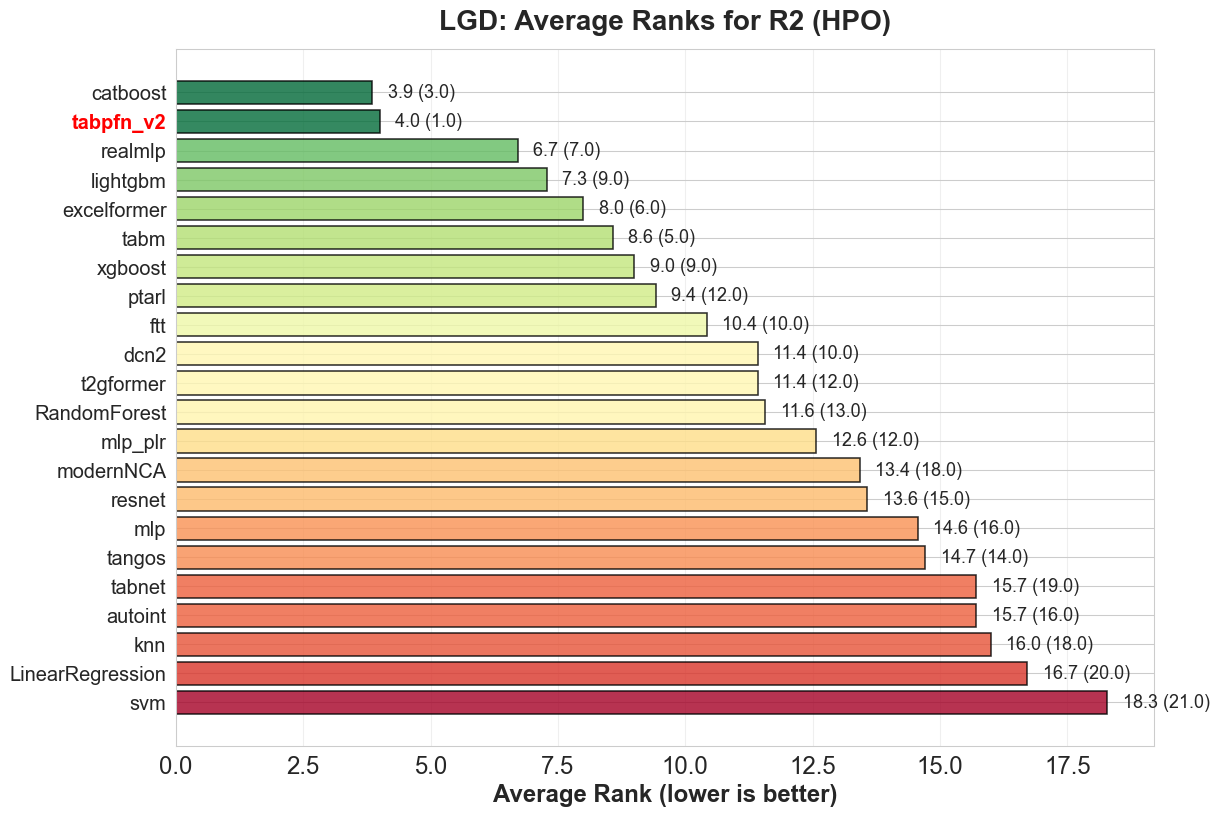

In [13]:
if avg_ranks_lgd_no_hpo is not None:
    print("Creating LGD average rank bar chart (NO_HPO)...")
    plot_rank_bar(avg_ranks_lgd_no_hpo, median_ranks_lgd_no_hpo, 'LGD', 'R2', 'NO_HPO')
    plt.show()

if avg_ranks_lgd_hpo is not None:
    print("\nCreating LGD average rank bar chart (HPO)...")
    plot_rank_bar(avg_ranks_lgd_hpo, median_ranks_lgd_hpo, 'LGD', 'R2', 'HPO')
    plt.show()

---

## C1. Load Dataset Characteristics

In [14]:
print("\n" + "=" * 80)
print("  LOADING DATASET CHARACTERISTICS")
print("=" * 80)

# Find processed data directory
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

# DataFeeder PCA settings (from data_feeder.py)
MAX_FEATURES_THRESHOLD = 100  # PCA triggered if features exceed this
PCA_TARGET_FEATURES = 99       # Target number of PCA components

print(f"\n📂 Looking for processed data in: {PROCESSED_DATA_DIR}")

if not PROCESSED_DATA_DIR.exists():
    print(f"⚠️  Processed data directory not found: {PROCESSED_DATA_DIR}")
    print("   Run preprocessing first to generate processed datasets!")
else:
    print(f"✓ Found processed data directory")

# Collect dataset characteristics
dataset_info = []

# Get unique datasets from results
all_datasets_pd = pd_raw['dataset'].unique()
all_datasets_lgd = lgd_raw['dataset'].unique()

print(f"\n📊 Extracting characteristics for {len(all_datasets_pd)} PD datasets and {len(all_datasets_lgd)} LGD datasets...")

# Function to get dataset characteristics
def get_dataset_characteristics(dataset_name, task):
    """
    Extract dataset characteristics from processed numpy arrays.
    
    Reflects the ACTUAL features used during training:
    - If total features > 100, PCA reduces to 99 components
    - Otherwise, uses original feature count
    
    The preprocessing pipeline stores datasets as:
    data/processed/{task}/{dataset}/
        ├── N.npy (numerical features) - shape: (n_samples, n_num_features)
        ├── C.npy (categorical features) - shape: (n_samples, n_cat_features)  
        ├── y.npy (target) - shape: (n_samples,)
        └── info.json (metadata)
    """
    if not PROCESSED_DATA_DIR.exists():
        return None
    
    # Build path: data/processed/{task}/{dataset}/
    task_dir = PROCESSED_DATA_DIR / task.lower() / dataset_name
    
    # Check if directory exists
    if not task_dir.exists():
        return None
    
    # Check if required files exist
    y_path = task_dir / "y.npy"
    if not y_path.exists():
        return None
    
    try:
        # Load target array to get number of rows and statistics
        y = np.load(y_path, allow_pickle=False)
        n_rows = len(y)
        
        # --- NEW: Calculate Class Imbalance for PD ---
        pos_class_rate = np.nan
        if task == 'PD':
            # Assuming binary classification where 1 is the default class
            # Calculate mean (proportion of 1s)
            pos_class_rate = np.mean(y)
        
        # Count numerical features
        n_num_features = 0
        N_path = task_dir / "N.npy"
        if N_path.exists():
            N = np.load(N_path, allow_pickle=False)
            if N.ndim == 2:
                n_num_features = N.shape[1]
            elif N.ndim == 1:
                n_num_features = 1
        
        # Count categorical features
        n_cat_features = 0
        C_path = task_dir / "C.npy"
        if C_path.exists():
            C = np.load(C_path, allow_pickle=False)
            if C.ndim == 2:
                n_cat_features = C.shape[1]
            elif C.ndim == 1:
                n_cat_features = 1
        
        # Total features BEFORE PCA
        n_features_raw = n_num_features + n_cat_features
        
        # Apply DataFeeder logic: if features > threshold, PCA reduces to target
        if n_features_raw > MAX_FEATURES_THRESHOLD:
            n_features_actual = PCA_TARGET_FEATURES
            pca_applied = True
        else:
            n_features_actual = n_features_raw
            pca_applied = False
        
        return {
            'dataset': dataset_name,
            'task': task,
            'n_rows': n_rows,
            'n_features': n_features_actual,  # Features AFTER potential PCA
            'n_features_raw': n_features_raw, # Features BEFORE PCA
            'n_num_features': n_num_features,
            'n_cat_features': n_cat_features,
            'pos_class_rate': pos_class_rate, # New characteristic: % of defaults
            'pca_applied': pca_applied,
            'dimensionality': n_rows * n_features_actual,
            'source': 'numpy_arrays'
        }
        
    except Exception as e:
        print(f"⚠️  Error loading numpy arrays for {dataset_name}: {e}")
        return None

# Collect info for all datasets
print("\n🔍 Processing datasets...")
found_count = 0
missing_count = 0

# --- Process PD ---
for dataset in all_datasets_pd:
    info = get_dataset_characteristics(dataset, 'PD')
    if info:
        dataset_info.append(info)
        found_count += 1
        pca_note = " [PCA→99]" if info['pca_applied'] else ""
        imbalance_str = f", {info['pos_class_rate']:.1%} defaults"
        print(f"  ✓ {dataset:30s} - {info['n_rows']:>8,} rows, {info['n_features']:>3} features ({info['n_num_features']} num + {info['n_cat_features']} cat){pca_note}{imbalance_str}")
    else:
        missing_count += 1
        print(f"  ✗ {dataset:30s} - NOT FOUND in processed directory")

# --- Process LGD ---
for dataset in all_datasets_lgd:
    info = get_dataset_characteristics(dataset, 'LGD')
    if info:
        dataset_info.append(info)
        found_count += 1
        pca_note = " [PCA→99]" if info['pca_applied'] else ""
        print(f"  ✓ {dataset:30s} - {info['n_rows']:>8,} rows, {info['n_features']:>3} features ({info['n_num_features']} num + {info['n_cat_features']} cat){pca_note}")
    else:
        missing_count += 1
        print(f"  ✗ {dataset:30s} - NOT FOUND in processed directory")

# Create DataFrame
if dataset_info:
    dataset_chars = pd.DataFrame(dataset_info)
    
    # Drop internal columns from display
    display_df = dataset_chars.drop(columns=['source', 'n_num_features', 'n_cat_features', 'n_features_raw', 'pca_applied'], errors='ignore')
    
    # Rename column for clarity
    display_df = display_df.rename(columns={'pos_class_rate': 'default_rate'})
    
    print(f"\n{'='*80}")
    print(f"✅ Successfully loaded {found_count} datasets")
    if missing_count > 0:
        print(f"⚠️  {missing_count} datasets not found (need preprocessing)")
    print(f"{'='*80}")
    
    # Show how many datasets had PCA applied
    n_pca = dataset_chars['pca_applied'].sum()
    if n_pca > 0:
        print(f"\n📊 {n_pca} datasets will use PCA (features > {MAX_FEATURES_THRESHOLD} → reduced to {PCA_TARGET_FEATURES})")
    
    print(f"\nDataset characteristics summary:")
    print(display_df[['n_rows', 'n_features', 'dimensionality']].describe())
    
    print(f"\nAll datasets (with default rates for PD):")
    # Format the default_rate column to percentage string for display
    display_df['default_rate'] = display_df['default_rate'].apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "-")
    print(display_df.to_string(index=False))
    
else:
    dataset_chars = pd.DataFrame()
    print(f"\n{'='*80}")
    print("⚠️  NO datasets found in processed directory!")
    print(f"{'='*80}")
    print("\n💡 Next steps:")
    print("   1. Make sure datasets have been preprocessed")
    print("   2. Check that processed files exist in:")
    print(f"      {PROCESSED_DATA_DIR}/{{task}}/{{dataset}}/")
    print("   3. Each dataset folder should contain: N.npy, C.npy, y.npy")


  LOADING DATASET CHARACTERISTICS

📂 Looking for processed data in: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\data\processed
✓ Found processed data directory

📊 Extracting characteristics for 14 PD datasets and 7 LGD datasets...

🔍 Processing datasets...
  ✓ 0001.gmsc                      -  150,000 rows,  10 features (10 num + 0 cat), 6.7% defaults
  ✓ 0002.taiwan_creditcard         -   30,000 rows,  23 features (23 num + 0 cat), 22.1% defaults
  ✓ 0003.vehicle_loan              -  233,154 rows,  35 features (32 num + 3 cat), 21.7% defaults
  ✓ 0004.lendingclub               -    9,578 rows,  13 features (12 num + 1 cat), 16.0% defaults
  ✓ 0005.myhom                     -    7,000 rows,   8 features (7 num + 1 cat), 40.0% defaults
  ✓ 0006.hackerearth               -  532,428 rows,  35 features (27 num + 8 cat), 23.6% defaults
  ✓ 0007.cobranded                 -   80,000 rows,  47 features (47 num + 0 cat), 24.6% defaults
  ✓ 0008.german                    -  

## C4. LGD: Rank vs Dataset Characteristics


  LGD - RANK CORRELATION WITH DATASET CHARACTERISTICS

📊 Spearman Correlations (Rank vs Dataset Characteristics)
   Positive correlation = higher rank (worse) on larger/more complex datasets
   Negative correlation = lower rank (better) on larger/more complex datasets

Method                     Size    p-val   Features    p-val
------------------------------------------------------------
tabpfn_v2                0.802*    0.030    -0.360     0.428
catboost                 0.767*    0.044    -0.566     0.185
lightgbm                -0.018     0.969    -0.193     0.679
xgboost                 -0.286     0.535    -0.090     0.848
tabm                    -0.541     0.210    -0.227     0.624
realmlp                 -0.400     0.374     0.468     0.290
excelformer              0.000     1.000    -0.019     0.968
RandomForest            -0.108     0.818    -0.191     0.682
ptarl                    0.393     0.383     0.090     0.848
t2gformer               -0.404     0.369    -0.046     0.9

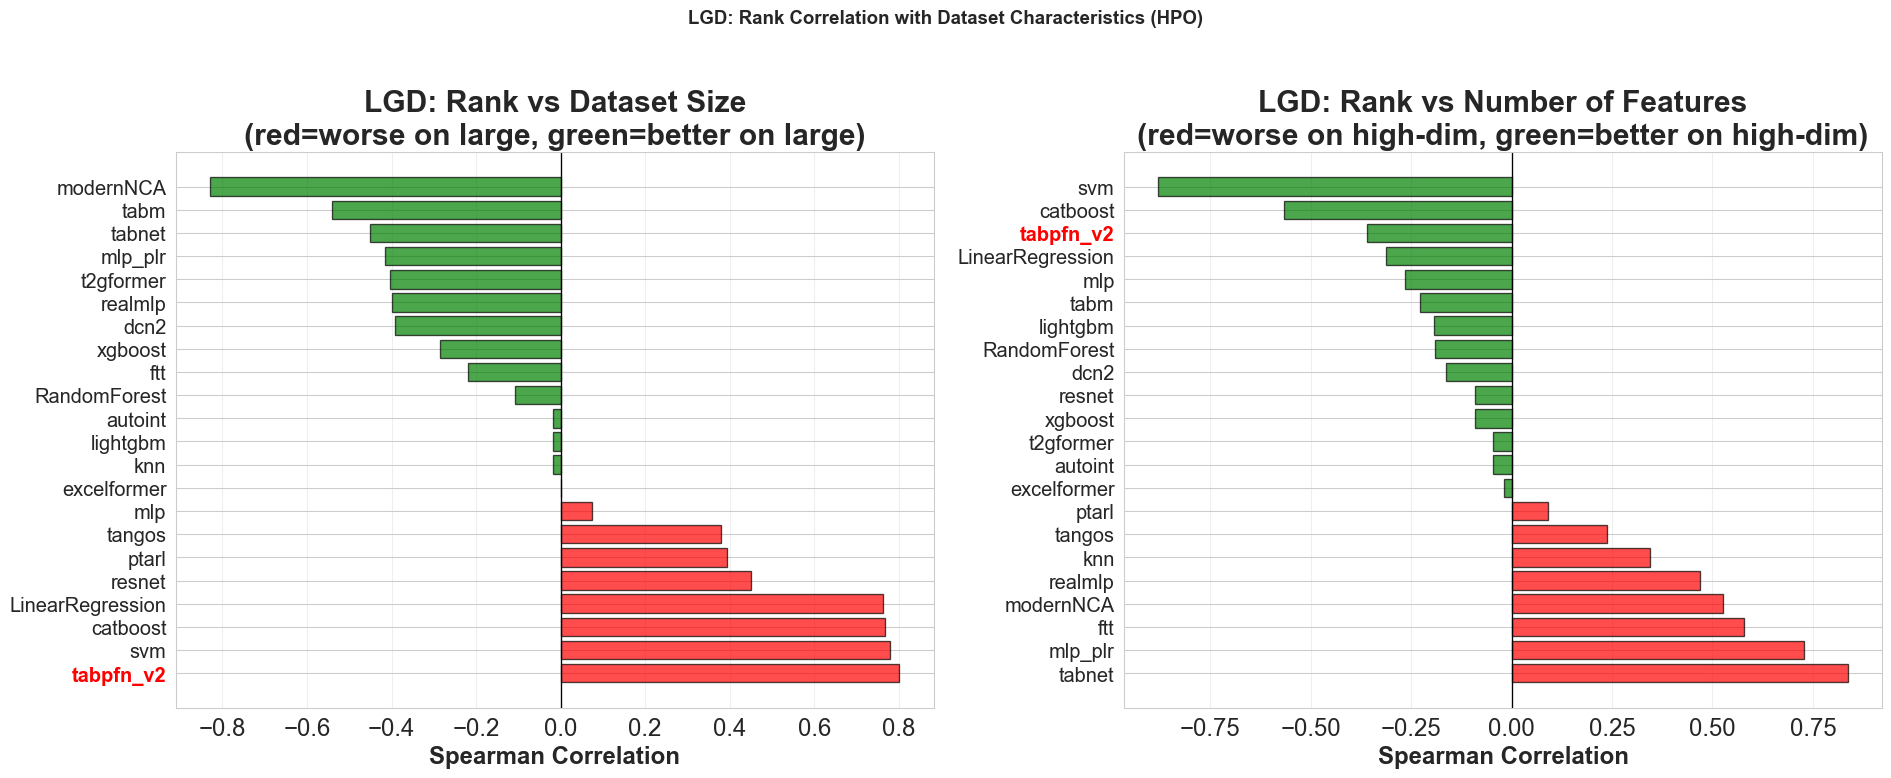

In [15]:
print("\n" + "=" * 80)
print("  LGD - RANK CORRELATION WITH DATASET CHARACTERISTICS")
print("=" * 80)

if not dataset_chars.empty and pivot_lgd_hpo is not None:
    # Calculate ranks for each method across datasets
    ranks_df = pivot_lgd_hpo.rank(axis=1, ascending=False, method='average')

    # Get LGD datasets
    lgd_chars = dataset_chars[dataset_chars['task'] == 'LGD'].copy()
    lgd_chars = lgd_chars.set_index('dataset')

    correlations = []

    for method in ranks_df.columns:
        method_ranks = ranks_df[method]
        common_datasets = method_ranks.index.intersection(lgd_chars.index)

        if len(common_datasets) > 3:
            aligned_ranks = method_ranks.loc[common_datasets]
            aligned_chars = lgd_chars.loc[common_datasets]

            if aligned_chars['n_rows'].notna().sum() > 3:
                corr_size, p_size = stats.spearmanr(aligned_ranks, aligned_chars['n_rows'].fillna(aligned_chars['n_rows'].median()))
            else:
                corr_size, p_size = np.nan, np.nan

            if aligned_chars['n_features'].notna().sum() > 3:
                corr_features, p_features = stats.spearmanr(aligned_ranks, aligned_chars['n_features'].fillna(aligned_chars['n_features'].median()))
            else:
                corr_features, p_features = np.nan, np.nan

            correlations.append({
                'method': method,
                'corr_size': corr_size, 'p_size': p_size,
                'corr_features': corr_features, 'p_features': p_features,
            })

    corr_df = pd.DataFrame(correlations)

    if not corr_df.empty:
        print("\n\U0001f4ca Spearman Correlations (Rank vs Dataset Characteristics)")
        print("   Positive correlation = higher rank (worse) on larger/more complex datasets")
        print("   Negative correlation = lower rank (better) on larger/more complex datasets\n")

        print(f"{'Method':<20} {'Size':>10} {'p-val':>8} {'Features':>10} {'p-val':>8}")
        print("-" * 60)

        for _, row in corr_df.iterrows():
            sig_size = "*" if row['p_size'] < 0.05 else " "
            sig_feat = "*" if row['p_features'] < 0.05 else " "

            print(f"{row['method']:<20} {row['corr_size']:>9.3f}{sig_size} {row['p_size']:>8.3f} "
                  f"{row['corr_features']:>9.3f}{sig_feat} {row['p_features']:>8.3f}")

        # Create visualization (1x2: Size and Features only)
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))

        def plot_corr_bar_lgd(ax, data, col_name, title):
            corr_sorted = data.sort_values(col_name, ascending=False)
            colors = ['red' if x > 0 else 'green' for x in corr_sorted[col_name]]
            ax.barh(range(len(corr_sorted)), corr_sorted[col_name], color=colors, alpha=0.7, edgecolor='black')
            ax.set_yticks(range(len(corr_sorted)))
            ax.set_yticklabels(corr_sorted['method'])
            ax.set_xlabel('Spearman Correlation', fontweight='bold')
            ax.set_title(title, fontweight='bold')
            ax.axvline(0, color='black', linewidth=1)
            ax.grid(axis='x', alpha=0.3)

            # Color foundation model labels red
            for label in ax.get_yticklabels():
                if label.get_text() in FOUNDATION_METHODS:
                    label.set_color('red')
                    label.set_fontweight('bold')

        plot_corr_bar_lgd(axes[0], corr_df, 'corr_size',
                          'LGD: Rank vs Dataset Size\n(red=worse on large, green=better on large)')

        plot_corr_bar_lgd(axes[1], corr_df, 'corr_features',
                          'LGD: Rank vs Number of Features\n(red=worse on high-dim, green=better on high-dim)')

        plt.suptitle('LGD: Rank Correlation with Dataset Characteristics (HPO)',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        filename = FIGURES_DIR / "lgd_rank_correlation_dataset_chars.png"
        plt.savefig(filename, dpi=600, bbox_inches='tight')
        print(f"\n\u2705 Saved: {filename.name}")
        plt.show()
    else:
        print("\u26a0\ufe0f  Not enough data for correlation analysis")
else:
    print("\u26a0\ufe0f  Dataset characteristics or HPO results not available")

## C5. LGD: Rank vs Dataset Characteristics per method


  LGD - RANK SCATTER PLOTS (Dataset-Level Ranks)
✓ Using aggregated data with metric: 'R2_mean'
✓ Pivot table shape: (7, 22)
  - Datasets: 7
  - Methods: 22
✓ Ranks calculated for 154 dataset-method combinations
✓ Merged data: 154 dataset-method combinations
  - Datasets with characteristics: 7
✓ Methods to plot: ['tabpfn_v2', 'catboost']

  tabpfn_v2:
    - Datasets: 7
    - Rank range: 1.00 - 21.00
    - Rank 1 count: 5 datasets
    - Average rank: 4.00
  catboost:
    - Datasets: 7
    - Rank range: 2.00 - 8.00
    - Rank 1 count: 0 datasets
    - Average rank: 3.86

✅ Saved: lgd_rank_scatter_tabpfn_v2.png


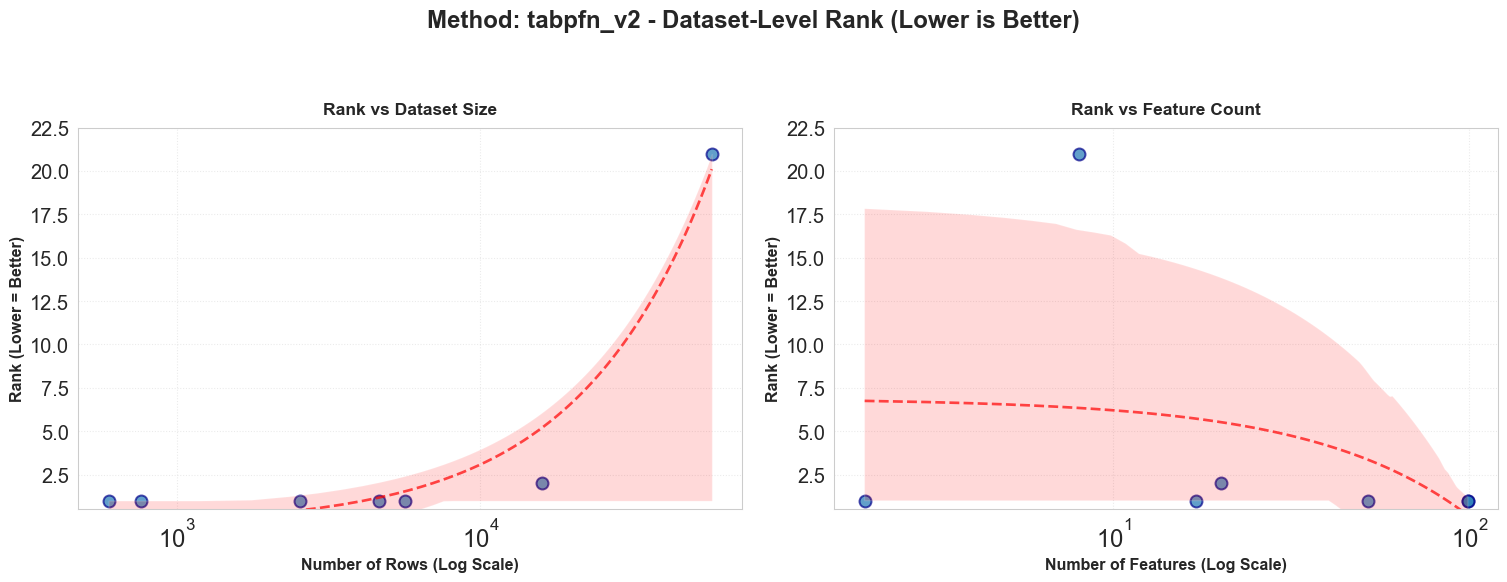


✅ Saved: lgd_rank_scatter_catboost.png


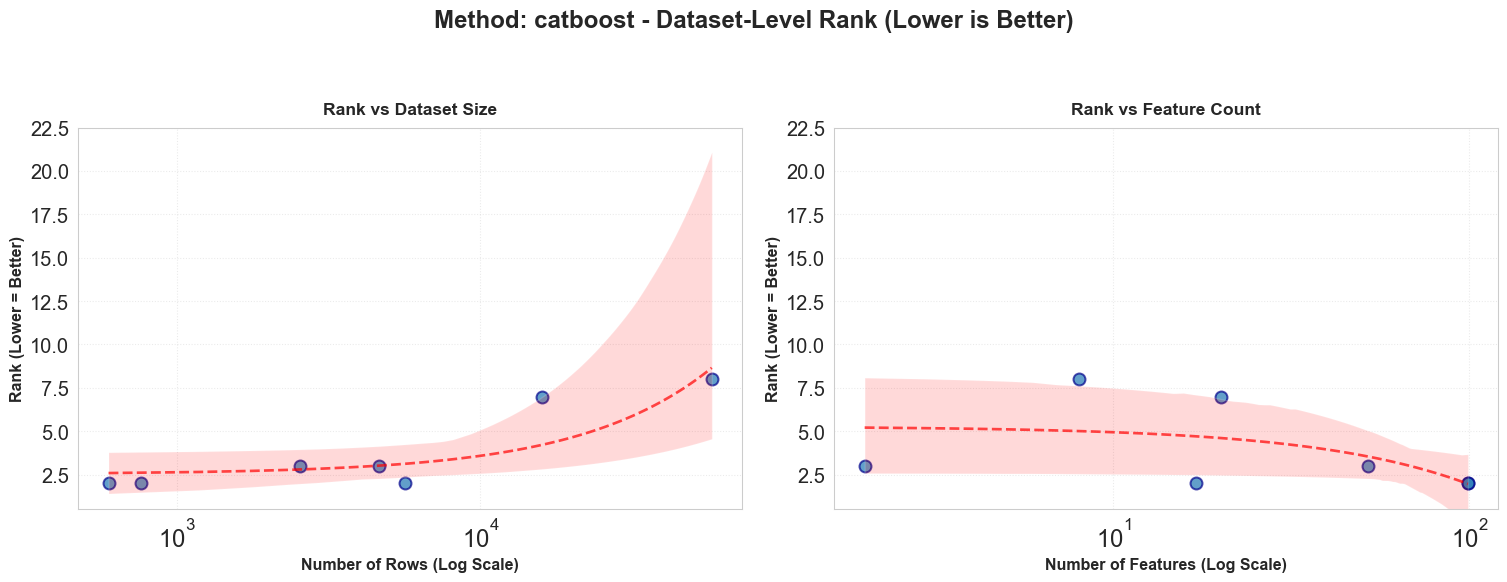


✅ All scatter plots generated successfully!
  These plots now use EXACTLY the same ranking as the heatmap:
  - Ranks based on mean R² per dataset
  - Each dot = one dataset
  - Rank 1 dots should match heatmap exactly


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from scipy import stats

# ==============================================================================
# CONFIGURATION
# ==============================================================================
METHODS_TO_ANALYZE = ['tabpfn', 'tabpfn_v2', 'catboost', 'tabicl']

print("\n" + "="*80)
print("  LGD - RANK SCATTER PLOTS (Dataset-Level Ranks)")
print("="*80)

if 'lgd_agg' not in locals() or 'dataset_chars' not in locals():
    print("⚠️  Error: 'lgd_agg' or 'dataset_chars' not found. Please run the previous data loading cells.")
else:
    # ==============================================================================
    # USE THE EXACT SAME RANKING METHODOLOGY AS THE HEATMAP
    # ==============================================================================
    
    # 1. Filter for HPO mode only (same as heatmap)
    lgd_agg_hpo = lgd_agg[lgd_agg['hpo_mode'] == 'HPO'].copy()
    
    # 2. Identify the metric column
    metric_col = 'R2_mean'  # Aggregated mean R² per dataset
    
    if metric_col not in lgd_agg_hpo.columns:
        print(f"⚠️  Error: '{metric_col}' not found in lgd_agg")
        print(f"   Available columns: {list(lgd_agg_hpo.columns)}")
    else:
        print(f"✓ Using aggregated data with metric: '{metric_col}'")
        
        # 3. Create pivot table (same as heatmap)
        pivot = lgd_agg_hpo.pivot(index='dataset', columns='method', values=metric_col)
        
        print(f"✓ Pivot table shape: {pivot.shape}")
        print(f"  - Datasets: {len(pivot)}")
        print(f"  - Methods: {len(pivot.columns)}")
        
        # 4. Calculate ranks (EXACT SAME as heatmap: rank across methods for each dataset)
        ranks_df = pivot.rank(axis=1, ascending=False, method='average')
        
        # 5. Convert ranks to long format for plotting
        ranks_long = ranks_df.reset_index().melt(
            id_vars='dataset', 
            var_name='method', 
            value_name='rank'
        )
        
        print(f"✓ Ranks calculated for {len(ranks_long)} dataset-method combinations")
        
        # 6. Prepare dataset characteristics (LGD only)
        lgd_chars = dataset_chars[dataset_chars['task'] == 'LGD'].copy()
        
        # 7. Merge ranks with dataset characteristics
        plot_data = pd.merge(ranks_long, lgd_chars, on='dataset', how='inner')
        
        print(f"✓ Merged data: {len(plot_data)} dataset-method combinations")
        print(f"  - Datasets with characteristics: {plot_data['dataset'].nunique()}")
        
        # Filter for the specific methods requested
        valid_methods = [m for m in METHODS_TO_ANALYZE if m in plot_data['method'].unique()]
        print(f"✓ Methods to plot: {valid_methods}\n")
        
        # Print diagnostic info for each method
        for method in valid_methods:
            method_data = plot_data[plot_data['method'] == method]
            if not method_data.empty:
                print(f"  {method}:")
                print(f"    - Datasets: {len(method_data)}")
                print(f"    - Rank range: {method_data['rank'].min():.2f} - {method_data['rank'].max():.2f}")
                print(f"    - Rank 1 count: {(method_data['rank'] == 1.0).sum()} datasets")
                print(f"    - Average rank: {method_data['rank'].mean():.2f}")
        
        # ==============================================================================
        # GENERATE PLOTS (3 plots: rows, features, dimensionality - NO class imbalance)
        # ==============================================================================
        sns.set_style("whitegrid")
        
        for method in valid_methods:
            method_data = plot_data[plot_data['method'] == method].copy()
            if method_data.empty: 
                print(f"⚠️  No data for method: {method}")
                continue
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            fig.suptitle(f"Method: {method} - Dataset-Level Rank (Lower is Better)", 
                        fontsize=18, fontweight='bold', y=1.02)
            
            # Helper for clean plotting
            def plot_clean(ax, x_col, label, log_scale=False):
                if x_col not in method_data.columns: 
                    ax.text(0.5, 0.5, f'No {label} data', ha='center', va='center', 
                           transform=ax.transAxes, fontsize=12)
                    return
                
                # Remove NaN values for this specific plot
                plot_subset = method_data[[x_col, 'rank', 'dataset']].dropna()
                
                if len(plot_subset) == 0:
                    ax.text(0.5, 0.5, f'No valid {label} data', ha='center', va='center', 
                           transform=ax.transAxes, fontsize=12)
                    return
                
                # Scatter: Blue dots
                scatter = ax.scatter(
                    plot_subset[x_col], plot_subset['rank'],
                    color='tab:blue', s=80, alpha=0.7, edgecolor='darkblue', linewidth=1.5
                )
                
                # Trendline
                try:
                    sns.regplot(
                        data=plot_subset, x=x_col, y='rank',
                        ax=ax, scatter=False, color='red',
                        line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.7}
                    )
                except Exception as e:
                    print(f"  ⚠️  Could not fit trendline for {label}: {e}")
                
                # Formatting
                ax.set_xlabel(label, fontsize=12, fontweight='bold')
                ax.set_ylabel('Rank (Lower = Better)', fontsize=12, fontweight='bold')
                
                # Y-axis: Start from 0.5, go up to max rank + 0.5
                y_max = plot_data['rank'].max() + 0.5
                ax.set_ylim(0.5, y_max)
                
                # Log scale for x if requested
                if log_scale:
                    ax.set_xscale('log')
                
                # Grid
                ax.grid(True, linestyle=':', alpha=0.4, linewidth=0.8)

            # Plot 1: Rows (Left) - Log scale
            plot_clean(axes[0], 'n_rows', 'Number of Rows (Log Scale)', log_scale=True)
            axes[0].set_title("Rank vs Dataset Size", fontsize=13, pad=10, fontweight='bold')

            # Plot 2: Features (Middle) - Log scale
            plot_clean(axes[1], 'n_features', 'Number of Features (Log Scale)', log_scale=True)
            axes[1].set_title("Rank vs Feature Count", fontsize=13, pad=10, fontweight='bold')


            plt.tight_layout(rect=[0, 0, 1, 0.98])
            
            filename = FIGURES_DIR / f"lgd_rank_scatter_{method}.png"
            plt.savefig(filename, dpi=600, bbox_inches='tight')
            print(f"\n✅ Saved: {filename.name}")
            plt.show()
            
        print("\n" + "="*80)
        print("✅ All scatter plots generated successfully!")
        print("  These plots now use EXACTLY the same ranking as the heatmap:")
        print("  - Ranks based on mean R² per dataset")
        print("  - Each dot = one dataset")
        print("  - Rank 1 dots should match heatmap exactly")
        print("="*80)

---

## D2. LGD Training Time Analysis


  LGD - TRAINING TIME ANALYSIS (NO_HPO)

Creating LGD training time heatmap (NO_HPO)...
✅ Saved: lgd_training_time_total_no_hpo.png


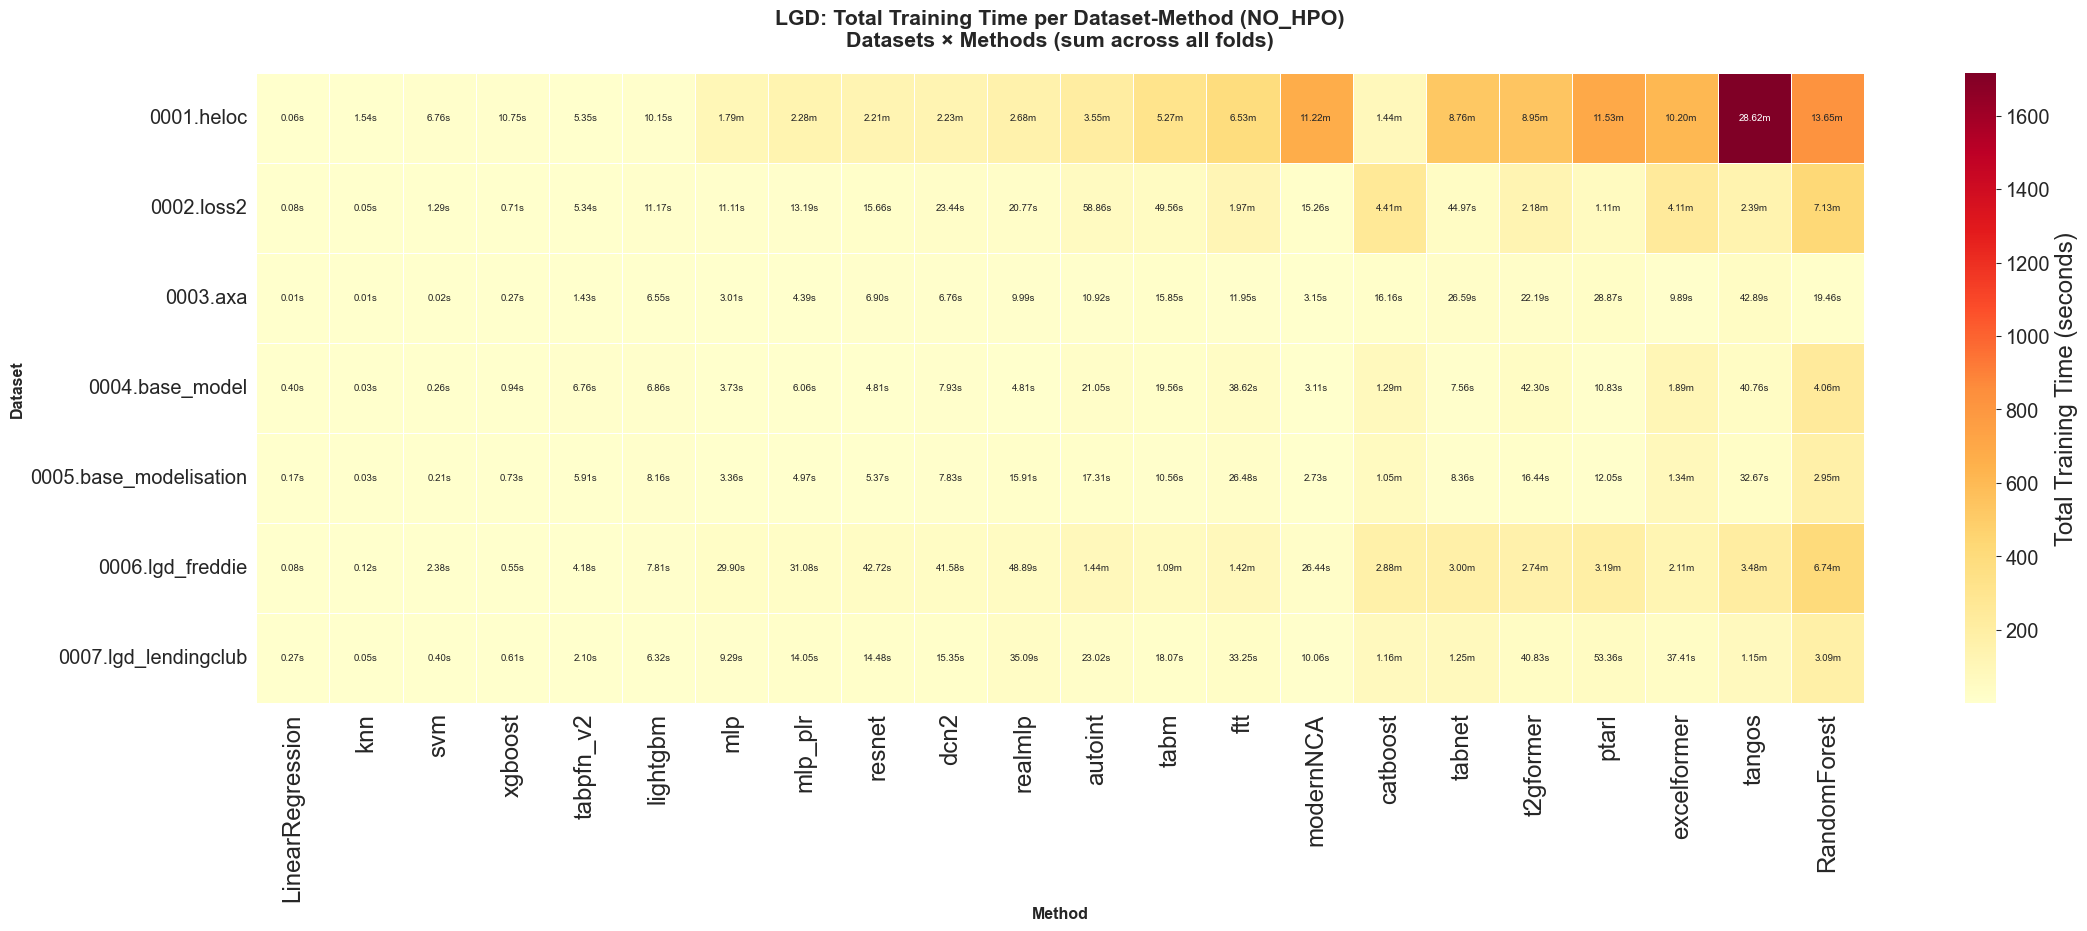


Creating LGD training time rank matrix (NO_HPO)...
✅ Saved: lgd_training_time_ranks_no_hpo.png


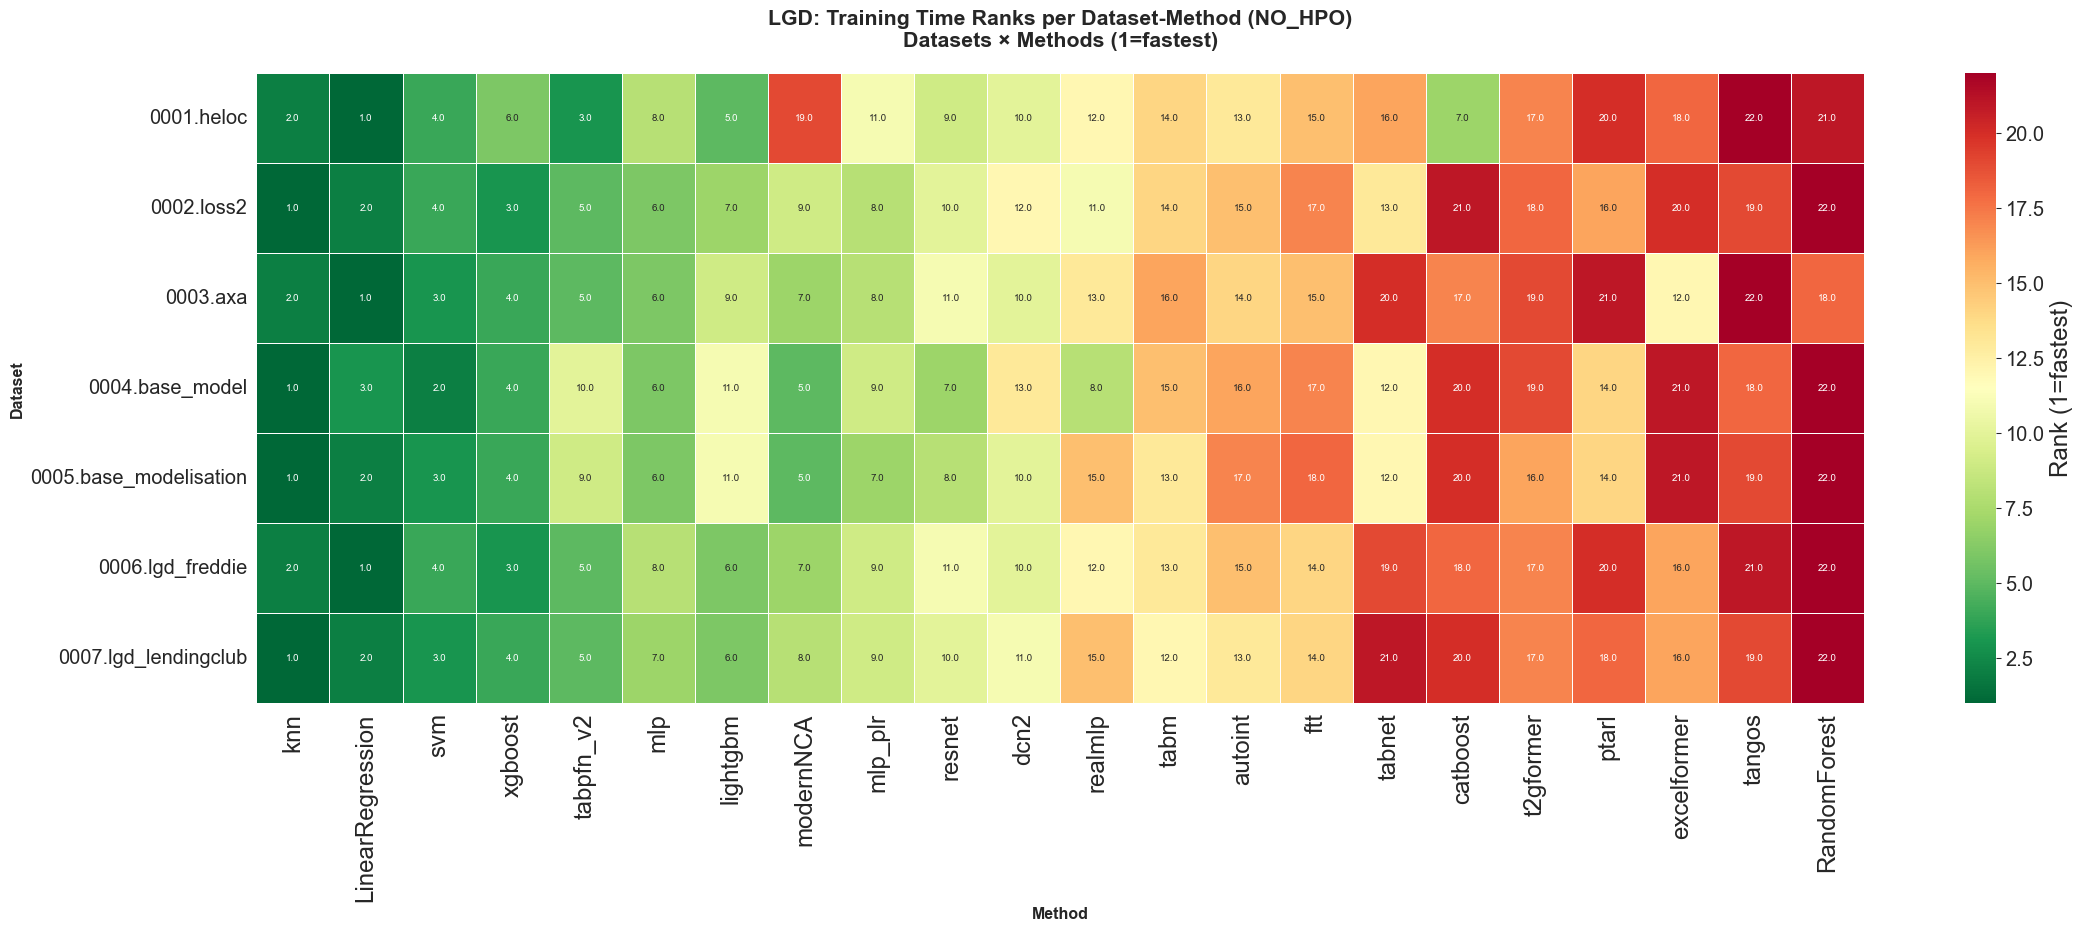


  TRAINING TIME SUMMARY (NO_HPO)

Average Total Training Time per Method:
  LinearRegression    :      0.15s
  knn                 :      0.26s
  svm                 :      1.62s
  xgboost             :      2.08s
  tabpfn_v2           :      4.44s
  lightgbm            :      8.14s
  mlp                 :     23.95s
  mlp_plr             :     30.08s
  resnet              :     31.82s
  dcn2                :     33.80s
  realmlp             :     42.33s
  autoint             :      1.02m
  tabm                :      1.18m
  ftt                 :      1.68m
  modernNCA           :      1.75m
  catboost            :      1.79m
  tabnet              :      2.07m
  t2gformer           :      2.27m
  ptarl               :      2.51m
  excelformer         :      2.92m
  tangos              :      5.37m
  RandomForest        :      5.42m



In [17]:
print("\n" + "=" * 80)
print("  LGD - TRAINING TIME ANALYSIS (NO_HPO)")
print("=" * 80)

# Helper function to format time
def format_time(seconds):
    """Format time as minutes or seconds with appropriate suffix."""
    if seconds >= 60:
        minutes = seconds / 60
        return f"{minutes:.2f}m"
    else:
        return f"{seconds:.2f}s"

# Check if training time data is available in raw results
if 'train_time' in lgd_raw.columns:
    # Calculate TOTAL training time per method-dataset (sum across all folds)
    time_summary = lgd_raw.groupby(['dataset', 'method', 'hpo_mode'])['train_time'].sum().reset_index()
    time_summary.rename(columns={'train_time': 'total_train_time'}, inplace=True)
    
    # Filter for NO_HPO only
    df_no_hpo = time_summary[time_summary['hpo_mode'] == 'NO_HPO'].copy()
    
    if not df_no_hpo.empty:
        # =======================================================================
        # TRAINING TIME HEATMAP
        # =======================================================================
        print("\nCreating LGD training time heatmap (NO_HPO)...")
        
        pivot_time = df_no_hpo.pivot(index='dataset', columns='method', values='total_train_time')
        pivot_time = pivot_time.sort_index()
        
        # Sort methods by average training time (fastest to slowest)
        method_means = pivot_time.mean(axis=0).sort_values()
        pivot_time = pivot_time[method_means.index]
        
        # Create formatted version for display
        pivot_time_formatted = pivot_time.applymap(format_time)
        
        n_m = pivot_time.shape[1]
        fig, ax = plt.subplots(figsize=(max(24, n_m * 0.8), max(10, pivot_time.shape[0] * 0.8)))
        
        sns.heatmap(
            pivot_time, annot=pivot_time_formatted, fmt='', cmap='YlOrRd',
            cbar_kws={'label': 'Total Training Time (seconds)'}, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': max(5, FS_ANNOT * 0.7)}
        )
        
        ax.set_title('LGD: Total Training Time per Dataset-Method (NO_HPO)\nDatasets × Methods (sum across all folds)', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Method', fontsize=12, fontweight='bold')
        ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        filename = FIGURES_DIR / "lgd_training_time_total_no_hpo.png"
        plt.savefig(filename, dpi=600, bbox_inches='tight')
        print(f"✅ Saved: {filename.name}")
        plt.show()
        
        # =======================================================================
        # TRAINING TIME RANK MATRIX
        # =======================================================================
        print("\nCreating LGD training time rank matrix (NO_HPO)...")
        
        # Calculate ranks (1 = fastest)
        rank_time = pivot_time.rank(axis=1, method='average')
        
        # Sort by average rank
        method_avg_ranks = rank_time.mean(axis=0).sort_values()
        rank_time = rank_time[method_avg_ranks.index]
        
        n_m = pivot_time.shape[1]
        fig, ax = plt.subplots(figsize=(max(24, n_m * 0.8), max(10, pivot_time.shape[0] * 0.8)))
        
        sns.heatmap(
            rank_time, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Rank (1=fastest)'}, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': max(5, FS_ANNOT * 0.7)}
        )
        
        ax.set_title('LGD: Training Time Ranks per Dataset-Method (NO_HPO)\nDatasets × Methods (1=fastest)', 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Method', fontsize=12, fontweight='bold')
        ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        filename = FIGURES_DIR / "lgd_training_time_ranks_no_hpo.png"
        plt.savefig(filename, dpi=600, bbox_inches='tight')
        print(f"✅ Saved: {filename.name}")
        plt.show()
        
        # =======================================================================
        # SUMMARY STATISTICS
        # =======================================================================
        print("\n" + "=" * 80)
        print("  TRAINING TIME SUMMARY (NO_HPO)")
        print("=" * 80)
        
        print("\nAverage Total Training Time per Method:")
        method_totals = df_no_hpo.groupby('method')['total_train_time'].mean().sort_values()
        for method, time_val in method_totals.items():
            print(f"  {method:20s}: {format_time(time_val):>10s}")
        
        print("\n" + "=" * 80)
        
    else:
        print("⚠️  No NO_HPO data available")
        
else:
    print("⚠️  Training time data not available in raw results")
    print("     Expected column: 'train_time'")
    print(f"     Available columns: {list(lgd_raw.columns)}")

---

In [18]:
print("\n" + "=" * 100)
print("  PART F: COMPREHENSIVE TEXT SUMMARY — LGD (ALL METRICS)")
print("=" * 100)

LGD_METRICS = ['R2', 'MSE', 'RMSE', 'MAE', 'MedAE', 'MaxError',
               'Explained_Variance', 'MAPE', 'Pearson_Corr', 'Spearman_Corr']
# Lower is better for these
LGD_LOWER_BETTER = {'MSE', 'RMSE', 'MAE', 'MedAE', 'MaxError', 'MAPE'}

for hpo_mode in ['HPO', 'NO_HPO']:
    print(f"\n{'#' * 100}")
    print(f"  HPO MODE: {hpo_mode}")
    print(f"{'#' * 100}")

    df = lgd_raw[lgd_raw['hpo_mode'] == hpo_mode].copy()
    datasets = sorted(df['dataset'].unique())
    methods = sorted(df['method'].unique())

    for metric in LGD_METRICS:
        if metric not in df.columns:
            continue
        print(f"\n{'=' * 100}")
        print(f"  METRIC: {metric} ({hpo_mode})")
        direction = "(lower is better)" if metric in LGD_LOWER_BETTER else "(higher is better)"
        print(f"  {direction}")
        print(f"{'=' * 100}")

        pivot = df.pivot_table(index='dataset', columns='method', values=metric, aggfunc='mean')
        if pivot.empty:
            print("  No data available.")
            continue

        for ds in datasets:
            if ds not in pivot.index:
                continue
            row = pivot.loc[ds].dropna().sort_values(ascending=(metric in LGD_LOWER_BETTER))
            print(f"\n  Dataset: {ds}")
            print(f"  {'Method':30s}  {metric:>10s}  {'Rank':>5s}")
            print(f"  {'-'*30}  {'-'*10}  {'-'*5}")
            for rank, (method, val) in enumerate(row.items(), 1):
                marker = " *" if method in FOUNDATION_METHODS else ""
                print(f"  {method:30s}  {val:10.4f}  {rank:5d}{marker}")

        means = pivot.mean(axis=0).sort_values(ascending=(metric in LGD_LOWER_BETTER))
        print(f"\n  --- AVERAGE ACROSS ALL {len(datasets)} DATASETS ---")
        print(f"  {'Method':30s}  {'Mean '+metric:>10s}  {'Rank':>5s}")
        print(f"  {'-'*30}  {'-'*10}  {'-'*5}")
        for rank, (method, val) in enumerate(means.items(), 1):
            marker = " *" if method in FOUNDATION_METHODS else ""
            print(f"  {method:30s}  {val:10.4f}  {rank:5d}{marker}")

print("\n" + "=" * 100)
print("  END OF LGD SUMMARY")
print("=" * 100)



  PART F: COMPREHENSIVE TEXT SUMMARY — LGD (ALL METRICS)

####################################################################################################
  HPO MODE: HPO
####################################################################################################

  METRIC: R2 (HPO)
  (higher is better)

  Dataset: 0001.heloc
  Method                                  R2   Rank
  ------------------------------  ----------  -----
  modernNCA                           0.7954      1
  xgboost                             0.6387      2
  lightgbm                            0.5896      3
  tabm                                0.5374      4
  knn                                 0.5351      5
  excelformer                         0.5271      6
  realmlp                             0.5185      7
  catboost                            0.5162      8
  mlp_plr                             0.5142      9
  RandomForest                        0.4969     10
  ftt                              

---
## All LGD Metrics: Average Performance Bar Charts (HPO)

Average of each metric per method across all LGD datasets (mean across 5 CV folds).
Foundation model names shown in red. Bars coloured by RdYlGn colormap.

  ALL LGD METRICS — BAR CHARTS (HPO)
  Saved: lgd_r2_bar_hpo.png


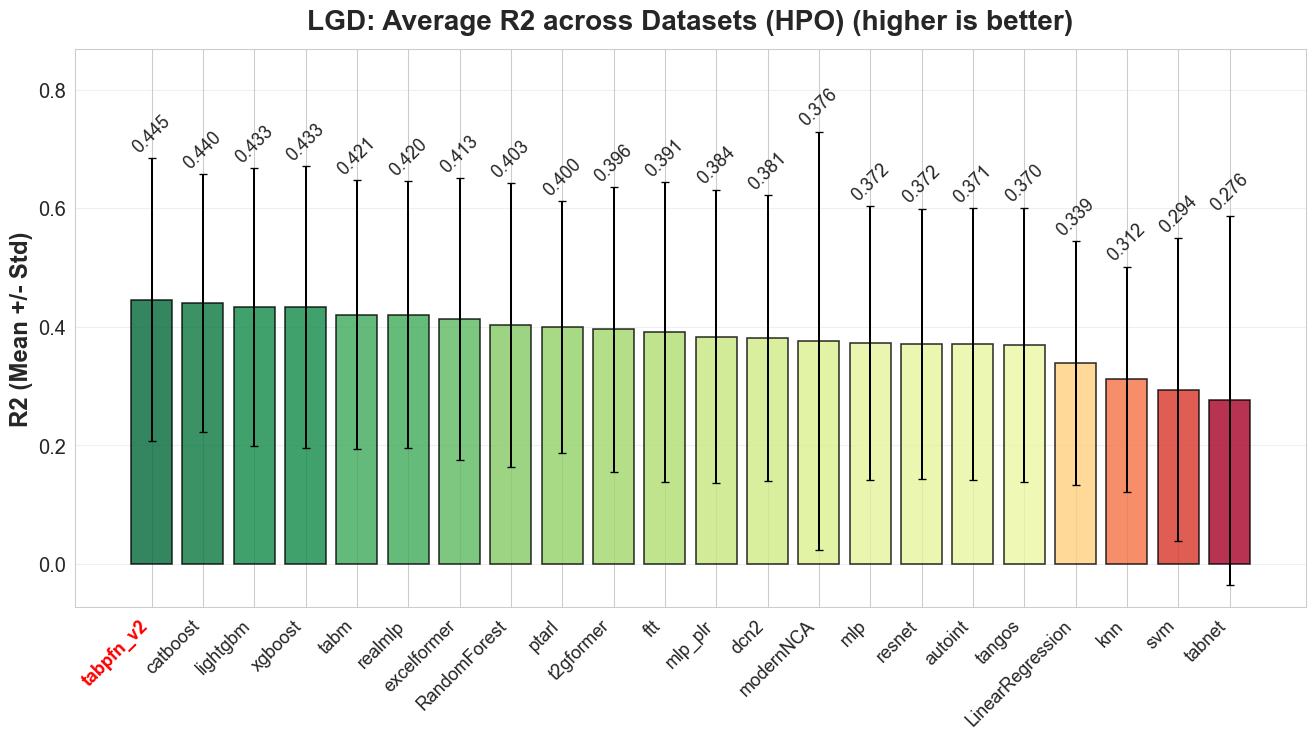

  Saved: lgd_mse_bar_hpo.png


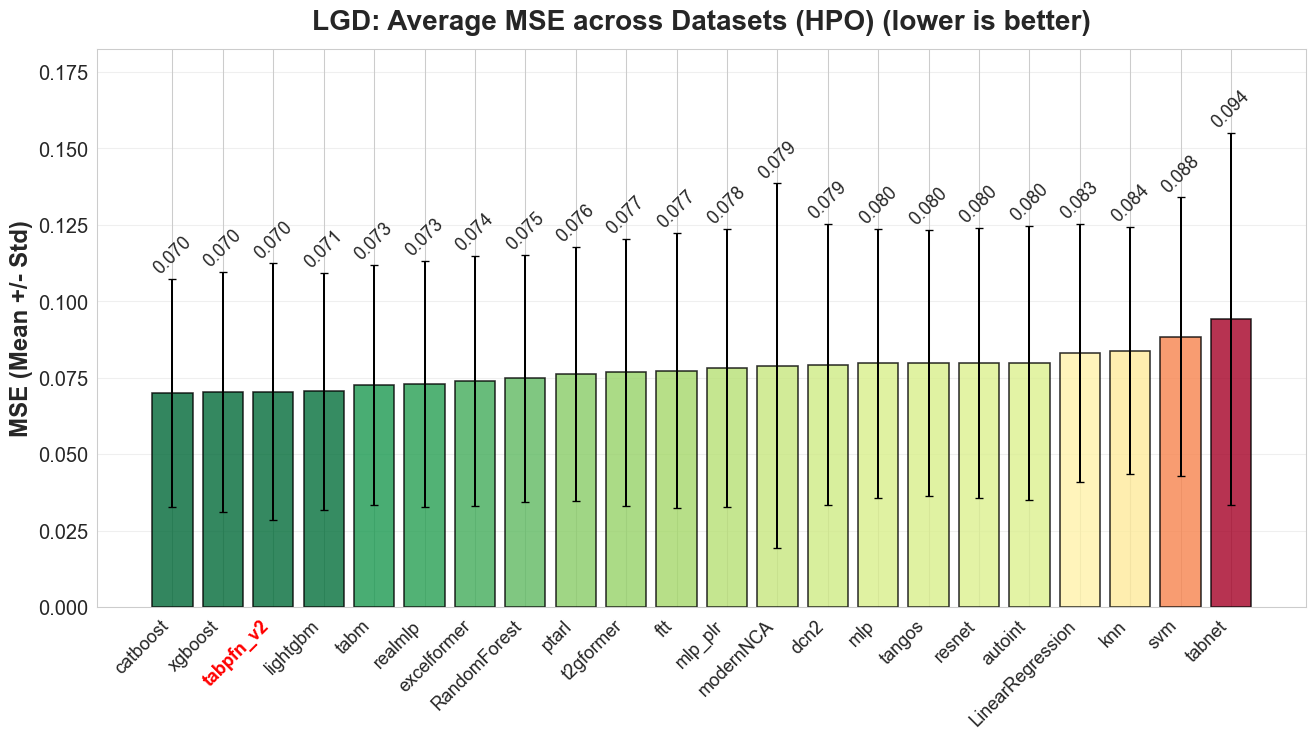

  Saved: lgd_rmse_bar_hpo.png


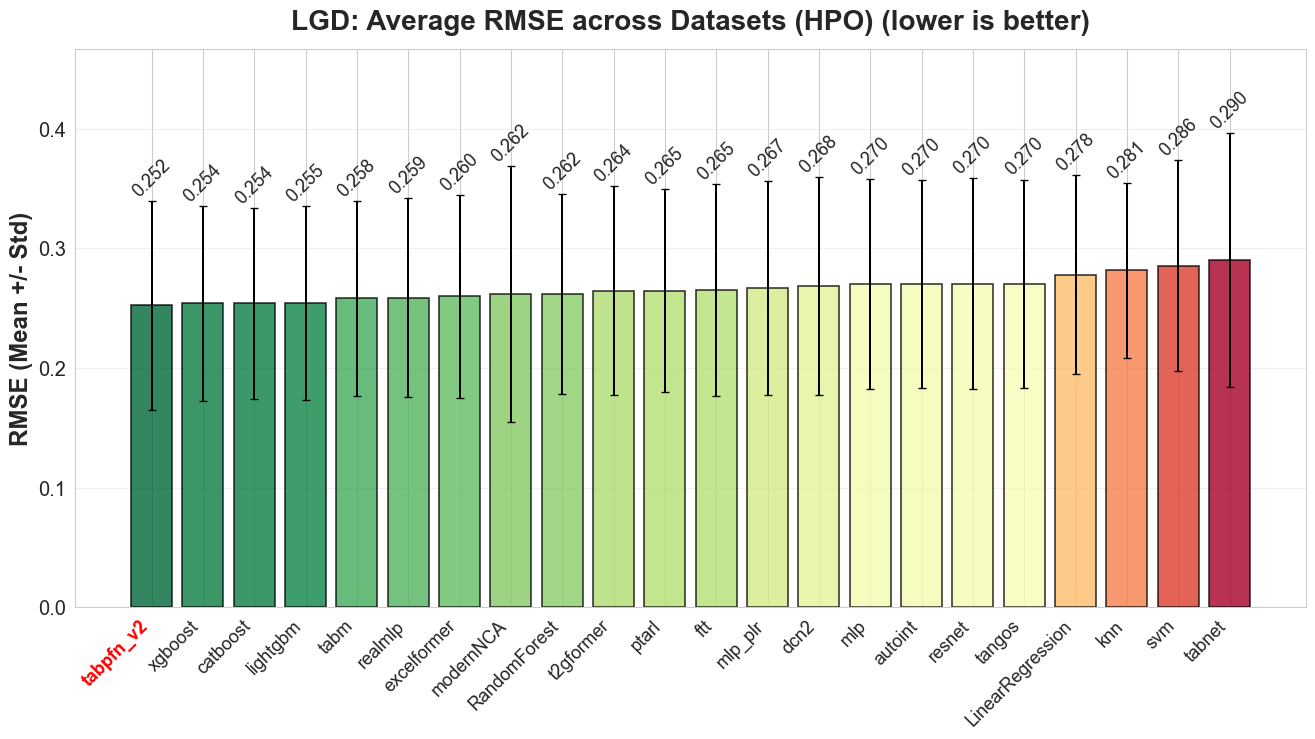

  Saved: lgd_mae_bar_hpo.png


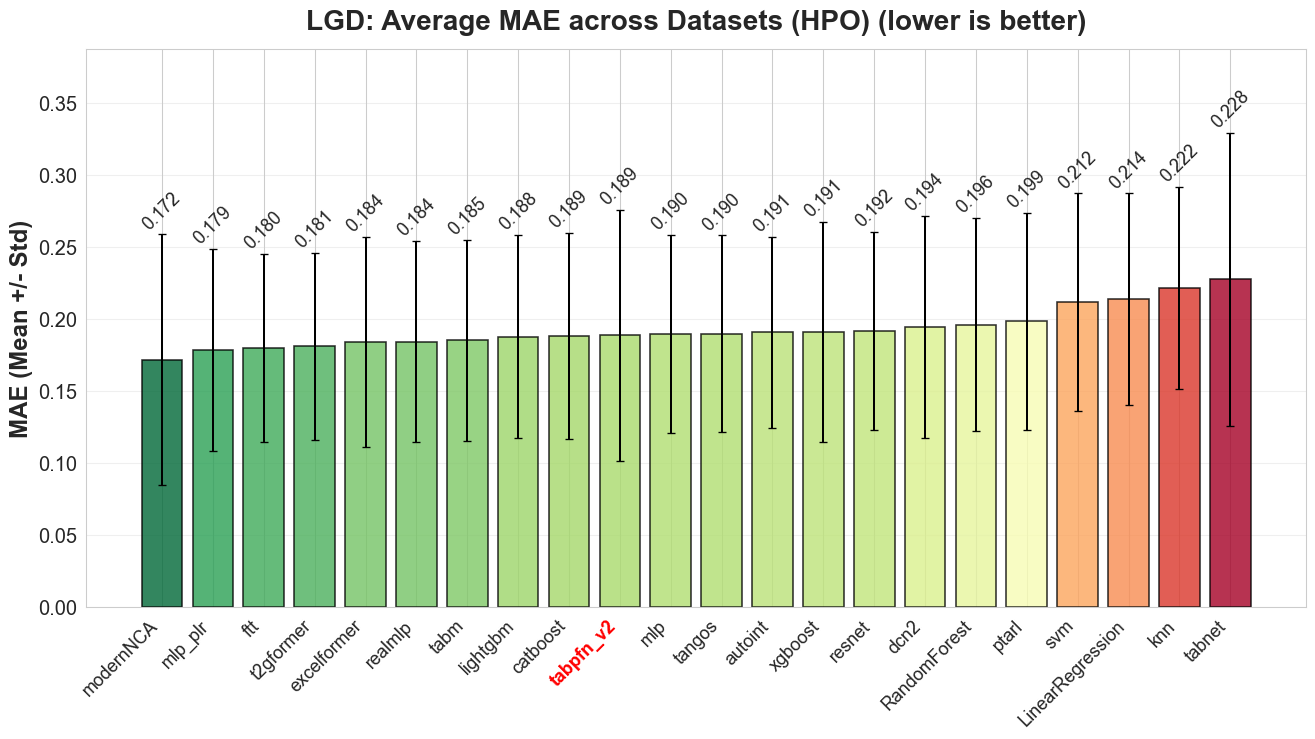

  Saved: lgd_medae_bar_hpo.png


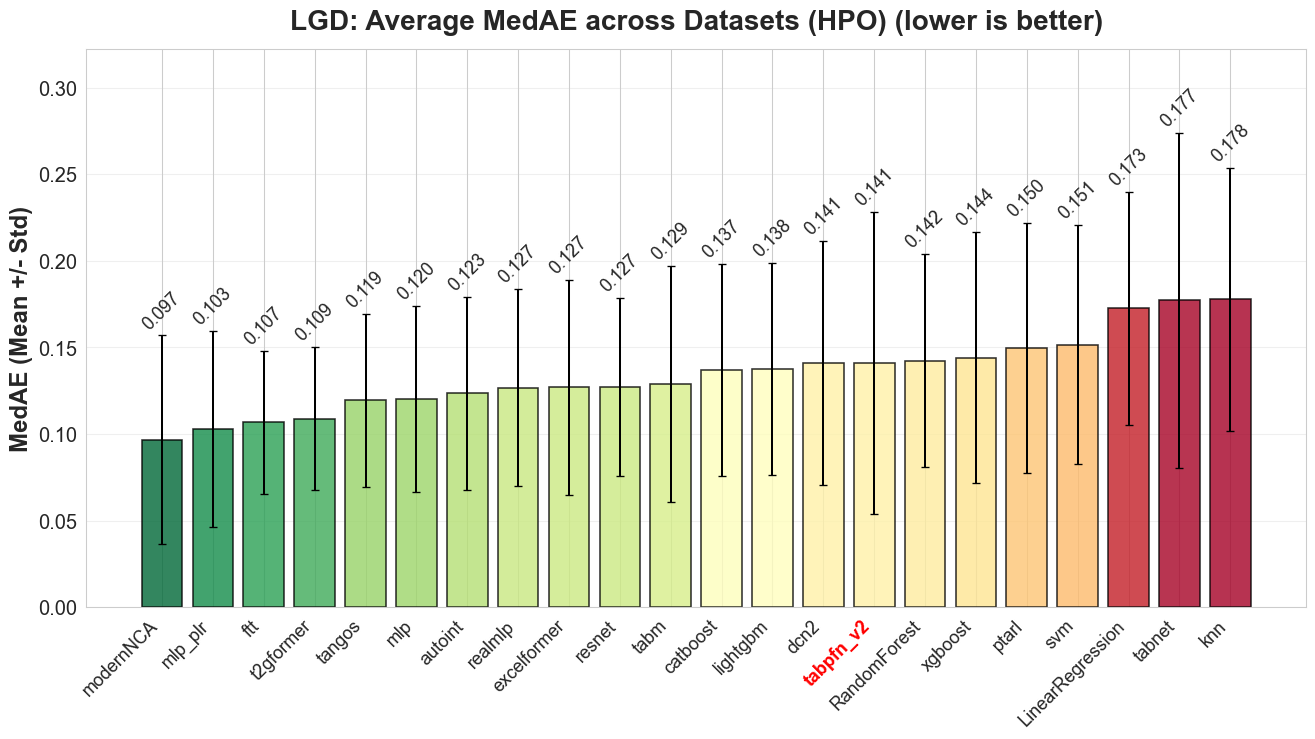

  Saved: lgd_maxerror_bar_hpo.png


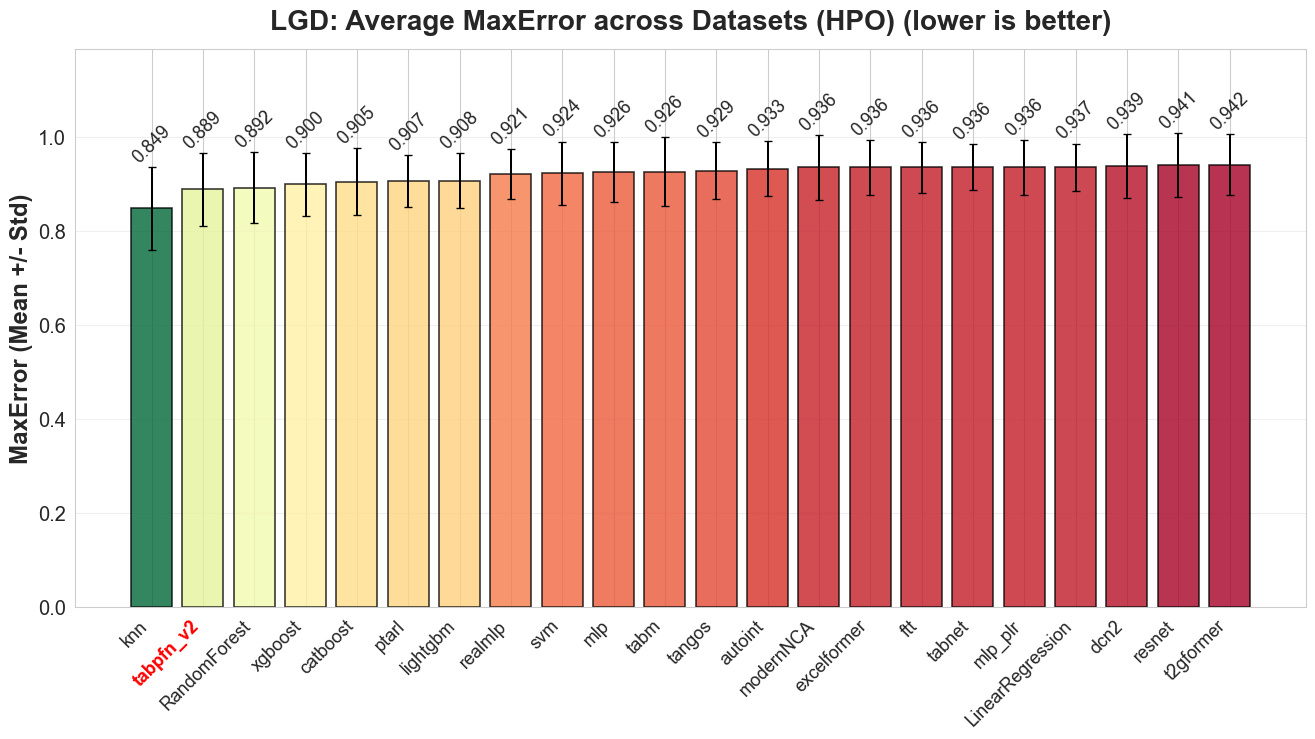

  Saved: lgd_explained_variance_bar_hpo.png


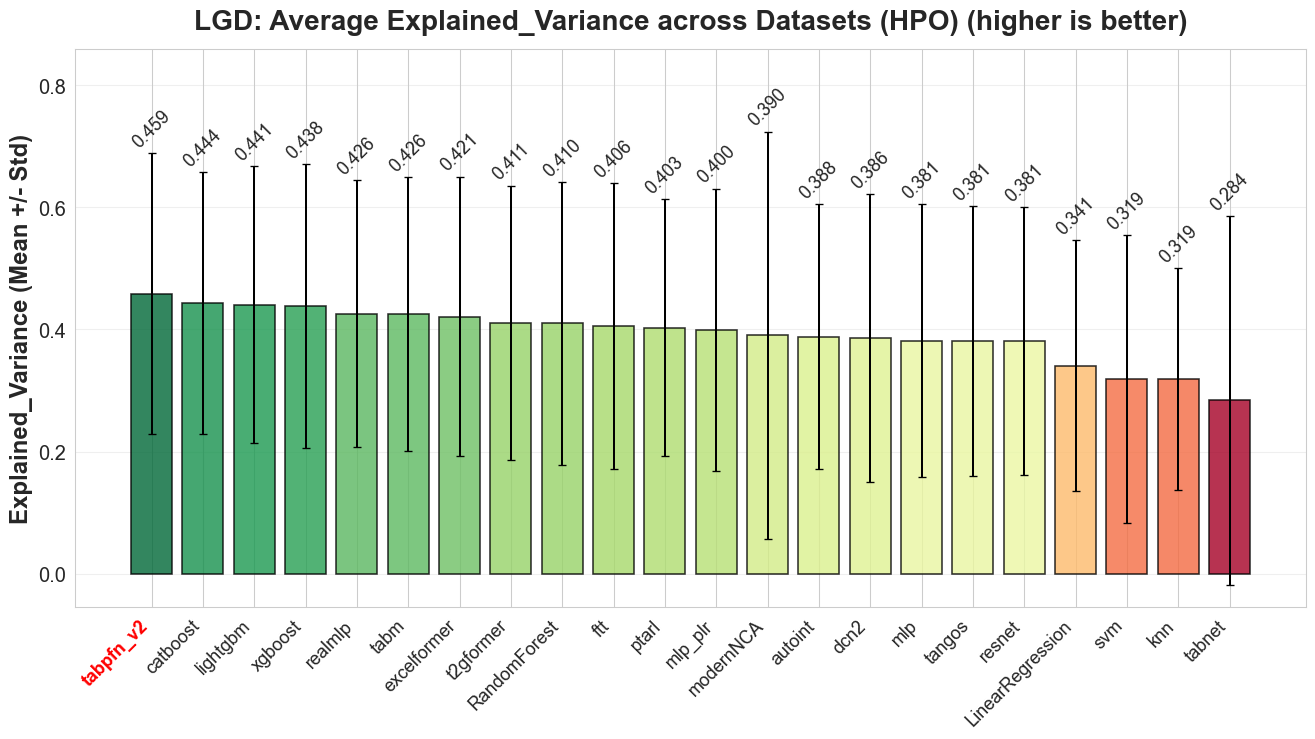

  Saved: lgd_mape_bar_hpo.png


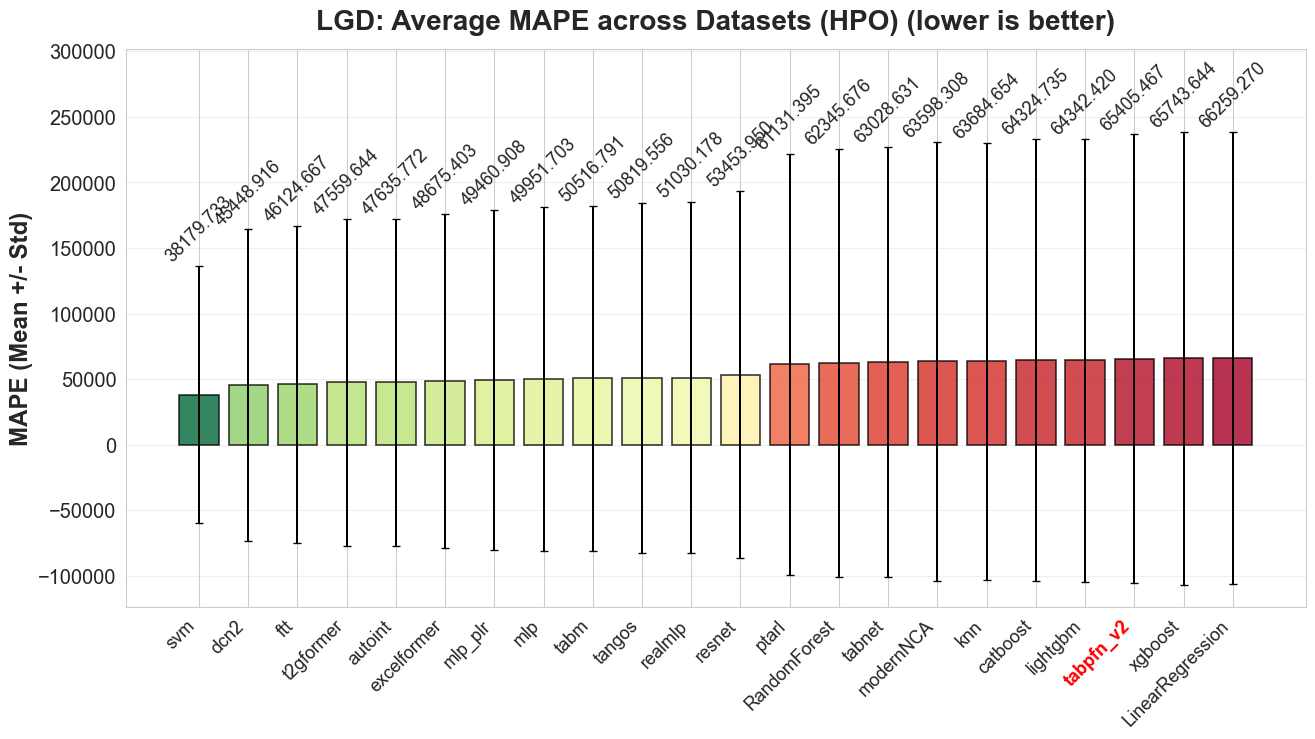

  Saved: lgd_pearson_corr_bar_hpo.png


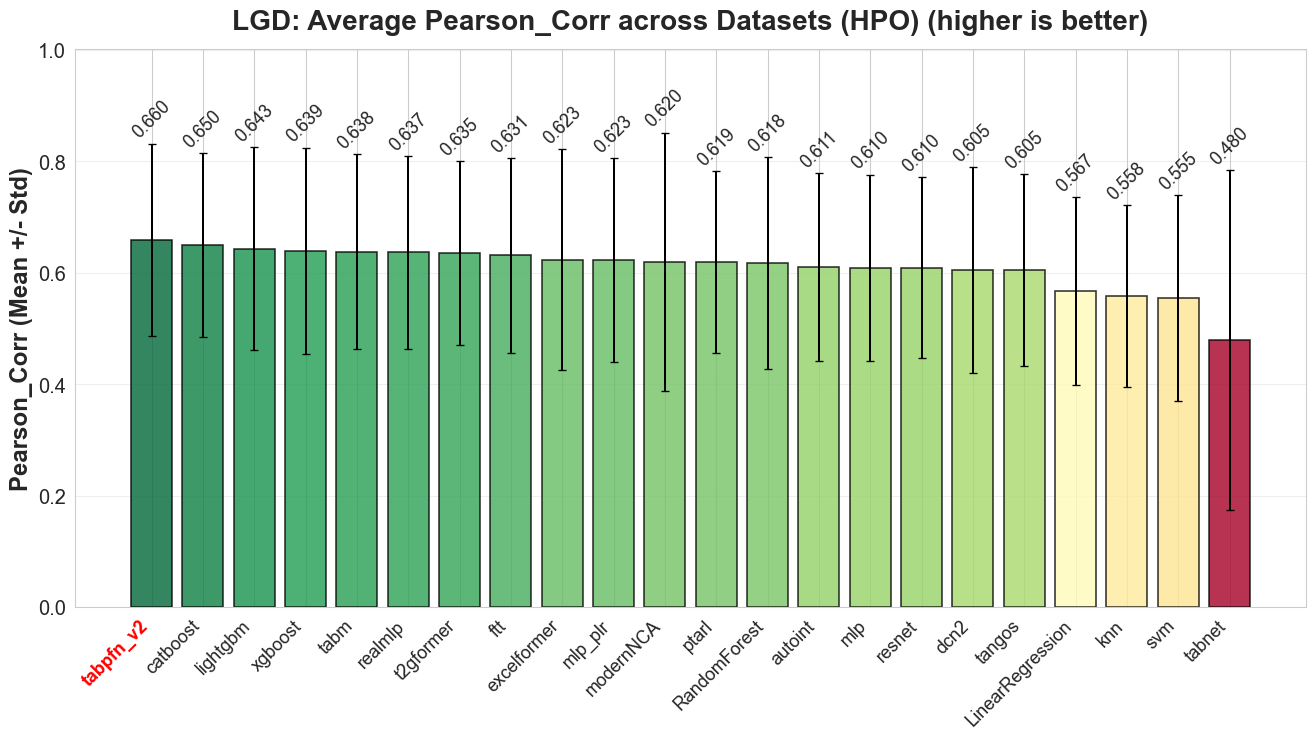

  Saved: lgd_spearman_corr_bar_hpo.png


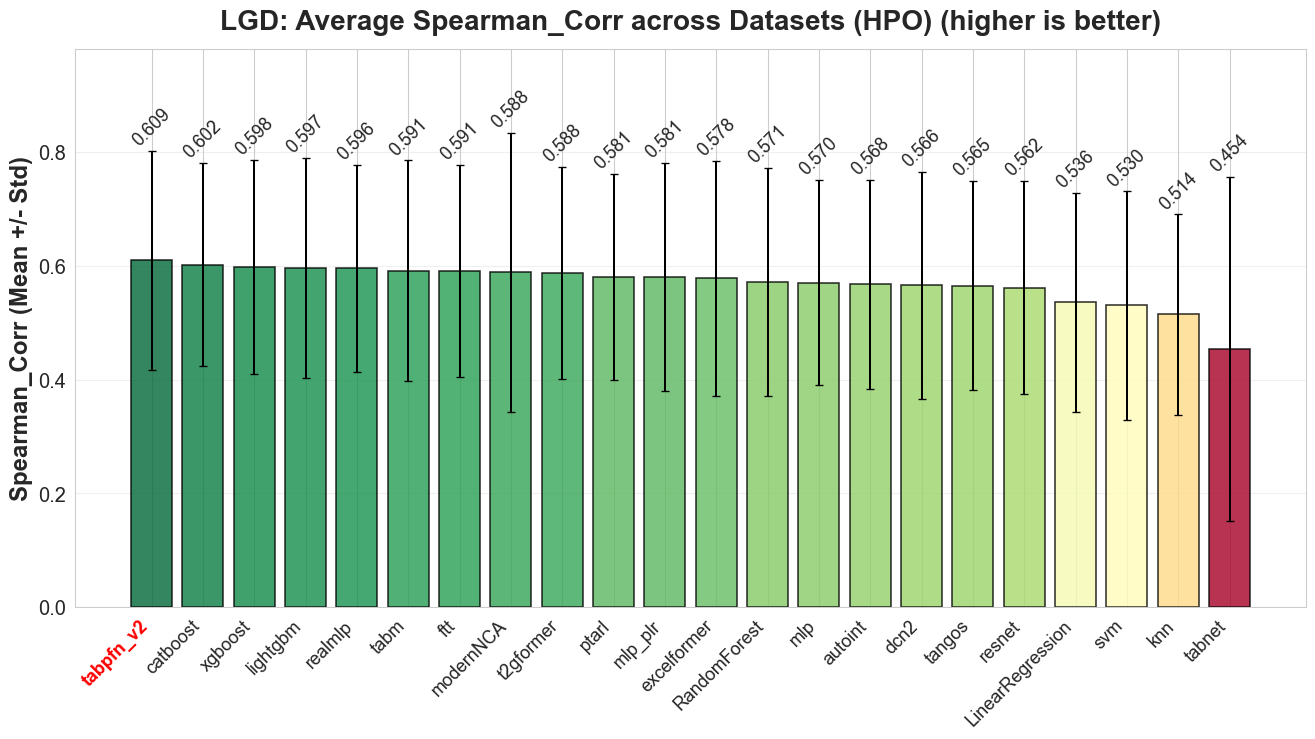

In [19]:
LGD_METRICS = ['R2', 'MSE', 'RMSE', 'MAE', 'MedAE', 'MaxError',
               'Explained_Variance', 'MAPE', 'Pearson_Corr', 'Spearman_Corr']
LGD_LOWER_BETTER = {'MSE', 'RMSE', 'MAE', 'MedAE', 'MaxError', 'MAPE'}

print("=" * 80)
print("  ALL LGD METRICS — BAR CHARTS (HPO)")
print("=" * 80)
plot_all_metrics_bars(lgd_raw, LGD_METRICS, LGD_LOWER_BETTER, 'LGD', 'HPO',
                      FOUNDATION_METHODS, FIGURES_DIR)

---
## Summary

This notebook contains all LGD (Loss Given Default) visualizations:
- Performance heatmaps (NO_HPO, HPO, HPO improvement)
- Performance distributions and rank analysis
- Dataset characteristics correlations
- Training time analysis
- Text summary of all metrics per dataset per method
- Bar chart visualizations for all LGD metrics (HPO)

Statistical testing (Friedman, Wilcoxon, CD diagrams, PAMA) is in **Experiment1.3-Stat.ipynb**.